# Estimating Incremental Advertising Impact with the Criteo Uplift Dataset

## ADSP 32029 Final Project Report
**Authors:** Prinu Mathew and Qingwei Zhang

**Date:** 05/10/2026

### Research Question
Which users are more likely to visit or convert because they were assigned to advertising treatment, rather than because they were already likely to respond?

### Report Design
- We begin with the experimental structure of the Criteo dataset and verify that randomized assignment produces credible treatment-control comparisons.
- We estimate the **average treatment effect (ATE) on `conversion`** as the primary final-outcome estimand, while also reporting ATE on `visit` and `exposure` for mechanism context.
- We compare `T-learner`, `X-learner`, and `R-learner` heterogeneity models from `causal_toolkit.meta_learners`, then add `double_ml_cate` and `dr_learner_discrete` as orthogonalized robustness checks, with **`conversion` as the primary CATE/uplift target** and `visit` as a supporting intermediate-outcome sensitivity check.
- We add a mediation-style pathway analysis to assess whether assignment effects appear to flow through `exposure` and `visit` before `conversion`.

### Deliverables in This Notebook
This notebook is written as a report rather than a scratchpad: each section introduces the business question, presents a compact computation, and concludes with export-ready figures that can be reused in the final submission.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from causal_toolkit import (
    __version__ as causal_toolkit_version,
    calculate_ate_ci,
    calculate_ate_pvalue,
    double_ml_cate,
    dr_learner_discrete,
    r_learner_discrete,
    t_learner_discrete,
    x_learner_discrete,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

figure_dir = Path("./figures/final_report")
figure_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename):
    fig.savefig(figure_dir / filename, bbox_inches="tight", facecolor="white")

print(f"Imports loaded successfully. causal_toolkit v{causal_toolkit_version}")

Imports loaded successfully. causal_toolkit v0.1.0


## 1. Experimental Setting and Data Overview

The Criteo Uplift Prediction Dataset comes from randomized advertising experiments, which makes it much better suited to causal analysis than a standard observational ad log. Assignment to treatment is randomized, while `exposure` records realized delivery after assignment.

This distinction matters for the report:
- `treatment` is the causal intervention used for the main estimands.
- `exposure` is a post-treatment variable that helps describe compliance but should not replace assignment in the core effect estimates.
- `visit` and `conversion` are the outcomes of business interest, with `conversion` being rarer and therefore noisier.

### 1.1 Data Overview

In [2]:
data_path = Path("./data/criteo-uplift-v2.1.csv")
criteo_uplift_df = pd.read_csv(data_path)

feature_cols = [f"f{i}" for i in range(12)]
treatment_col = "treatment"
outcome_cols = ["visit", "conversion"]
post_treatment_col = "exposure"

final_outcome = "conversion"
intermediate_outcome = "visit"
heterogeneity_primary_outcome = final_outcome
heterogeneity_secondary_outcome = intermediate_outcome

heterogeneity_sample_size = 300_000
heterogeneity_test_size = 0.40
mediation_sample_size = 250_000

print(f"Loaded {data_path.name}")
print(f"Rows: {len(criteo_uplift_df):,}")
print(f"Columns: {len(criteo_uplift_df.columns)}")
print(f"Primary CATE/uplift outcome: {heterogeneity_primary_outcome}")
print(f"Sensitivity CATE outcome: {heterogeneity_secondary_outcome}")
print(f"Heterogeneity modeling sample: {heterogeneity_sample_size:,} rows")
print(f"Mediation diagnostic sample: {mediation_sample_size:,} rows")
criteo_uplift_df.head()

Loaded criteo-uplift-v2.1.csv
Rows: 13,979,592
Columns: 16
Primary CATE/uplift outcome: conversion
Sensitivity CATE outcome: visit
Heterogeneity modeling sample: 300,000 rows
Mediation diagnostic sample: 250,000 rows


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.6164,10.0597,8.9764,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
1,12.6164,10.0597,9.0027,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
2,12.6164,10.0597,8.9648,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
3,12.6164,10.0597,9.0028,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0
4,12.6164,10.0597,9.0380,4.6799,10.2805,4.1155,0.2944,4.8338,3.9554,13.1901,5.3004,-0.1687,1,0,0,0


In [3]:
overview = pd.DataFrame(
    {
        "dtype": criteo_uplift_df.dtypes.astype(str),
        "missing": criteo_uplift_df.isna().sum(),
    }
)
numeric_means = criteo_uplift_df.mean(numeric_only=True)
overview["mean"] = overview.index.map(numeric_means)

print(f"Missing values across the dataset: {int(overview['missing'].sum()):,}")
display(overview.loc[feature_cols + [treatment_col, post_treatment_col] + outcome_cols])

Missing values across the dataset: 0


,dtype,missing,mean
f0,float64,0,19.6203
f1,float64,0,10.0700
f2,float64,0,8.4466
f3,float64,0,4.1789
f4,float64,0,10.3388
f5,float64,0,4.0285
f6,float64,0,-4.1554
f7,float64,0,5.1018
f8,float64,0,3.9336
f9,float64,0,16.0276


### 1.2 Variable Descriptions

In [4]:
# Key variable distributions
print("=== Treatment/Exposure/Outcome ===\n")
for col in ['treatment', 'exposure', 'conversion', 'visit']:
    counts = criteo_uplift_df[col].value_counts().sort_index()
    pcts = criteo_uplift_df[col].value_counts(normalize=True).sort_index() * 100
    print(f"{col}:")
    print(f"  0: {counts[0]:,} ({pcts[0]:.2f}%)")
    print(f"  1: {counts[1]:,} ({pcts[1]:.2f}%)\n")

=== Treatment/Exposure/Outcome ===

treatment:
  0: 2,096,937 (15.00%)
  1: 11,882,655 (85.00%)

exposure:
  0: 13,551,380 (96.94%)
  1: 428,212 (3.06%)

conversion:
  0: 13,938,818 (99.71%)
  1: 40,774 (0.29%)

visit:
  0: 13,322,663 (95.30%)
  1: 656,929 (4.70%)



,count,rate,rate_pct
assigned treatment,11882655,0.8500,85.0000
realized exposure,428212,0.0306,3.0631
visit,656929,0.0470,4.6992
conversion,40774,0.0029,0.2917


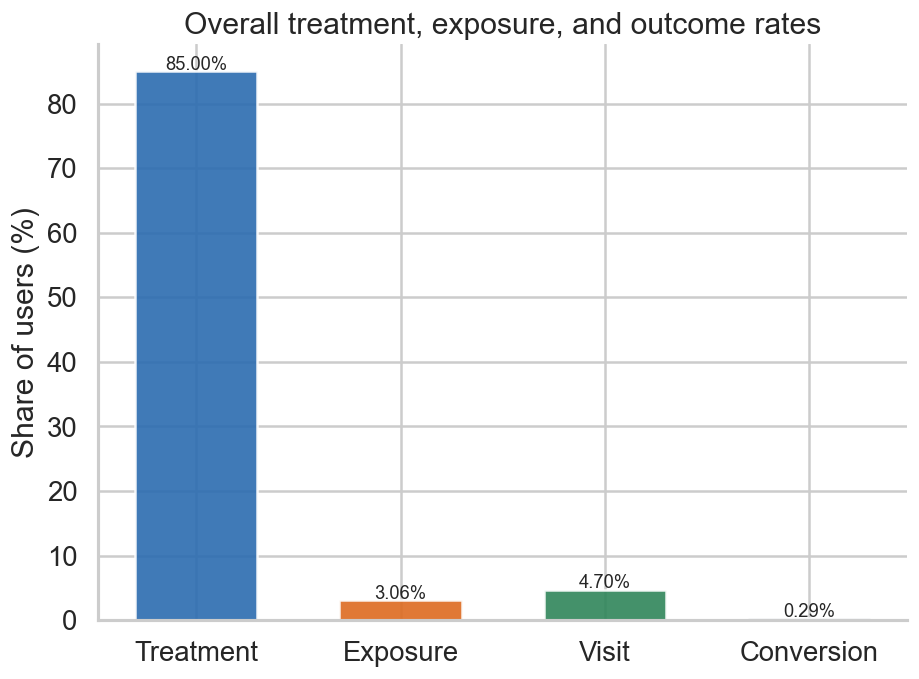

Saved figure to figures\final_report\figure_1_overall_rates.png


In [5]:
summary_table = pd.DataFrame(
    {
        "count": criteo_uplift_df[[treatment_col, post_treatment_col, "visit", "conversion"]].sum(),
        "rate": criteo_uplift_df[[treatment_col, post_treatment_col, "visit", "conversion"]].mean(),
    }
)
summary_table["rate_pct"] = 100 * summary_table["rate"]
display(summary_table.rename(index={"treatment": "assigned treatment", "exposure": "realized exposure"}))

fig, ax = plt.subplots(figsize=(8, 6))
variables = ["Treatment", "Exposure", "Visit", "Conversion"]
rates = [
    100 * criteo_uplift_df[treatment_col].mean(),
    100 * criteo_uplift_df[post_treatment_col].mean(),
    100 * criteo_uplift_df["visit"].mean(),
    100 * criteo_uplift_df["conversion"].mean(),
]
bars = ax.bar(
    variables,
    rates,
    color=["#2b6cb0", "#dd6b20", "#2f855a", "#4a5568"],
    alpha=0.9,
    width=0.6,
)
ax.set_ylabel("Share of users (%)")
ax.set_title("Overall treatment, exposure, and outcome rates")

for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.3, f"{rate:.2f}%", ha="center", fontsize=11)

save_figure(fig, "figure_1_overall_rates.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_1_overall_rates.png'}")

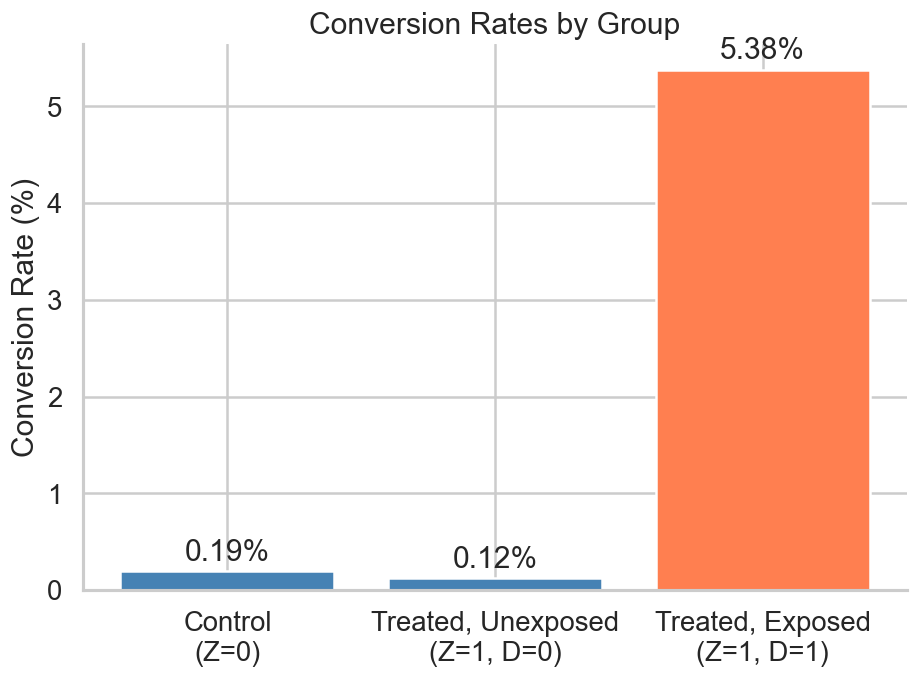

Saved figure to figures\final_report\figure_2_conversion_rates_by_group.png


In [6]:
# Outcome rates by group
control = criteo_uplift_df[criteo_uplift_df['treatment'] == 0]
treated_unexposed = criteo_uplift_df[(criteo_uplift_df['treatment'] == 1) & (criteo_uplift_df['exposure'] == 0)]
treated_exposed = criteo_uplift_df[(criteo_uplift_df['treatment'] == 1) & (criteo_uplift_df['exposure'] == 1)]

groups = ['Control\n(Z=0)', 'Treated, Unexposed\n(Z=1, D=0)', 'Treated, Exposed\n(Z=1, D=1)']
conversion_rates = [
    control['conversion'].mean() * 100,
    treated_unexposed['conversion'].mean() * 100,
    treated_exposed['conversion'].mean() * 100
]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(groups, conversion_rates, color=['steelblue', 'steelblue', 'coral'])
ax.set_ylabel('Conversion Rate (%)')
ax.set_title('Conversion Rates by Group')

# Add value labels
for bar, rate in zip(bars, conversion_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
            f'{rate:.2f}%', ha='center', va='bottom')

save_figure(fig, "figure_2_conversion_rates_by_group.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_2_conversion_rates_by_group.png'}")

*Figure 1.* Overall rates are highly imbalanced: treatment assignment is high (85.0%), realized exposure is low (3.06%), `visit` is 4.70%, and `conversion` is 0.29% (about 1 in 345 users). The large assignment-to-exposure drop indicates limited post-assignment reach/compliance, so assignment effects can look diluted relative to exposure-conditioned contrasts. Because these are population-level shares (not a strict funnel), the report keeps ITT/ATE on `conversion` as the primary estimand while using `exposure` and `visit` as pathway diagnostics.

### 1.3 Visualization of Pre-Treatment Imbalance

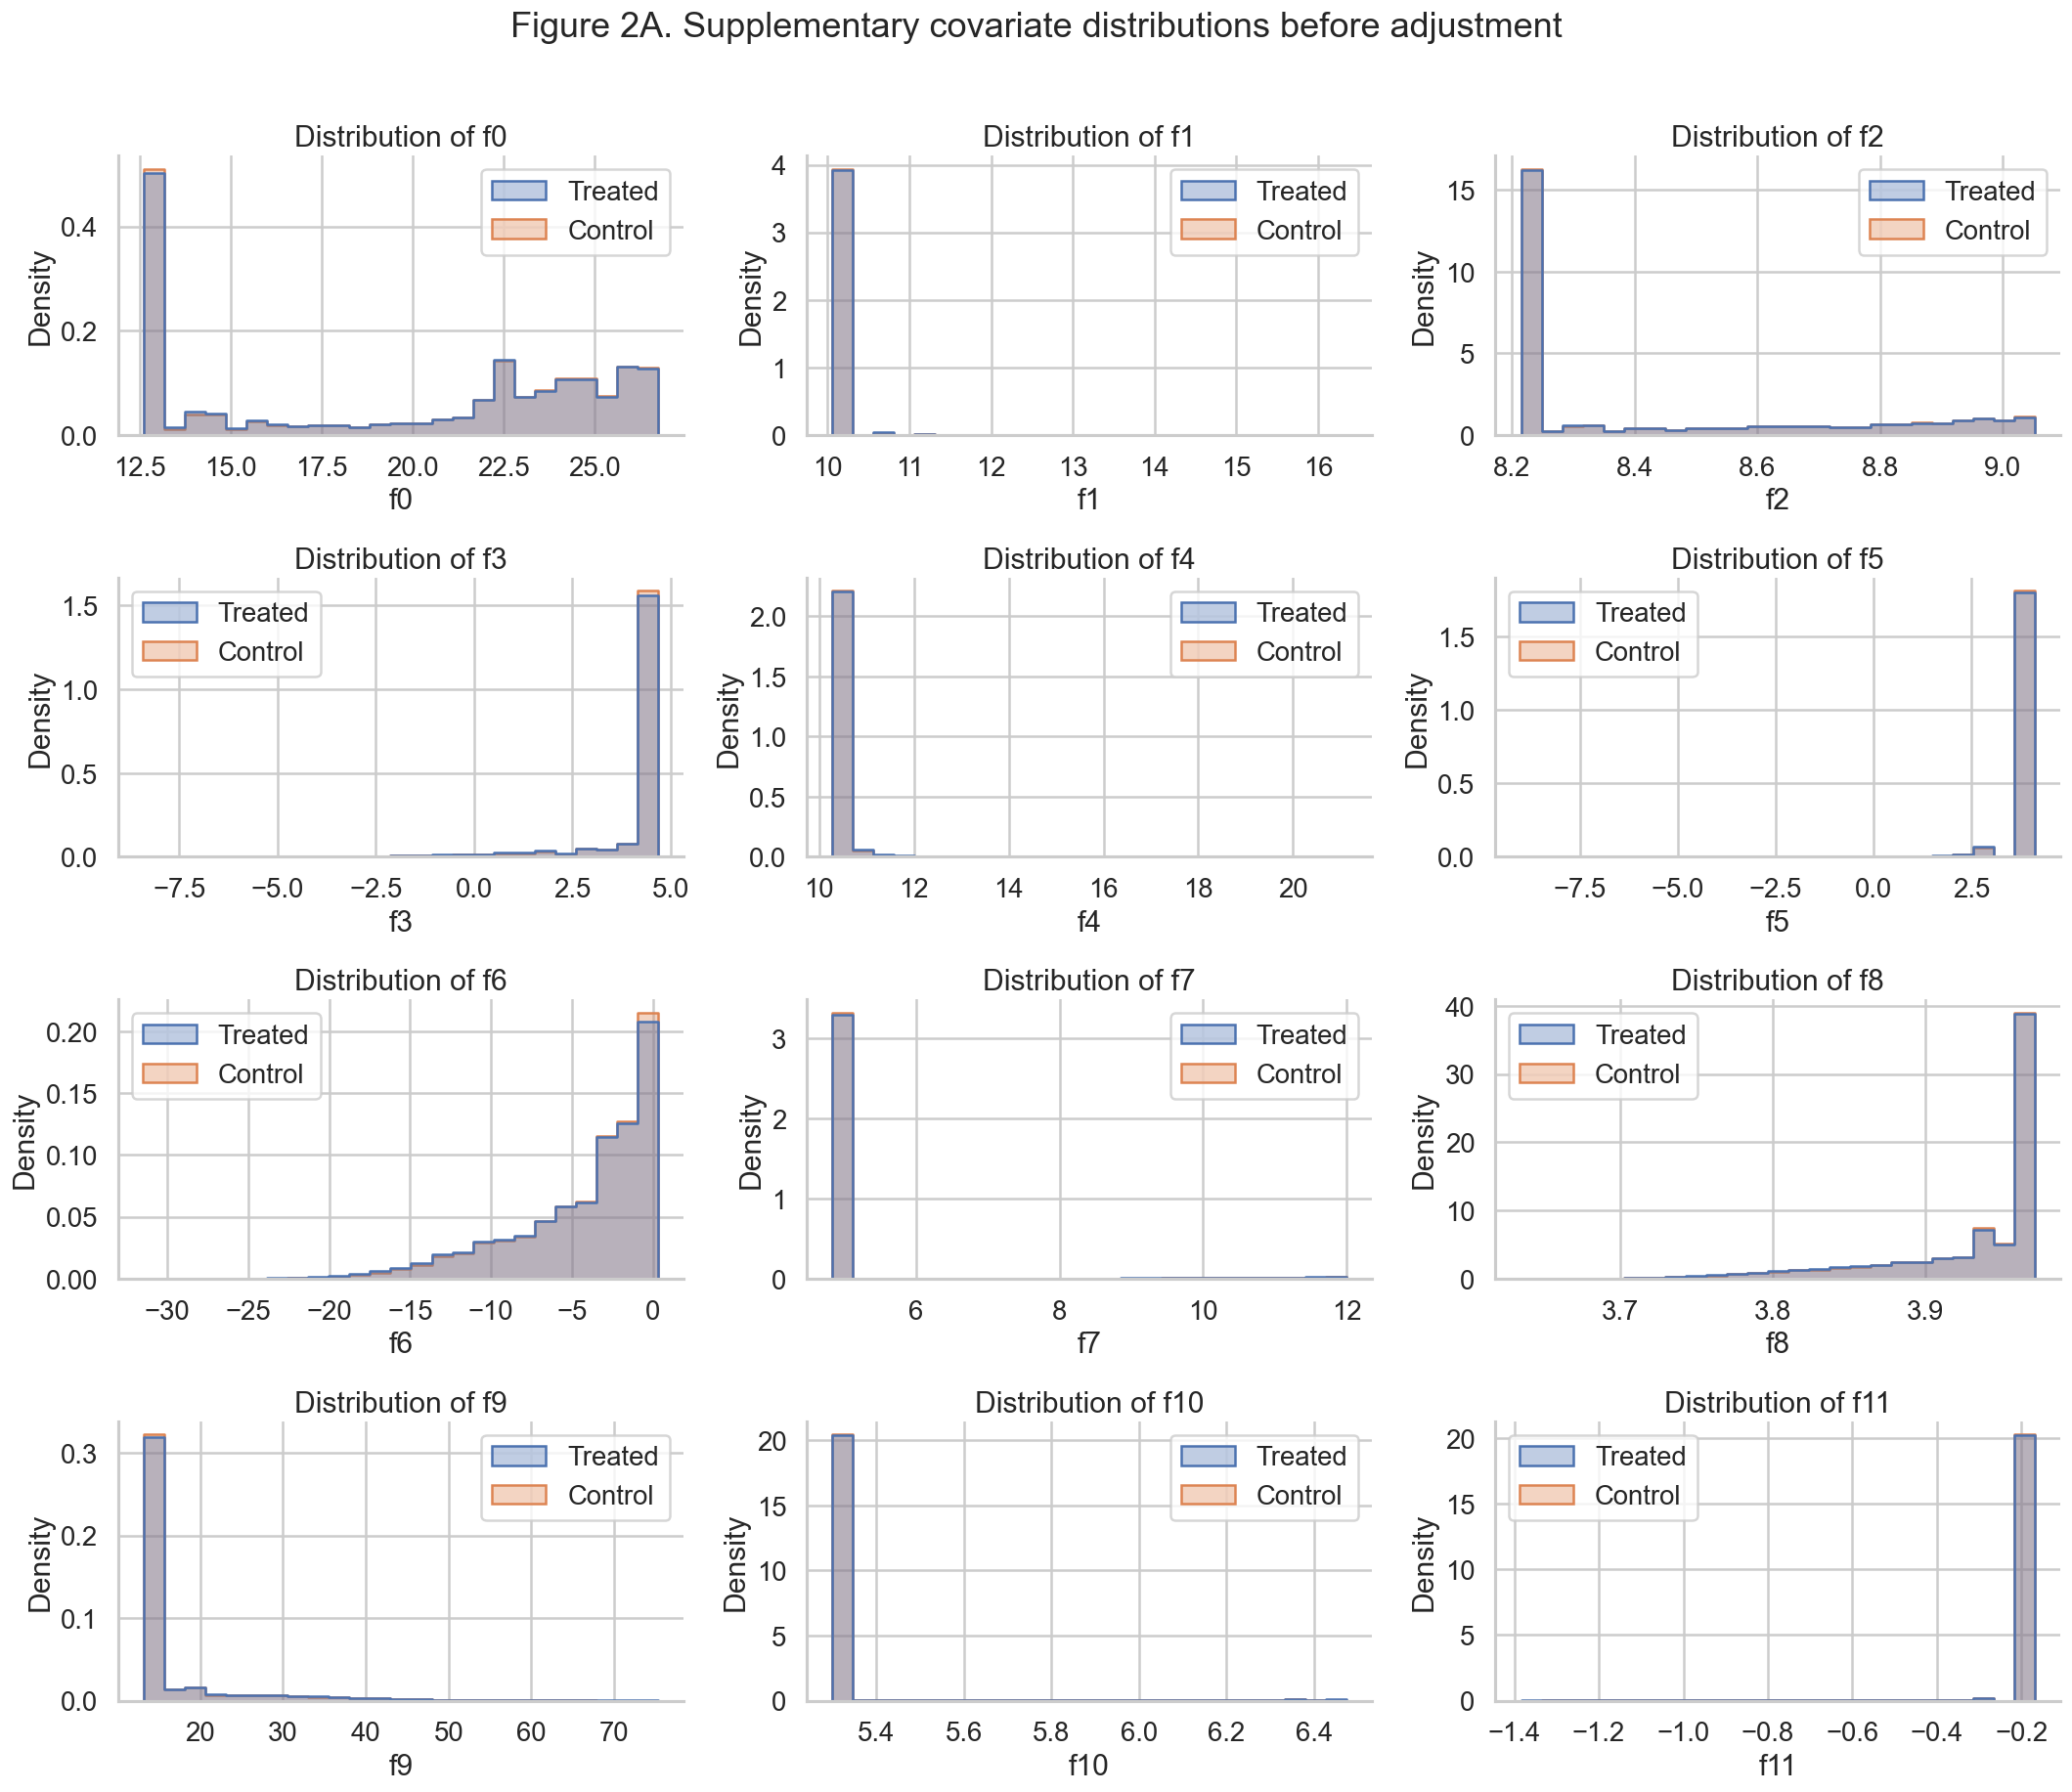

Saved figure to figures\final_report\figure_2a_covariate_imbalance_before.png


In [7]:
# Supplementary distributional balance check before any adjustment.
n_features = len(feature_cols)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.8 * n_rows))
axes = np.array(axes).reshape(-1)

plot_df = criteo_uplift_df[[*feature_cols, treatment_col]].copy()
plot_df["assignment_group"] = plot_df[treatment_col].map({0: "Control", 1: "Treated"})

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    sns.histplot(
        data=plot_df,
        x=feature,
        hue="assignment_group",
        stat="density",
        common_norm=False,
        bins=25,
        element="step",
        fill=True,
        alpha=0.35,
        ax=ax,
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    if ax.legend_ is not None:
        ax.legend_.set_title(None)

for idx in range(len(feature_cols), len(axes)):
    axes[idx].axis("off")

fig.suptitle("Figure 2A. Supplementary covariate distributions before adjustment", y=1.01)
save_figure(fig, "figure_2a_covariate_imbalance_before.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_2a_covariate_imbalance_before.png'}")

**How to read Figure 2A (attached plot):**

- This is a **pre-adjustment** covariate check: treated vs control densities are overlaid for each feature (`f0` to `f11`) before any matching/reweighting.
- Across panels, the two groups show very similar overall shape and location (including the same boundary spikes and skewed tails).
- A few features show small local tail differences, but there is no consistent global shift between treatment and control.
- Interpretation: the visual pattern is consistent with successful randomization and supports using standardized differences (Figure 2B) as the primary formal balance diagnostic.

### 1.4 Randomization Verification

Largest standardized differences between treatment groups:


,control_mean,treated_mean,std_diff,abs_std_diff
f3,4.2328,4.1694,-0.0474,0.0474
f6,-3.9999,-4.1828,-0.0400,0.0400
f5,4.0393,4.0266,-0.0295,0.0295
f9,15.8863,16.0526,0.0237,0.0237
f1,10.0679,10.0703,0.0229,0.0229
f8,3.9347,3.9334,-0.0222,0.0222
f7,5.0803,5.1056,0.0210,0.0210
f10,5.3319,5.3337,0.0105,0.0105
f4,10.3365,10.3392,0.0079,0.0079
f0,19.6517,19.6148,-0.0069,0.0069


Exposure rates by assigned treatment:


exposure,Not Exposed,Exposed
treatment,,
Control,1.0000,0.0000
Treated,0.9640,0.0360


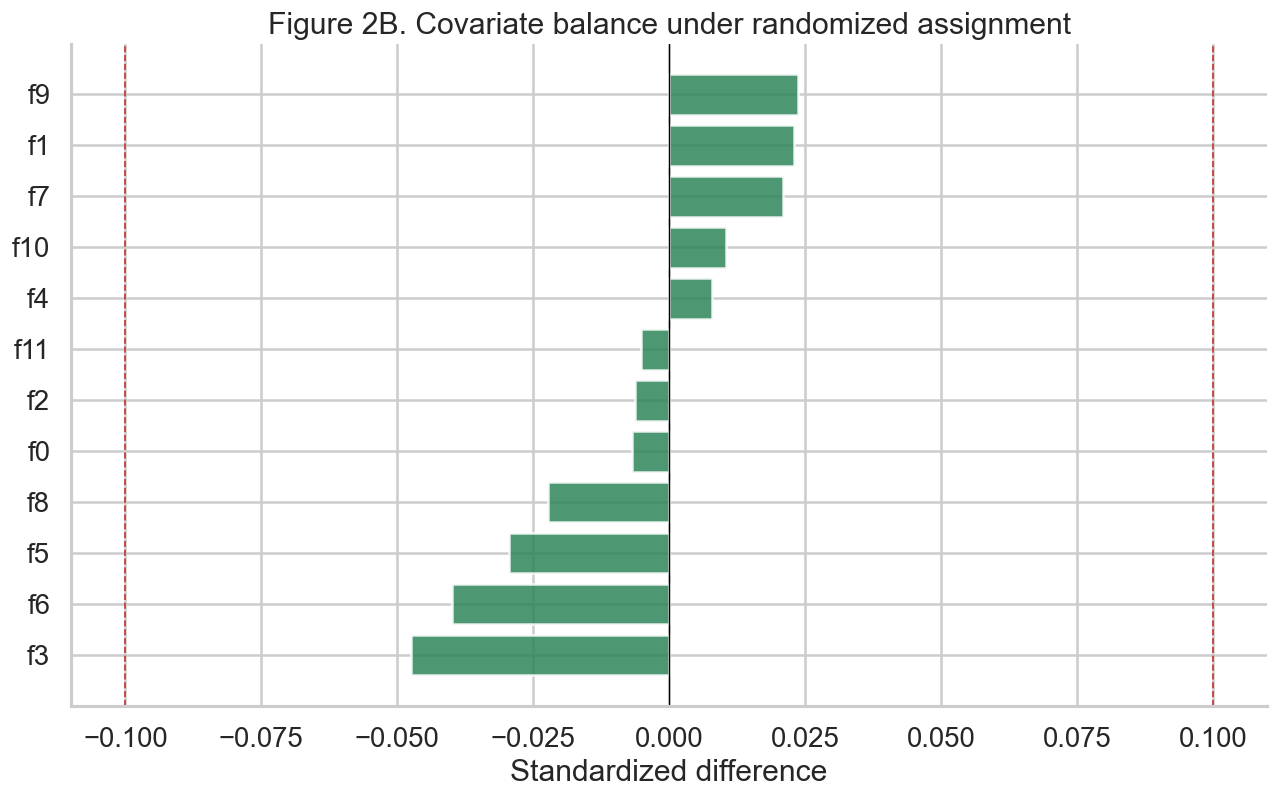

Saved figure to figures\final_report\figure_2b_covariate_balance.png


In [8]:
balance = pd.DataFrame(
    {
        "control_mean": criteo_uplift_df.loc[criteo_uplift_df[treatment_col] == 0, feature_cols].mean(),
        "treated_mean": criteo_uplift_df.loc[criteo_uplift_df[treatment_col] == 1, feature_cols].mean(),
    }
)
balance["std_diff"] = (balance["treated_mean"] - balance["control_mean"]) / criteo_uplift_df[feature_cols].std()
balance["abs_std_diff"] = balance["std_diff"].abs()
balance_summary = balance.sort_values("abs_std_diff", ascending=False)

compliance = pd.crosstab(
    criteo_uplift_df[treatment_col],
    criteo_uplift_df[post_treatment_col],
    normalize="index",
).rename(index={0: "Control", 1: "Treated"}, columns={0: "Not Exposed", 1: "Exposed"})

print("Largest standardized differences between treatment groups:")
display(balance_summary.head(12))
print("Exposure rates by assigned treatment:")
display(compliance)

ordered_balance = balance.sort_values("std_diff")
colors = ["#2f855a" if value < 0.1 else "#c53030" for value in ordered_balance["abs_std_diff"]]

fig_balance, ax_balance = plt.subplots(figsize=(11, 7))
ax_balance.barh(ordered_balance.index, ordered_balance["std_diff"], color=colors, alpha=0.85)
ax_balance.axvline(0.1, color="#c53030", linestyle="--", linewidth=1)
ax_balance.axvline(-0.1, color="#c53030", linestyle="--", linewidth=1)
ax_balance.axvline(0, color="black", linewidth=0.8)
ax_balance.set_xlabel("Standardized difference")
ax_balance.set_title("Figure 2B. Covariate balance under randomized assignment")

save_figure(fig_balance, "figure_2b_covariate_balance.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_2b_covariate_balance.png'}")

**How to read Figure 2B (attached plot):**

- Each bar is a standardized mean difference: `(treated_mean - control_mean) / sd(feature)`.
- The vertical dashed lines at `-0.10` and `+0.10` are common practical balance cutoffs; bars closer to zero indicate better randomization balance.
- All features lie well inside those bounds (largest absolute value is about `0.047`), so none suggests meaningful pre-treatment imbalance.
- Positive bars mean a slightly higher treated-group mean; negative bars mean a slightly lower treated-group mean. Here, signs are mixed and magnitudes are small, which is exactly what we expect under successful random assignment.

### 1.5 Compliance Analysis

In [9]:
# Compliance analysis: Treatment (Z) vs Exposure (D)
print("=== Compliance Structure ===\n")
ct = pd.crosstab(criteo_uplift_df['treatment'], criteo_uplift_df['exposure'], margins=True)
ct.index = ['Z=0 (Control)', 'Z=1 (Treated)', 'Total']
ct.columns = ['D=0 (No Ad)', 'D=1 (Saw Ad)', 'Total']
print(ct)

print("\n=== Proportions ===")
ct_pct = pd.crosstab(criteo_uplift_df['treatment'], criteo_uplift_df['exposure'], normalize='index') * 100
ct_pct.index = ['Z=0 (Control)', 'Z=1 (Treated)']
ct_pct.columns = ['D=0 (No Ad)', 'D=1 (Saw Ad)']
print(ct_pct.round(2))

=== Compliance Structure ===

               D=0 (No Ad)  D=1 (Saw Ad)     Total
Z=0 (Control)      2096937             0   2096937
Z=1 (Treated)     11454443        428212  11882655
Total             13551380        428212  13979592

=== Proportions ===
               D=0 (No Ad)  D=1 (Saw Ad)
Z=0 (Control)     100.0000        0.0000
Z=1 (Treated)      96.4000        3.6000


In [10]:
# Compliance types
n_total = len(criteo_uplift_df)
n_treated = (criteo_uplift_df['treatment'] == 1).sum()
n_control = (criteo_uplift_df['treatment'] == 0).sum()

# In control: all D=0 (no always-takers)
always_takers = 0

# In treatment: D=1 are compliers
compliers_in_treated = (criteo_uplift_df['treatment'] == 1) & (criteo_uplift_df['exposure'] == 1)
complier_rate = compliers_in_treated.sum() / n_treated

# Never-takers: everyone else
never_taker_rate = 1 - complier_rate

print("=== Compliance Types ===")
print(f"Compliers: {complier_rate*100:.2f}% (see ad only when assigned)")
print(f"Never-takers: {never_taker_rate*100:.2f}% (never see ad)")
print(f"Always-takers: 0% (none in control saw ads)")
print(f"Defiers: 0% (assumed via monotonicity)")

=== Compliance Types ===
Compliers: 3.60% (see ad only when assigned)
Never-takers: 96.40% (never see ad)
Always-takers: 0% (none in control saw ads)
Defiers: 0% (assumed via monotonicity)


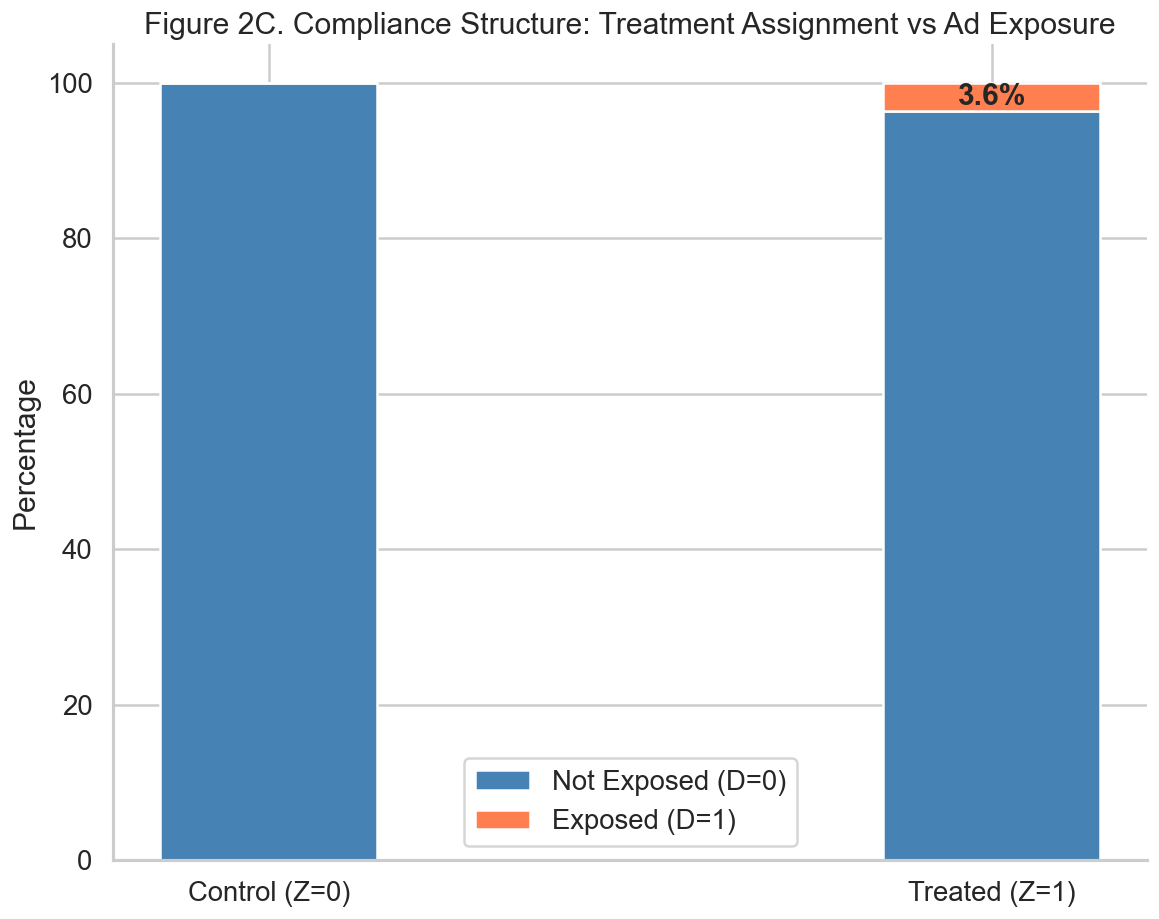

Saved figure to figures\final_report\figure_2c_exposure_compliance.png


In [11]:
# Compliance structure
fig, ax = plt.subplots(figsize=(10, 8))

groups = ['Control (Z=0)', 'Treated (Z=1)']
not_exposed = [100, 96.4]
exposed = [0, 3.6]

x = np.arange(len(groups))
width = 0.3

bars1 = ax.bar(x, not_exposed, width, label='Not Exposed (D=0)', color='steelblue')
bars2 = ax.bar(x, exposed, width, bottom=not_exposed, label='Exposed (D=1)', color='coral')

ax.set_ylabel('Percentage')
ax.set_title('Figure 2C. Compliance Structure: Treatment Assignment vs Ad Exposure')
ax.set_xticks(x)
ax.set_xticklabels(groups)
#ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=True)
ax.legend(loc="lower center", ncol=1, frameon=True)
ax.set_ylim(0, 105)

# Add percentage labels
for i, (ne, e) in enumerate(zip(not_exposed, exposed)):
    if e > 0:
        ax.text(i, ne + e/2, f'{e}%', ha='center', va='center', fontweight='bold')

save_figure(fig, "figure_2c_exposure_compliance.png")
plt.tight_layout()
plt.show()

print(f"Saved figure to {figure_dir / 'figure_2c_exposure_compliance.png'}")


*Figure 2A.* This is a raw pre-treatment (`before adjustment`) distribution check: each panel overlays treated vs control density for one feature (`f0` to `f11`) before any reweighting or matching. The two groups generally share the same shape and location across features (including the strong boundary spikes and right-tailed mass seen in several panels), with only modest local tail differences (for example around `f0`, `f6`, `f8`, and `f9`). That pattern is consistent with randomized assignment and supports the formal balance result from standardized differences, which remains the primary balance diagnostic.

*Figure 2B.* Covariates remain tightly balanced across treatment and control: all standardized differences are small, with the largest absolute imbalance around 0.047 (well below a common 0.10 threshold), supporting the randomized design assumption.

*Figure 2C.* Exposure is one-sided and sparse: control users are 0.0% exposed, while treated users are only about 3.6% exposed (96.4% not exposed). Assignment and realized exposure should therefore be kept conceptually separate, with assignment used for core ITT (Intention-To-Treat)/ATE (Average Treatment Effect) effects and exposure used as a mechanism/compliance diagnostic.

### 1.6 What One Row in the Data Means

Each row is a user-level record from the advertising experiment. The anonymized features `f0` to `f11` describe user or context signals, `treatment` is randomized assignment, `visit` and `conversion` are outcomes, and `exposure` is a downstream variable showing realized ad delivery.

For the core causal estimands below, we use `treatment` as the treatment variable and keep `exposure` as a diagnostic variable.

In [12]:
example_columns = feature_cols[:4] + feature_cols[-2:] + [treatment_col, post_treatment_col, "visit", "conversion"]
example_row = criteo_uplift_df.loc[:, example_columns].sample(1, random_state=42).T
example_row.columns = ["example_value"]
display(example_row)

sample_observation = criteo_uplift_df.sample(1, random_state=42).iloc[0]
print(
    "Interpretation:",
    f"user assigned to treatment = {int(sample_observation[treatment_col])},",
    f"exposed = {int(sample_observation[post_treatment_col])},",
    f"visit = {int(sample_observation['visit'])},",
    f"conversion = {int(sample_observation['conversion'])}."
)

,example_value
f0,21.2655
f1,10.0597
f2,8.2144
f3,4.6799
f10,5.3004
f11,-0.1687
treatment,0.0000
exposure,0.0000
visit,0.0000
conversion,0.0000


Interpretation: user assigned to treatment = 0, exposed = 0, visit = 0, conversion = 0.


## 2. Causal Estimands and Identification Strategy

For each user we observe only one realized outcome under assignment (`treatment=1`) or control (`treatment=0`), but not both. Randomization makes the missing counterfactual tractable for population-level estimands.

In this report we estimate three complementary quantities:
- **Average Treatment Effect (ATE) on `conversion` (primary final outcome):** the average incremental effect of assignment on completed conversion probability.
- **Conditional Average Treatment Effect (CATE) / uplift on `conversion`:** how incremental conversion lift differs across users with different feature profiles `f0` to `f11`.
- **Mediation-style pathway diagnostics:** whether assignment effects appear to propagate through `exposure` and then `visit` before reaching `conversion`.

Primary formulas used in the report:
`ATE_conversion = E[Y_conversion(1) - Y_conversion(0)]`
`ITT_conversion = E[Y_conversion | T=1] - E[Y_conversion | T=0]` (equal to ATE under random assignment)
`CATE_conversion(x) = E[Y_conversion(1) - Y_conversion(0) | X=x]`

The ATE section uses reusable randomized-experiment helpers from `causal_toolkit.rct`, the heterogeneity section compares reusable meta-learners from `causal_toolkit.meta_learners`, and the mediation section uses nested logistic pathway models as mechanism diagnostics under explicit assumptions.

### 2.1 Identification Assumptions (Explicit)

To identify causal effects in this notebook, we rely on the following assumptions:

1. **Random assignment / exchangeability (for assignment-based effects):** treatment assignment is independent of potential outcomes and pre-treatment covariates due to the randomized design.
2. **SUTVA (stable unit treatment value assumption):** no interference across users, and assignment corresponds to a well-defined treatment condition.
3. **Consistency:** each observed outcome equals the potential outcome under the user’s realized assignment.
4. **Positivity / overlap (for CATE modeling):** across covariate profiles used for heterogeneity estimation, both treatment and control support are sufficiently represented.
5. **Correct temporal ordering:** `f0`-`f11` are treated as pre-treatment features; post-assignment variables (`exposure`, `visit`) are not used as confounders in ITT/ATE identification.
6. **Additional strong assumptions for pathway diagnostics:** mediation-style interpretation requires stronger, mostly untestable assumptions (for example sequential ignorability/no unmeasured mediator-outcome confounding after conditioning).

| Method block | Key identification assumptions | If violated |
| --- | --- | --- |
| ATE / ITT on `conversion` | Random assignment, SUTVA, consistency | Assignment lift can be biased or less policy-relevant |
| CATE (`T`/`X`/`R`-learner) and DML/DR checks | ATE/ITT assumptions plus overlap across `X` | Estimated heterogeneity/ranking can become unstable or non-identifiable in sparse regions |
| Compliance summary (`treatment` -> `exposure`) | Random assignment; monotonicity used for interpretation (`defiers=0` assumption) | Compliance-type interpretation can break |
| Mediation-style pathway diagnostics | Strong sequential ignorability-type assumptions | Treat estimates as mechanism diagnostics, not definitive mediation effects |

Accordingly, Section 3.5 is interpreted as mechanism-oriented evidence under strong assumptions rather than definitive mediation identification.

### 2.2 Empirical SUTVA Diagnostics (Indirect, Not Proof)

SUTVA is not fully testable from observed data, so this section provides indirect diagnostics rather than proof.

We run five checks:
1. **Control contamination check:** verify that users assigned to control (`treatment=0`) have near-zero realized ad exposure (`exposure`).
2. **Spillover proxy placebo test:** construct pseudo-neighborhoods using pre-treatment features (`f0`-`f11`), compute each user's **peer treatment share** (excluding self), then test on **controls only** whether peer treatment share predicts the outcome.
3. **Random-neighborhood placebo:** randomize neighborhood labels (breaking structure) and compare resulting slopes to the observed proxy slope.
4. **Treatment-permutation randomization inference:** keep neighborhoods fixed, randomly permute treatment labels, recompute peer shares each draw, and compare the null distribution to observed slope.
5. **Covariate-adjusted logistic check:** on controls only, fit `outcome ~ peer_treat_share + f0..f11` and report bootstrap CI for the peer-share coefficient.

Interpretation:
- Small p-values in checks (2)-(4) indicate a potential spillover/interference signal under this proxy design.
- If logistic peer-share CI excludes zero, the proxy signal remains after adjusting for observed covariates.
- These diagnostics strengthen or weaken confidence, but still do **not** constitute formal proof or disproof of SUTVA.

In [13]:
from sklearn.cluster import MiniBatchKMeans


def sutva_spillover_proxy_test(
    df,
    outcome_col,
    treatment_col="treatment",
    feature_cols=None,
    sample_n=250_000,
    n_clusters=120,
    n_perm=400,
    random_state=42,
):
    """Indirect no-interference proxy test using pseudo-neighborhoods.

    Steps:
    1) Build pseudo-neighborhoods via clustering on pre-treatment covariates.
    2) Compute each unit's peer treatment share (excluding own treatment).
    3) On controls only, estimate slope outcome ~ peer_treat_share.
    4) Use permutation p-value for a distribution-free significance check.
    """
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c.startswith("f")]

    work = df[[*feature_cols, treatment_col, outcome_col]].copy()
    if sample_n is not None and len(work) > sample_n:
        work = work.sample(n=sample_n, random_state=random_state)

    X = work[feature_cols].to_numpy(dtype=np.float32)
    km = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        batch_size=8192,
        n_init="auto",
    )
    work["cluster"] = km.fit_predict(X)

    grp_treat_sum = work.groupby("cluster", observed=False)[treatment_col].transform("sum")
    grp_count = work.groupby("cluster", observed=False)[treatment_col].transform("count")

    work["peer_treat_share"] = np.where(
        grp_count > 1,
        (grp_treat_sum - work[treatment_col]) / (grp_count - 1),
        np.nan,
    )

    controls = work[(work[treatment_col] == 0) & work["peer_treat_share"].notna()].copy()

    x = controls["peer_treat_share"].to_numpy(dtype=np.float64)
    y = controls[outcome_col].to_numpy(dtype=np.float64)

    x_center = x - x.mean()
    y_center = y - y.mean()
    denom = float(np.dot(x_center, x_center))

    if denom == 0:
        obs_beta = np.nan
        perm_p_value = np.nan
    else:
        obs_beta = float(np.dot(x_center, y_center) / denom)
        rng = np.random.default_rng(random_state)
        perm_betas = np.empty(n_perm, dtype=np.float64)
        for i in range(n_perm):
            y_perm = rng.permutation(y_center)
            perm_betas[i] = float(np.dot(x_center, y_perm) / denom)
        perm_p_value = float((np.sum(np.abs(perm_betas) >= abs(obs_beta)) + 1) / (n_perm + 1))

    return {
        "outcome": outcome_col,
        "rows_used": int(len(work)),
        "controls_n": int(len(controls)),
        "mean_peer_treat_share_controls": float(controls["peer_treat_share"].mean()),
        "observed_beta": obs_beta,
        "perm_p_value": perm_p_value,
    }


control_exposure_rate = criteo_uplift_df.loc[
    criteo_uplift_df[treatment_col] == 0, post_treatment_col
].mean()
print(f"Control exposure rate: {100 * control_exposure_rate:.4f}%")

sutva_proxy_results = pd.DataFrame(
    [
        sutva_spillover_proxy_test(
            criteo_uplift_df,
            intermediate_outcome,
            treatment_col=treatment_col,
            feature_cols=feature_cols,
            sample_n=250_000,
            n_clusters=120,
            n_perm=400,
            random_state=42,
        ),
        sutva_spillover_proxy_test(
            criteo_uplift_df,
            final_outcome,
            treatment_col=treatment_col,
            feature_cols=feature_cols,
            sample_n=250_000,
            n_clusters=120,
            n_perm=400,
            random_state=42,
        ),
    ]
)


def _sutva_note(p_value):
    if pd.isna(p_value):
        return "Test not informative (degenerate variance)."
    if p_value < 0.05:
        return "Potential spillover signal under this proxy test."
    return "No detectable spillover signal in this proxy test."


sutva_proxy_results["diagnostic_note"] = sutva_proxy_results["perm_p_value"].apply(_sutva_note)
display(sutva_proxy_results)

Control exposure rate: 0.0000%


,outcome,rows_used,controls_n,mean_peer_treat_share_controls,observed_beta,perm_p_value,diagnostic_note
0,visit,250000,37594,0.8492,2.4783,0.0025,Potential spillover signal under this proxy test.
1,conversion,250000,37594,0.8492,0.3292,0.0025,Potential spillover signal under this proxy test.


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
import warnings


def _slope_no_intercept(x, y):
    x_center = x - x.mean()
    y_center = y - y.mean()
    denom = float(np.dot(x_center, x_center))
    if denom == 0:
        return np.nan
    return float(np.dot(x_center, y_center) / denom)


def _peer_share_from_cluster_and_treat(cluster, treat):
    tmp = pd.DataFrame({"cluster": cluster, "treat": treat})
    grp_treat_sum = tmp.groupby("cluster", observed=False)["treat"].transform("sum").to_numpy(dtype=np.float64)
    grp_count = tmp.groupby("cluster", observed=False)["treat"].transform("count").to_numpy(dtype=np.float64)
    peer = np.full(len(treat), np.nan, dtype=np.float64)
    valid = grp_count > 1
    peer[valid] = (grp_treat_sum[valid] - treat[valid]) / (grp_count[valid] - 1.0)
    return peer


def sutva_robustness_extension(
    df,
    outcome_col,
    treatment_col="treatment",
    feature_cols=None,
    sample_n=100_000,
    n_clusters=100,
    n_placebo=80,
    n_ri=120,
    n_boot=80,
    random_state=42,
):
    if feature_cols is None:
        feature_cols = [c for c in df.columns if c.startswith("f")]

    work = df[[*feature_cols, treatment_col, outcome_col]].copy()
    if sample_n is not None and len(work) > sample_n:
        work = work.sample(n=sample_n, random_state=random_state)

    X_feat = work[feature_cols].to_numpy(dtype=np.float32)
    km = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        batch_size=8192,
        n_init="auto",
    )
    cluster = km.fit_predict(X_feat)

    treat = work[treatment_col].to_numpy(dtype=np.float64)
    y = work[outcome_col].to_numpy(dtype=np.float64)

    peer_true = _peer_share_from_cluster_and_treat(cluster, treat)
    controls_mask = (treat == 0) & np.isfinite(peer_true)

    x_obs = peer_true[controls_mask]
    y_obs = y[controls_mask]
    observed_beta = _slope_no_intercept(x_obs, y_obs)

    if len(y_obs) == 0 or np.isnan(observed_beta):
        return {
            "outcome": outcome_col,
            "rows_used": int(len(work)),
            "controls_n": int(len(y_obs)),
            "observed_beta": observed_beta,
            "placebo_p_value": np.nan,
            "ri_p_value": np.nan,
            "logit_peer_coef": np.nan,
            "logit_peer_coef_ci_low": np.nan,
            "logit_peer_coef_ci_high": np.nan,
            "logit_ci_excludes_zero": False,
            "robustness_note": "Not enough usable controls for robustness diagnostics.",
        }

    rng = np.random.default_rng(random_state)

    # Check A: Random-neighborhood placebo (permute neighborhood labels)
    placebo_betas = np.empty(n_placebo, dtype=np.float64)
    for i in range(n_placebo):
        cluster_rand = rng.permutation(cluster)
        peer_rand = _peer_share_from_cluster_and_treat(cluster_rand, treat)
        placebo_betas[i] = _slope_no_intercept(peer_rand[controls_mask], y_obs)
    placebo_p_value = float((np.sum(np.abs(placebo_betas) >= abs(observed_beta)) + 1) / (n_placebo + 1))

    # Check B: Treatment-permutation RI (fixed neighborhoods, permuted treatment labels)
    ri_betas = np.empty(n_ri, dtype=np.float64)
    for i in range(n_ri):
        treat_perm = rng.permutation(treat)
        peer_perm = _peer_share_from_cluster_and_treat(cluster, treat_perm)
        ri_betas[i] = _slope_no_intercept(peer_perm[controls_mask], y_obs)
    ri_p_value = float((np.sum(np.abs(ri_betas) >= abs(observed_beta)) + 1) / (n_ri + 1))

    # Check C: Covariate-adjusted logistic check on controls only
    X_controls = np.column_stack([
        x_obs,
        work.loc[controls_mask, feature_cols].to_numpy(dtype=np.float64),
    ])
    y_controls = y_obs.astype(int)

    coef_peer = np.nan
    ci_low = np.nan
    ci_high = np.nan
    ci_excludes_zero = False

    if np.unique(y_controls).size > 1:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            base_logit = LogisticRegression(max_iter=400, solver="lbfgs", C=1e6)
            base_logit.fit(X_controls, y_controls)
            coef_peer = float(base_logit.coef_[0][0])

        boot = np.empty(n_boot, dtype=np.float64)
        idx = np.arange(len(y_controls))
        for b in range(n_boot):
            samp = rng.choice(idx, size=len(idx), replace=True)
            yb = y_controls[samp]
            if np.unique(yb).size < 2:
                boot[b] = np.nan
                continue
            Xb = X_controls[samp]
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=ConvergenceWarning)
                m = LogisticRegression(max_iter=400, solver="lbfgs", C=1e6)
                m.fit(Xb, yb)
                boot[b] = float(m.coef_[0][0])

        ci_low, ci_high = np.nanpercentile(boot, [2.5, 97.5])
        ci_excludes_zero = bool(np.isfinite(ci_low) and np.isfinite(ci_high) and ((ci_low > 0) or (ci_high < 0)))

    if (placebo_p_value < 0.05) or (ri_p_value < 0.05):
        note = "Potential spillover signal persists under placebo/RI checks."
    else:
        note = "No robust spillover signal under placebo/RI checks."

    if np.isfinite(ci_low) and np.isfinite(ci_high):
        if ci_excludes_zero:
            note += " Adjusted logistic peer-share coefficient excludes zero."
        else:
            note += " Adjusted logistic peer-share coefficient includes zero."

    return {
        "outcome": outcome_col,
        "rows_used": int(len(work)),
        "controls_n": int(len(y_obs)),
        "observed_beta": observed_beta,
        "placebo_p_value": placebo_p_value,
        "ri_p_value": ri_p_value,
        "logit_peer_coef": coef_peer,
        "logit_peer_coef_ci_low": ci_low,
        "logit_peer_coef_ci_high": ci_high,
        "logit_ci_excludes_zero": ci_excludes_zero,
        "robustness_note": note,
    }


ROBUST_SAMPLE_N = 100_000
ROBUST_CLUSTER_COUNT = 100
ROBUST_PLACEBO_REPS = 80
ROBUST_RI_REPS = 120
ROBUST_BOOT_REPS = 80

print(
    "Robustness settings:",
    f"sample={ROBUST_SAMPLE_N:,}, clusters={ROBUST_CLUSTER_COUNT},",
    f"placebo_reps={ROBUST_PLACEBO_REPS}, ri_reps={ROBUST_RI_REPS}, boot_reps={ROBUST_BOOT_REPS}",
)

sutva_robustness_results = pd.DataFrame(
    [
        sutva_robustness_extension(
            criteo_uplift_df,
            intermediate_outcome,
            treatment_col=treatment_col,
            feature_cols=feature_cols,
            sample_n=ROBUST_SAMPLE_N,
            n_clusters=ROBUST_CLUSTER_COUNT,
            n_placebo=ROBUST_PLACEBO_REPS,
            n_ri=ROBUST_RI_REPS,
            n_boot=ROBUST_BOOT_REPS,
            random_state=42,
        ),
        sutva_robustness_extension(
            criteo_uplift_df,
            final_outcome,
            treatment_col=treatment_col,
            feature_cols=feature_cols,
            sample_n=ROBUST_SAMPLE_N,
            n_clusters=ROBUST_CLUSTER_COUNT,
            n_placebo=ROBUST_PLACEBO_REPS,
            n_ri=ROBUST_RI_REPS,
            n_boot=ROBUST_BOOT_REPS,
            random_state=42,
        ),
    ]
)

display(sutva_robustness_results)

Robustness settings: sample=100,000, clusters=100, placebo_reps=80, ri_reps=120, boot_reps=80


,outcome,rows_used,controls_n,observed_beta,placebo_p_value,ri_p_value,logit_peer_coef,logit_peer_coef_ci_low,logit_peer_coef_ci_high,logit_ci_excludes_zero,robustness_note
0,visit,100000,14963,1.9610,0.0123,0.0331,11.7407,2.3964,18.6933,True,Potential spillover signal persists under plac...
1,conversion,100000,14963,0.2025,0.0123,0.0083,-0.0213,-0.1086,1.7479,False,Potential spillover signal persists under plac...


In [15]:
# Higher-precision rerun for smoother p-values / CIs
# (can be increased further if runtime allows)
if ("sutva_robustness_extension" not in globals()) or ("ROBUST_SAMPLE_N" not in globals()):
    print("Run the baseline robustness cell first, then rerun this higher-precision cell.")
else:
    ROBUST_PLACEBO_REPS_HP = 200
    ROBUST_RI_REPS_HP = 300
    ROBUST_BOOT_REPS_HP = 200

    print(
        "Higher-precision robustness settings:",
        f"sample={ROBUST_SAMPLE_N:,}, clusters={ROBUST_CLUSTER_COUNT},",
        f"placebo_reps={ROBUST_PLACEBO_REPS_HP}, ri_reps={ROBUST_RI_REPS_HP}, boot_reps={ROBUST_BOOT_REPS_HP}",
    )

    sutva_robustness_results_hp = pd.DataFrame(
        [
            sutva_robustness_extension(
                criteo_uplift_df,
                intermediate_outcome,
                treatment_col=treatment_col,
                feature_cols=feature_cols,
                sample_n=ROBUST_SAMPLE_N,
                n_clusters=ROBUST_CLUSTER_COUNT,
                n_placebo=ROBUST_PLACEBO_REPS_HP,
                n_ri=ROBUST_RI_REPS_HP,
                n_boot=ROBUST_BOOT_REPS_HP,
                random_state=42,
            ),
            sutva_robustness_extension(
                criteo_uplift_df,
                final_outcome,
                treatment_col=treatment_col,
                feature_cols=feature_cols,
                sample_n=ROBUST_SAMPLE_N,
                n_clusters=ROBUST_CLUSTER_COUNT,
                n_placebo=ROBUST_PLACEBO_REPS_HP,
                n_ri=ROBUST_RI_REPS_HP,
                n_boot=ROBUST_BOOT_REPS_HP,
                random_state=42,
            ),
        ]
    )

    # Keep wording careful: potential signal, not definitive violation.
    sutva_robustness_results_hp["robustness_note"] = (
        sutva_robustness_results_hp["robustness_note"]
        .str.replace("No robust spillover signal", "No detectable robust spillover signal", regex=False)
        + " This remains a proxy diagnostic, not definitive evidence of SUTVA violation."
    )

    display(sutva_robustness_results_hp)

Higher-precision robustness settings: sample=100,000, clusters=100, placebo_reps=200, ri_reps=300, boot_reps=200


,outcome,rows_used,controls_n,observed_beta,placebo_p_value,ri_p_value,logit_peer_coef,logit_peer_coef_ci_low,logit_peer_coef_ci_high,logit_ci_excludes_zero,robustness_note
0,visit,100000,14963,1.9610,0.0050,0.0332,11.7407,0.7423,18.9475,True,Potential spillover signal persists under plac...
1,conversion,100000,14963,0.2025,0.0050,0.0033,-0.0213,-0.1136,2.8454,False,Potential spillover signal persists under plac...


### 2.3 Final Summary of SUTVA Diagnostics

The empirical SUTVA diagnostics provide **supporting evidence**, not formal proof:

- **Control contamination:** `Control exposure rate = 0.0000%`, which supports assignment integrity (no observed exposure leakage into control).
- **Proxy spillover diagnostics (`visit`):** both random-neighborhood placebo and treatment-permutation randomization inference are statistically non-null (`placebo p=0.0050`, `RI p=0.0332`), and the covariate-adjusted logistic peer-share coefficient CI excludes zero (`0.7423` to `18.9475`). This is consistent with a **potential spillover signal** for `visit`.
- **Proxy spillover diagnostics (`conversion`):** nonparametric checks are statistically non-null (`placebo p=0.0050`, `RI p=0.0033`), but the covariate-adjusted logistic peer-share coefficient CI includes zero (`-0.1136` to `2.8454`). Evidence is therefore **mixed** for `conversion` after adjustment.

Overall, these checks suggest potential interference patterns (stronger for `visit` than `conversion`) under a proxy design. They should be interpreted as **potential spillover signals**, not definitive evidence of SUTVA violation.

## 3. Average, Heterogeneous, and Mechanism-Oriented Effects

### Overview: From ATE to CATE to DML/DR to Uplift to Mechanism Diagnostics

We start with transparent treatment-control differences to establish whether assignment creates measurable average lift, with `conversion` treated as the primary final-outcome estimand. We then estimate CATE on `conversion` (with a `visit` sensitivity run) using meta-learners, plus orthogonalized robustness checks from DML and DR-learner variants, and evaluate whether those scores support actionable uplift ranking.

Finally, we add mediation-style pathway diagnostics to evaluate whether assignment effects on conversion appear to operate through realized `exposure` and then `visit`. This mechanism section is interpreted with assumptions rather than as definitive mediation identification.

### 3.1 ATE (Average Treatment Effects)

Estimate intent-to-treat average effects first, with `conversion` as the primary final outcome and `visit` as supporting pathway context.

`ATE_conversion = E[Y_conversion(1) - Y_conversion(0)] = E[Y_conversion | T=1] - E[Y_conversion | T=0]`

In [16]:
def summarize_rct_ate(df, outcome_col, treatment_col="treatment"):
    analysis_df = df[[treatment_col, outcome_col]].rename(columns={treatment_col: "T", outcome_col: "Y"})
    ate, ci_low, ci_high = calculate_ate_ci(analysis_df)
    _, test_stat, p_value = calculate_ate_pvalue(analysis_df)

    treated_rate = analysis_df.loc[analysis_df["T"] == 1, "Y"].mean()
    control_rate = analysis_df.loc[analysis_df["T"] == 0, "Y"].mean()

    return {
        "outcome": outcome_col,
        "treated_rate": treated_rate,
        "control_rate": control_rate,
        "ate": ate,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "test_stat": test_stat,
        "p_value": p_value,
    }


ate_results = pd.DataFrame(
    [summarize_rct_ate(criteo_uplift_df, outcome, treatment_col=treatment_col) for outcome in outcome_cols]
 )
ate_results["treated_rate_pct"] = 100 * ate_results["treated_rate"]
ate_results["control_rate_pct"] = 100 * ate_results["control_rate"]
ate_results["ate_pct_points"] = 100 * ate_results["ate"]
ate_results["ci_low_pct_points"] = 100 * ate_results["ci_low"]
ate_results["ci_high_pct_points"] = 100 * ate_results["ci_high"]

display(
    ate_results[[
        "outcome",
        "control_rate_pct",
        "treated_rate_pct",
        "ate_pct_points",
        "ci_low_pct_points",
        "ci_high_pct_points",
        "p_value",
    ]]
)

,outcome,control_rate_pct,treated_rate_pct,ate_pct_points,ci_low_pct_points,ci_high_pct_points,p_value
0,visit,3.8201,4.8543,1.0342,1.0056,1.0629,0.0000
1,conversion,0.1938,0.3089,0.1152,0.1085,0.1219,0.0000


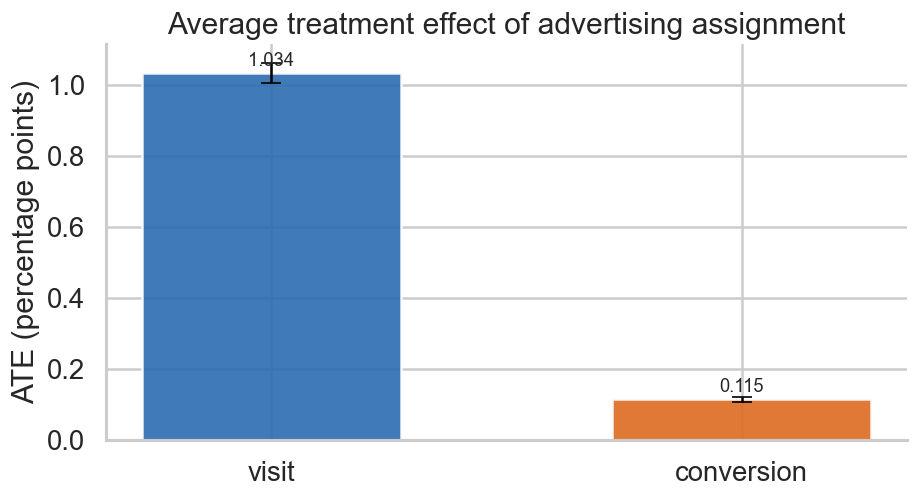

Saved figure to figures\final_report\figure_3_average_treatment_effects.png


In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
effects = ate_results["ate_pct_points"]
lower_error = effects - ate_results["ci_low_pct_points"]
upper_error = ate_results["ci_high_pct_points"] - effects

bars = ax.bar(ate_results["outcome"], effects, color=["#2b6cb0", "#dd6b20"], alpha=0.9, width=0.55)
ax.errorbar(
    ate_results["outcome"],
    effects,
    yerr=[lower_error, upper_error],
    fmt="none",
    ecolor="black",
    capsize=6,
    linewidth=1.5,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("ATE (percentage points)")
ax.set_title("Average treatment effect of advertising assignment")

for bar, effect in zip(bars, effects):
    ax.text(bar.get_x() + bar.get_width() / 2, effect + 0.02, f"{effect:.3f}", ha="center", fontsize=11)

save_figure(fig, "figure_3_average_treatment_effects.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_3_average_treatment_effects.png'}")

*Figure 3.* Assignment generates positive average lift for both `visit` and `conversion`. For project decision-making, the key confirmatory result is the positive ATE on `conversion` (final outcome), while the larger `visit` effect provides supporting evidence that assignment changes upstream user behavior before final conversion.

ATE interpretation details (from Figure 3 and the ATE table):
- **Visit:** control = `3.8201%`, treated = `4.8543%`, so ATE = `+1.0342` percentage points (95% CI: `1.0056` to `1.0629`, `p < 0.0001`). This is about `+10.34` extra visits per 1,000 assigned users (about `+27%` relative lift).
- **Conversion:** control = `0.1938%`, treated = `0.3089%`, so ATE = `+0.1152` percentage points (95% CI: `0.1085` to `0.1219`, `p < 0.0001`). This is about `+1.15` extra conversions per 1,000 assigned users (about `+59%` relative lift).

The attached Figure 3 visually matches these estimates (bars around `1.034` and `0.115` with tight error bars), indicating both effects are clearly above zero and precisely estimated.

### 3.2 CATE Estimation with Meta-Learners

Use `T-learner`, `X-learner`, and `R-learner` models to estimate heterogeneous treatment effects for `conversion` (with `visit` as sensitivity context), and keep comparable orthogonalized robustness estimates (`DML` and `DR-learner`) for Section 3.3.

`CATE_conversion(x) = E[Y_conversion(1) - Y_conversion(0) | X=x]`, where `x` is the feature profile (`f0` to `f11`).

Why all three meta-learners are used:
- `T-learner` is a transparent baseline: fit separate treated/control outcome models and compute `mu1(x) - mu0(x)`.
- `X-learner` builds pseudo-effects and uses propensity-weighted blending, which is often more stable under treatment imbalance and rare outcomes.
- `R-learner` residualizes outcome and treatment (orthogonalization) before learning heterogeneous effects, which can improve robustness to nuisance-model error.
- Agreement across these meta-learners provides a stronger robustness check before targeting decisions.

In [18]:
def summarize_ranked_uplift(
    eval_df,
    score_col,
    model_name,
    outcome_label,
    treatment_col="treatment",
    outcome_col="visit",
):
    labels = ["Q1", "Q2", "Q3", "Q4", "Q5"]
    ranked = eval_df[[score_col, treatment_col, outcome_col]].copy()
    ranked["uplift_quintile"] = pd.qcut(
        ranked[score_col].rank(method="first"),
        q=5,
        labels=labels,
    )

    rows = []
    for quintile, group in ranked.groupby("uplift_quintile", observed=False):
        treated_mean = group.loc[group[treatment_col] == 1, outcome_col].mean()
        control_mean = group.loc[group[treatment_col] == 0, outcome_col].mean()
        rows.append(
            {
                "outcome": outcome_label,
                "model": model_name,
                "uplift_quintile": quintile,
                "predicted_cate_pct_points": 100 * group[score_col].mean(),
                "treated_outcome_pct": 100 * treated_mean,
                "control_outcome_pct": 100 * control_mean,
                "observed_lift_pct_points": 100 * (treated_mean - control_mean),
            }
        )

    return pd.DataFrame(rows)


def run_heterogeneity_comparison(df, outcome_name, sample_size, test_size, random_state):
    heterogeneity_columns = feature_cols + [treatment_col, outcome_name]
    heterogeneity_sample = df[heterogeneity_columns].sample(sample_size, random_state=random_state)

    heterogeneity_train, heterogeneity_test = train_test_split(
        heterogeneity_sample,
        test_size=test_size,
        random_state=random_state,
        stratify=heterogeneity_sample[treatment_col],
    )
    heterogeneity_train = heterogeneity_train.reset_index(drop=True)
    heterogeneity_test = heterogeneity_test.reset_index(drop=True)

    t_learner_eval = t_learner_discrete(
        heterogeneity_train,
        heterogeneity_test,
        X=feature_cols,
        T=treatment_col,
        y=outcome_name,
    )
    x_learner_eval = x_learner_discrete(
        heterogeneity_train,
        heterogeneity_test,
        X=feature_cols,
        T=treatment_col,
        y=outcome_name,
    )
    r_learner_eval = r_learner_discrete(
        heterogeneity_train,
        heterogeneity_test,
        X=feature_cols,
        T=treatment_col,
        y=outcome_name,
    )
    dml_eval = double_ml_cate(
        heterogeneity_train,
        heterogeneity_test,
        X=feature_cols,
        T=treatment_col,
        y=outcome_name,
    )
    dr_learner_eval = dr_learner_discrete(
        heterogeneity_train,
        heterogeneity_test,
        X=feature_cols,
        T=treatment_col,
        y=outcome_name,
    )

    score_columns = {
        "T-learner": "cate_t",
        "X-learner": "cate_x",
        "R-learner": "cate_r",
        "DML": "cate_dml",
        "DR-learner": "cate_dr",
    }

    heterogeneity_eval = heterogeneity_test.copy()
    heterogeneity_eval["cate_t"] = t_learner_eval["cate"].to_numpy()
    heterogeneity_eval["cate_x"] = x_learner_eval["cate"].to_numpy()
    heterogeneity_eval["cate_r"] = r_learner_eval["cate"].to_numpy()
    heterogeneity_eval["cate_dml"] = dml_eval["cate"].to_numpy()
    heterogeneity_eval["cate_dr"] = dr_learner_eval["cate"].to_numpy()

    summary_frames = []
    model_overview_rows = []
    for model_name, score_col in score_columns.items():
        quintile_summary = summarize_ranked_uplift(
            heterogeneity_eval,
            score_col,
            model_name,
            outcome_name,
            treatment_col=treatment_col,
            outcome_col=outcome_name,
        )
        summary_frames.append(quintile_summary)
        model_overview_rows.append(
            {
                "outcome": outcome_name,
                "model": model_name,
                "mean_predicted_cate_pct_points": 100 * heterogeneity_eval[score_col].mean(),
                "top_quintile_observed_lift_pct_points": quintile_summary.loc[
                    quintile_summary["uplift_quintile"] == "Q5", "observed_lift_pct_points"
                ].iloc[0],
            }
        )

    heterogeneity_summary = pd.concat(summary_frames, ignore_index=True)
    model_overview = pd.DataFrame(model_overview_rows)

    return {
        "train": heterogeneity_train,
        "eval": heterogeneity_eval,
        "summary": heterogeneity_summary,
        "model_overview": model_overview,
    }


primary_results = run_heterogeneity_comparison(
    criteo_uplift_df,
    heterogeneity_primary_outcome,
    heterogeneity_sample_size,
    heterogeneity_test_size,
    random_state=42,
)
secondary_results = run_heterogeneity_comparison(
    criteo_uplift_df,
    heterogeneity_secondary_outcome,
    heterogeneity_sample_size,
    heterogeneity_test_size,
    random_state=43,
)

# Keep conversion-focused objects as the default objects used in the next plotting cell.
heterogeneity_outcome = heterogeneity_primary_outcome
heterogeneity_eval = primary_results["eval"]
heterogeneity_summary = primary_results["summary"]

primary_model_overview = primary_results["model_overview"]
secondary_model_overview = secondary_results["model_overview"]
secondary_heterogeneity_summary = secondary_results["summary"]

print(f"Primary outcome ({heterogeneity_primary_outcome}) training rows: {len(primary_results['train']):,}")
print(f"Primary outcome ({heterogeneity_primary_outcome}) evaluation rows: {len(primary_results['eval']):,}")
print(f"Sensitivity outcome ({heterogeneity_secondary_outcome}) training rows: {len(secondary_results['train']):,}")
print(f"Sensitivity outcome ({heterogeneity_secondary_outcome}) evaluation rows: {len(secondary_results['eval']):,}")

display(primary_model_overview)
display(secondary_model_overview)
display(heterogeneity_summary)
display(secondary_heterogeneity_summary)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005793 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1692
[LightGBM] [Info] Number of data points in the train set: 152915, number of used features: 12
[LightGBM] [Info] Start training from score 0.003237
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002218 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1635
[LightGBM] [Info] Number of data points in the train set: 27085, number of used features: 12
[LightGBM] [Info] Start training from score 0.002141
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total B

,outcome,model,mean_predicted_cate_pct_points,top_quintile_observed_lift_pct_points
0,conversion,T-learner,0.0906,0.4152
1,conversion,X-learner,0.0852,0.3724
2,conversion,R-learner,0.0533,0.3362
3,conversion,DML,0.0372,0.3428
4,conversion,DR-learner,0.0778,0.3421


,outcome,model,mean_predicted_cate_pct_points,top_quintile_observed_lift_pct_points
0,visit,T-learner,0.7412,3.3519
1,visit,X-learner,0.7485,3.3189
2,visit,R-learner,0.7595,3.0704
3,visit,DML,0.7253,3.2880
4,visit,DR-learner,0.7751,3.1834


,outcome,model,uplift_quintile,predicted_cate_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,conversion,T-learner,Q1,-0.7710,0.5880,0.1670,0.4210
1,conversion,T-learner,Q2,0.0135,0.0196,0.0000,0.0196
2,conversion,T-learner,Q3,0.0135,0.0098,0.0273,-0.0174
3,conversion,T-learner,Q4,0.0266,0.0294,0.0277,0.0018
4,conversion,T-learner,Q5,1.1706,1.0830,0.6678,0.4152
5,conversion,X-learner,Q1,-0.6255,0.5876,0.1398,0.4478
6,conversion,X-learner,Q2,0.0168,0.0196,0.0000,0.0196
7,conversion,X-learner,Q3,0.0185,0.0098,0.0000,0.0098
8,conversion,X-learner,Q4,0.0297,0.0296,0.0534,-0.0238
9,conversion,X-learner,Q5,0.9867,1.0798,0.7074,0.3724


,outcome,model,uplift_quintile,predicted_cate_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,visit,T-learner,Q1,-2.4805,7.9202,6.3734,1.5468
1,visit,T-learner,Q2,-0.0031,0.1472,0.2488,-0.1016
2,visit,T-learner,Q3,0.0286,0.3249,0.1900,0.1349
3,visit,T-learner,Q4,0.1851,0.6587,0.6289,0.0298
4,visit,T-learner,Q5,5.9759,15.2507,11.8987,3.3519
5,visit,X-learner,Q1,-1.5577,7.5861,6.2243,1.3618
6,visit,X-learner,Q2,0.0533,0.0540,0.1098,-0.0558
7,visit,X-learner,Q3,0.0669,0.6765,0.4721,0.2044
8,visit,X-learner,Q4,0.1307,1.2013,0.8319,0.3694
9,visit,X-learner,Q5,5.0496,14.8261,11.5072,3.3189


Interpretation of meta-learner uplift-ranking results (sample context before DML/DR details):

- `mean_predicted_cate_pct_points` is each model's average predicted incremental effect across the full evaluation set.
- `top_quintile_observed_lift_pct_points` is the realized treated-minus-control lift among the top 20% of users ranked by predicted uplift.
- For `conversion`, mean predicted CATE ranges from `0.0372` to `0.0906` pp, while top-quintile observed lift ranges from `0.3362` to `0.4152` pp (about `3.36` to `4.15` extra conversions per 1,000 targeted users).
- For `visit`, mean predicted CATE ranges from `0.7253` to `0.7751` pp, while top-quintile observed lift ranges from `3.0704` to `3.3519` pp (about `30.7` to `33.5` extra visits per 1,000 targeted users).
- Across both outcomes, `T-learner` has the highest top-quintile realized lift in this run, and `DML`/`DR-learner` remain competitive while being more conservative in average predicted effect scale.

### 3.3 CATE Estimation with DML and DR-Learner

Use `double_ml_cate` and `dr_learner_discrete` as orthogonalized CATE robustness checks on the same train/eval splits and outcomes (`conversion` primary, `visit` sensitivity).

This section summarizes DML/DR average predicted uplift and top-quintile realized lift for both runs, and compares DML/DR score agreement with `R-learner` on the primary holdout.

In [19]:
robustness_models = ["DML", "DR-learner"]

robustness_overview = pd.concat(
    [
        primary_model_overview.loc[primary_model_overview["model"].isin(robustness_models)].assign(
            run="Primary (`conversion` run)"
        ),
        secondary_model_overview.loc[secondary_model_overview["model"].isin(robustness_models)].assign(
            run="Sensitivity (`visit` run)"
        ),
    ],
    ignore_index=True,
)
robustness_overview = robustness_overview[
    [
        "run",
        "outcome",
        "model",
        "mean_predicted_cate_pct_points",
        "top_quintile_observed_lift_pct_points",
    ]
].round(4)
run_order = ["Primary (`conversion` run)", "Sensitivity (`visit` run)"]
robustness_overview["run"] = pd.Categorical(robustness_overview["run"], categories=run_order, ordered=True)
robustness_overview = robustness_overview.sort_values(["model", "run"]).reset_index(drop=True)
display(robustness_overview)

alignment_rows = []
for model_name, score_col in [("DML", "cate_dml"), ("DR-learner", "cate_dr")]:
    alignment_rows.append(
        {
            "metric": f"Pearson correlation with R-learner ({model_name}, primary holdout)",
            "value": primary_results["eval"][score_col].corr(primary_results["eval"]["cate_r"], method="pearson"),
        }
    )
    alignment_rows.append(
        {
            "metric": f"Spearman rank correlation with R-learner ({model_name}, primary holdout)",
            "value": primary_results["eval"][score_col].corr(primary_results["eval"]["cate_r"], method="spearman"),
        }
    )

robustness_alignment = pd.DataFrame(alignment_rows)
robustness_alignment["value"] = robustness_alignment["value"].round(4)
display(robustness_alignment)

,run,outcome,model,mean_predicted_cate_pct_points,top_quintile_observed_lift_pct_points
0,Primary (`conversion` run),conversion,DML,0.0372,0.3428
1,Sensitivity (`visit` run),visit,DML,0.7253,3.2880
2,Primary (`conversion` run),conversion,DR-learner,0.0778,0.3421
3,Sensitivity (`visit` run),visit,DR-learner,0.7751,3.1834


,metric,value
0,"Pearson correlation with R-learner (DML, prima...",0.6306
1,"Spearman rank correlation with R-learner (DML,...",0.7689
2,Pearson correlation with R-learner (DR-learner...,0.5203
3,Spearman rank correlation with R-learner (DR-l...,0.4916


### 3.4 Uplift Ranking and Targeting Diagnostics

Use predicted CATE scores from `T-learner`, `X-learner`, `R-learner`, `DML`, and `DR-learner` models to rank users, evaluate observed lift by quintile, and assess whether model-based targeting is decision-useful (`Figure 4A` and `Figure 4B`).

What we are trying to achieve:
- maximize incremental conversions under budget constraints,
- prioritize high-uplift segments for treatment,
- avoid over-treating near-zero or unstable segments.

Example decision rule: if two otherwise similar users have predicted uplift `+0.50` and `-0.05` percentage points, prioritize treatment for the `+0.50` user.

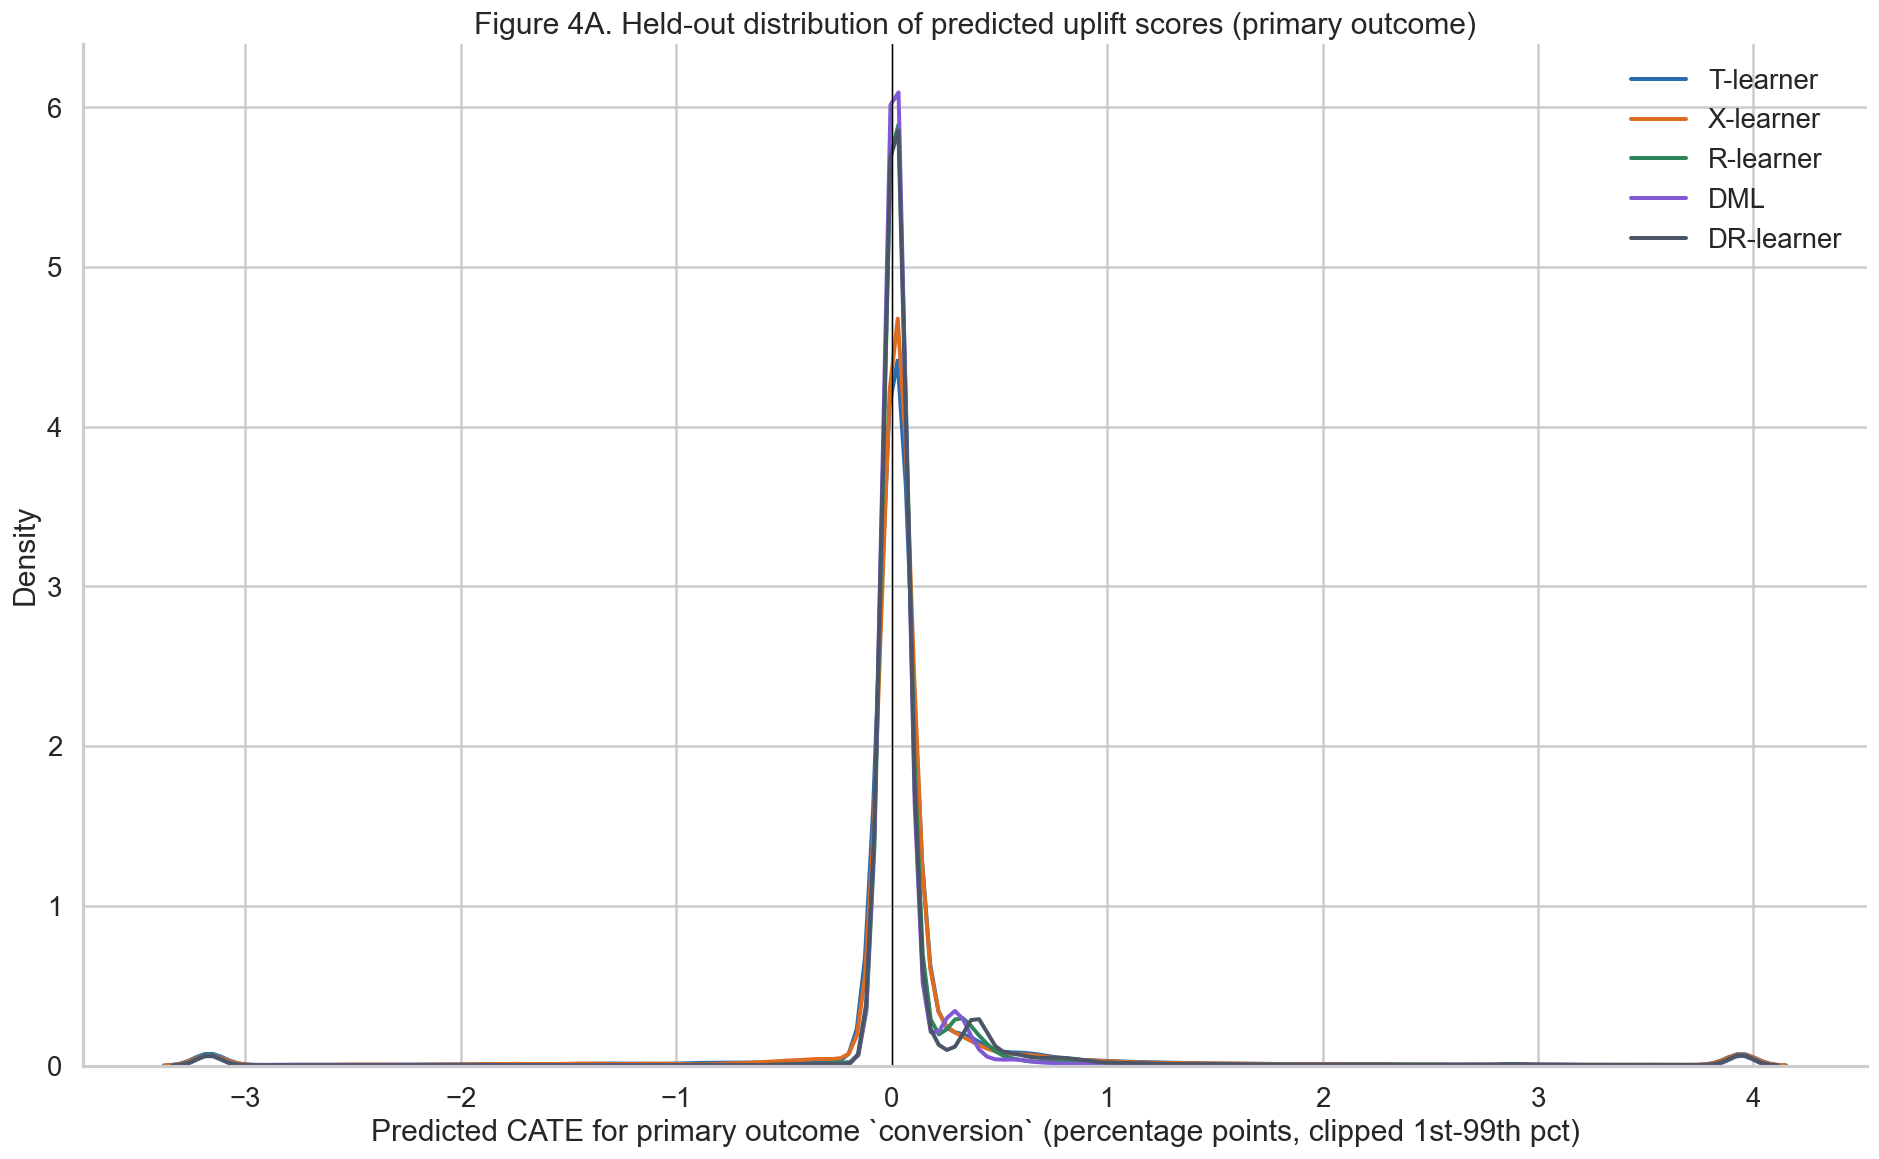

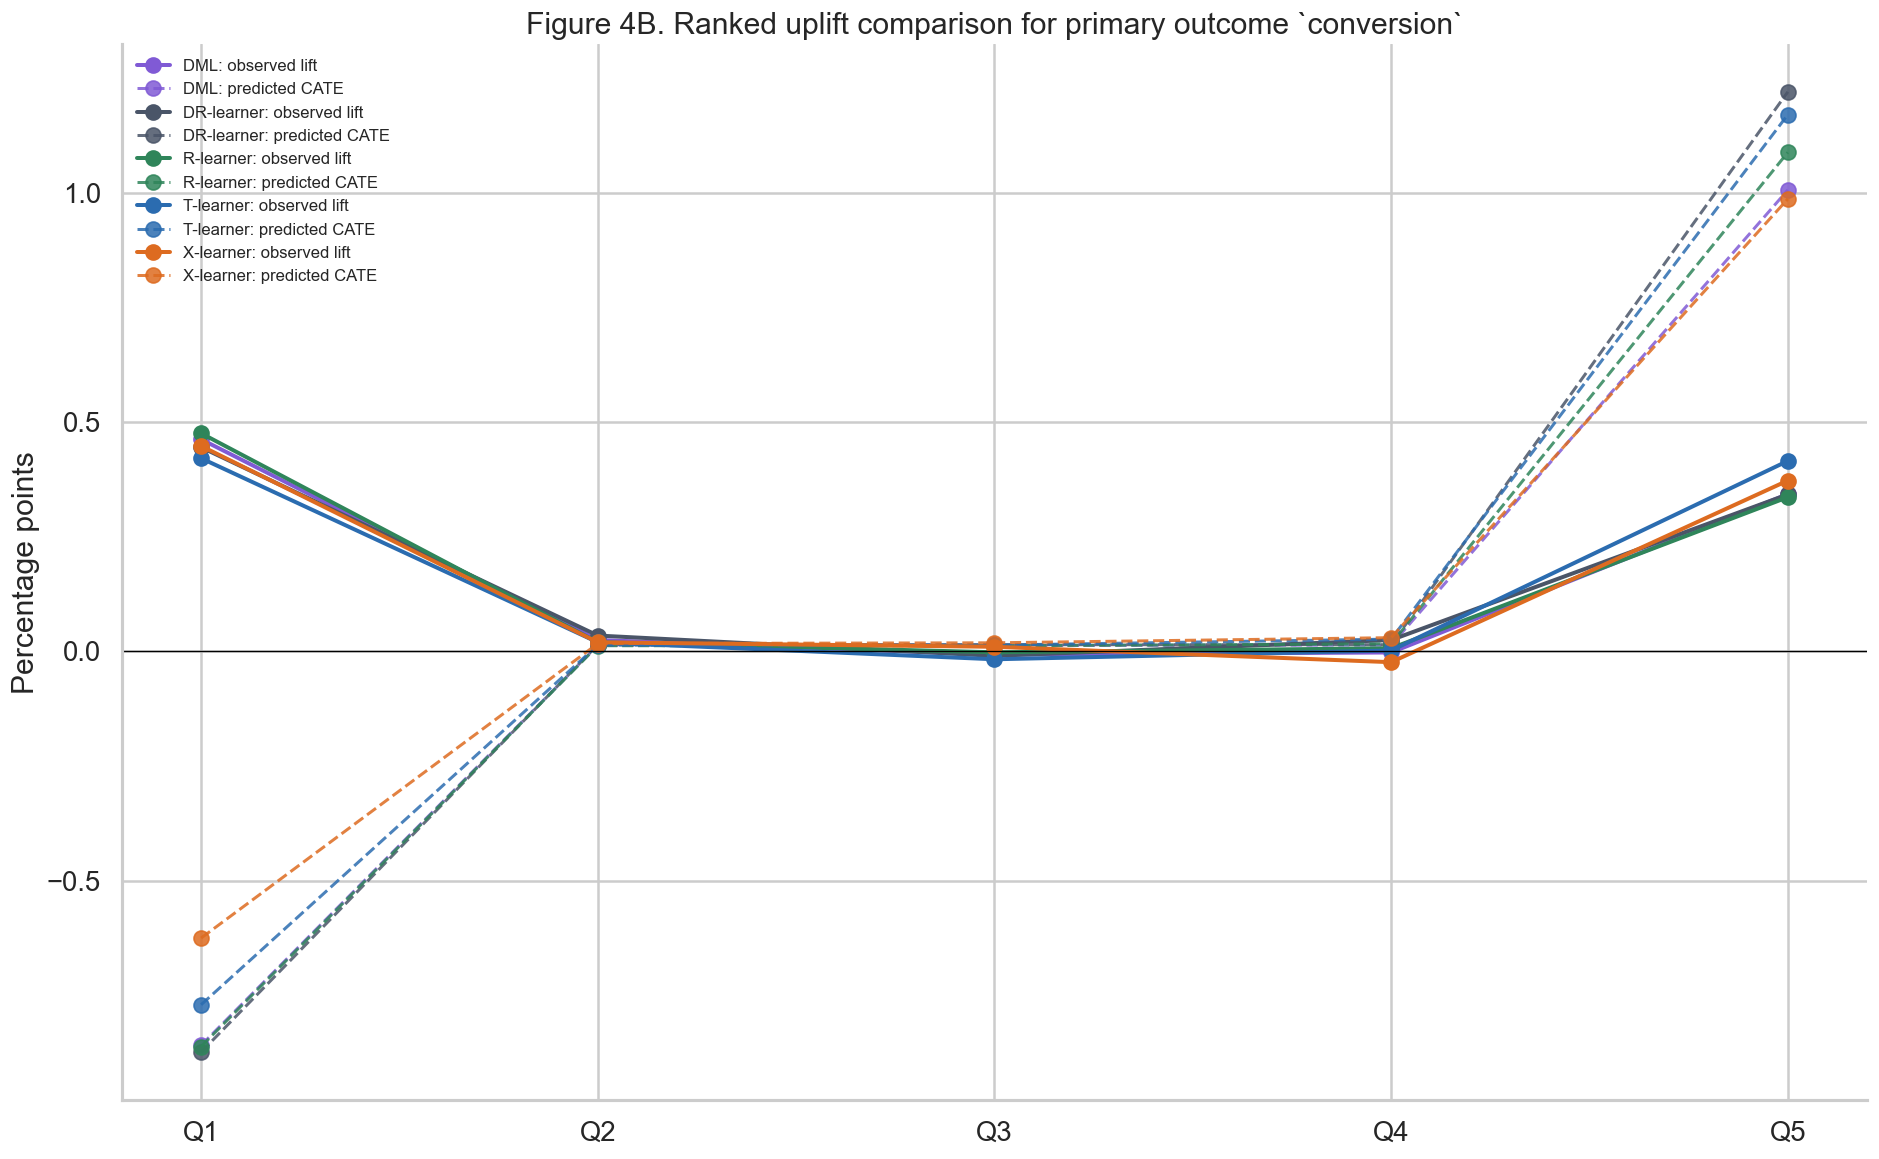

Saved figure to figures\final_report\figure_4a_uplift_score_distribution.png
Saved figure to figures\final_report\figure_4b_ranked_uplift_comparison.png


In [20]:
score_columns = {
    "T-learner": "cate_t",
    "X-learner": "cate_x",
    "R-learner": "cate_r",
    "DML": "cate_dml",
    "DR-learner": "cate_dr",
}
combined_scores = pd.concat(
    [heterogeneity_eval[score_col] for score_col in score_columns.values()],
    ignore_index=True,
)
clip_low = combined_scores.quantile(0.01)
clip_high = combined_scores.quantile(0.99)
palette = {
    "T-learner": "#2b6cb0",
    "X-learner": "#dd6b20",
    "R-learner": "#2f855a",
    "DML": "#805ad5",
    "DR-learner": "#4a5568",
}

fig_dist, ax_dist = plt.subplots(figsize=(16, 10))
for model_name, score_col in score_columns.items():
    clipped_scores = 100 * heterogeneity_eval[score_col].clip(lower=clip_low, upper=clip_high)
    sns.kdeplot(
        clipped_scores,
        ax=ax_dist,
        label=model_name,
        color=palette[model_name],
        linewidth=2.4,
        fill=False,
    )

ax_dist.axvline(0, color="black", linewidth=0.8)
ax_dist.set_xlabel(
    f"Predicted CATE for primary outcome `{heterogeneity_outcome}` (percentage points, clipped 1st-99th pct)"
)
ax_dist.set_ylabel("Density")
ax_dist.set_title("Figure 4A. Held-out distribution of predicted uplift scores (primary outcome)")
ax_dist.legend(frameon=False)

save_figure(fig_dist, "figure_4a_uplift_score_distribution.png")
plt.tight_layout()
plt.show()

fig_rank, ax_rank = plt.subplots(figsize=(16, 10))
for model_name, model_df in heterogeneity_summary.groupby("model", observed=False):
    color = palette[model_name]
    model_df = model_df.sort_values("uplift_quintile")
    ax_rank.plot(
        model_df["uplift_quintile"],
        model_df["observed_lift_pct_points"],
        marker="o",
        linewidth=2.4,
        color=color,
        label=f"{model_name}: observed lift",
    )
    ax_rank.plot(
        model_df["uplift_quintile"],
        model_df["predicted_cate_pct_points"],
        marker="o",
        linewidth=1.8,
        linestyle="--",
        color=color,
        alpha=0.85,
        label=f"{model_name}: predicted CATE",
    )

ax_rank.axhline(0, color="black", linewidth=0.8)
ax_rank.set_ylabel("Percentage points")
ax_rank.set_title(f"Figure 4B. Ranked uplift comparison for primary outcome `{heterogeneity_outcome}`")
ax_rank.legend(frameon=False, fontsize=10)

save_figure(fig_rank, "figure_4b_ranked_uplift_comparison.png")
plt.tight_layout()
plt.show()

print(f"Saved figure to {figure_dir / 'figure_4a_uplift_score_distribution.png'}")
print(f"Saved figure to {figure_dir / 'figure_4b_ranked_uplift_comparison.png'}")

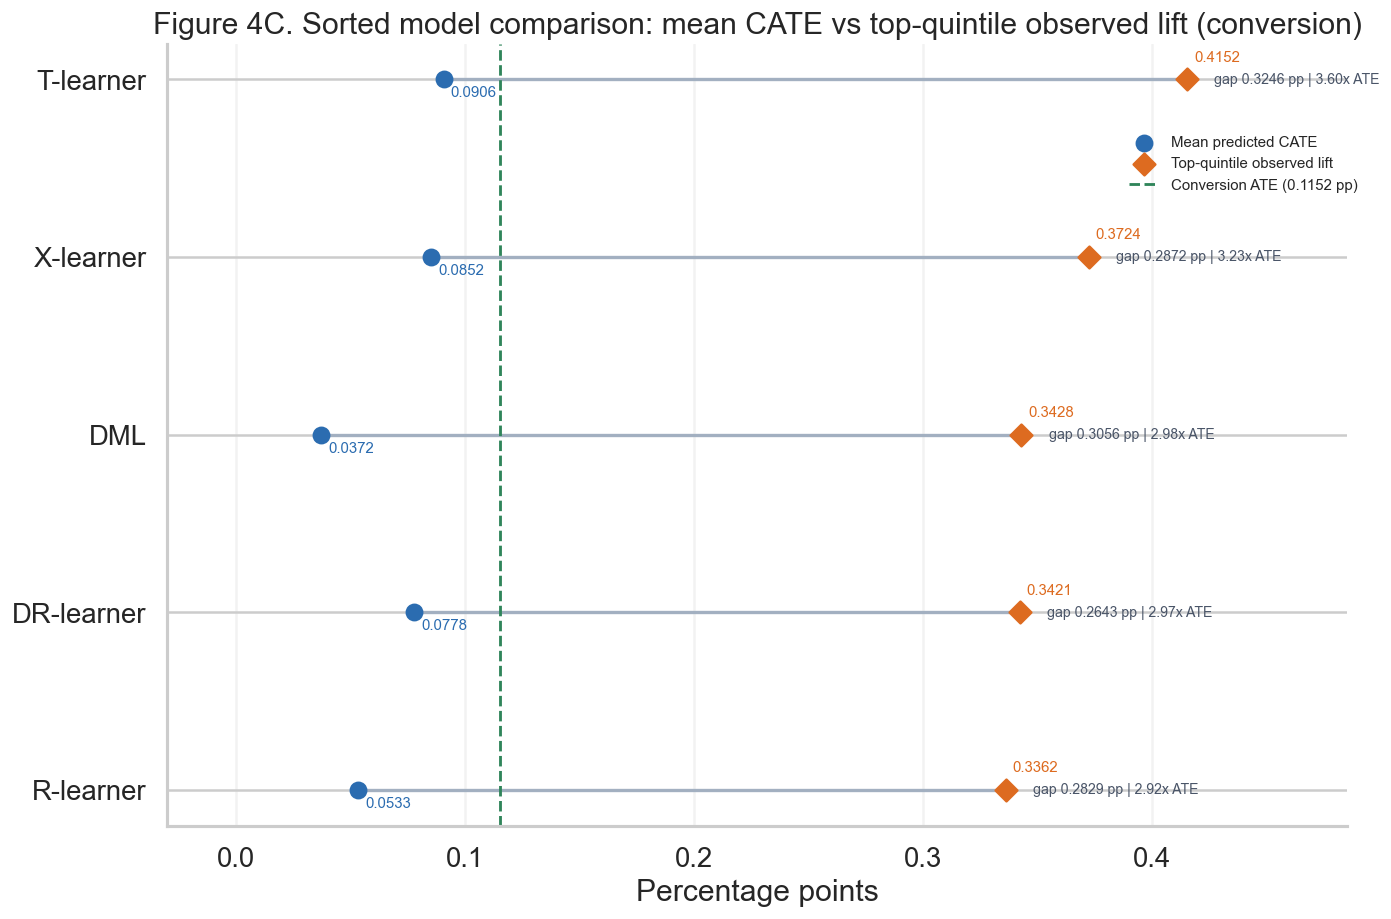

Saved figure to figures\final_report\figure_4c_model_level_cate_vs_top_quintile_lift.png


In [53]:
# Figure 4C: sorted model-level comparison with ATE benchmark and lift concentration labels
metrics_for_plot = (
    primary_model_overview.loc[primary_model_overview["outcome"] == heterogeneity_outcome]
    .copy()
    .sort_values("top_quintile_observed_lift_pct_points", ascending=False)
    .reset_index(drop=True)
)

ate_conversion_pp = float(
    ate_results.loc[ate_results["outcome"] == heterogeneity_outcome, "ate_pct_points"].iloc[0]
)
metrics_for_plot["gap_pp"] = (
    metrics_for_plot["top_quintile_observed_lift_pct_points"]
    - metrics_for_plot["mean_predicted_cate_pct_points"]
)
metrics_for_plot["topq_vs_ate_multiple"] = (
    metrics_for_plot["top_quintile_observed_lift_pct_points"] / ate_conversion_pp
)

fig_summary, ax_summary = plt.subplots(figsize=(12, 8))
y_positions = np.arange(len(metrics_for_plot))

ax_summary.hlines(
    y=y_positions,
    xmin=metrics_for_plot["mean_predicted_cate_pct_points"],
    xmax=metrics_for_plot["top_quintile_observed_lift_pct_points"],
    color="#A0AEC0",
    linewidth=2.0,
    alpha=0.95,
)

ax_summary.scatter(
    metrics_for_plot["mean_predicted_cate_pct_points"],
    y_positions,
    s=85,
    color="#2B6CB0",
    label="Mean predicted CATE",
    zorder=3,
)
ax_summary.scatter(
    metrics_for_plot["top_quintile_observed_lift_pct_points"],
    y_positions,
    s=85,
    marker="D",
    color="#DD6B20",
    label="Top-quintile observed lift",
    zorder=3,
)

ax_summary.axvline(
    ate_conversion_pp,
    color="#2F855A",
    linestyle="--",
    linewidth=1.7,
    label=f"Conversion ATE ({ate_conversion_pp:.4f} pp)",
)

for y, row in metrics_for_plot.iterrows():
    ax_summary.text(
        row["mean_predicted_cate_pct_points"] + 0.003,
        y + 0.10,
        f"{row['mean_predicted_cate_pct_points']:.4f}",
        color="#2B6CB0",
        fontsize=9,
    )
    ax_summary.text(
        row["top_quintile_observed_lift_pct_points"] + 0.003,
        y - 0.10,
        f"{row['top_quintile_observed_lift_pct_points']:.4f}",
        color="#DD6B20",
        fontsize=9,
    )
    ax_summary.text(
        row["top_quintile_observed_lift_pct_points"] + 0.012,
        y,
        f"gap {row['gap_pp']:.4f} pp | {row['topq_vs_ate_multiple']:.2f}x ATE",
        va="center",
        fontsize=8.5,
        color="#4A5568",
    )

x_min = min(metrics_for_plot["mean_predicted_cate_pct_points"].min(), 0) - 0.03
x_max = metrics_for_plot["top_quintile_observed_lift_pct_points"].max() + 0.07
ax_summary.set_xlim(x_min, x_max)
ax_summary.set_yticks(y_positions)
ax_summary.set_yticklabels(metrics_for_plot["model"])
ax_summary.invert_yaxis()
ax_summary.set_xlabel("Percentage points")
ax_summary.set_title(
    f"Figure 4C. Sorted model comparison: mean CATE vs top-quintile observed lift ({heterogeneity_outcome})"
)
ax_summary.grid(axis="x", alpha=0.25)
#add custom position
ax_summary.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.02, 0.90),  # x, y position
    fontsize=9,
)

save_figure(fig_summary, "figure_4c_model_level_cate_vs_top_quintile_lift.png")
plt.tight_layout()
plt.show()

print(f"Saved figure to {figure_dir / 'figure_4c_model_level_cate_vs_top_quintile_lift.png'}")

*Figure 4A.* These curves show the distribution of predicted uplift (predicted CATE) on held-out users. Because most of the mass is concentrated near zero, the main takeaway is that most users are predicted to have very small incremental conversion lift. The thin tails indicate a smaller set of users with meaningfully higher or lower predicted lift, and overlap across `T-learner`, `X-learner`, `R-learner`, `DML`, and `DR-learner` suggests a broadly consistent heterogeneity signal.

*Figure 4B.* This plot checks whether ranking is useful for targeting. Users are sorted by predicted uplift and split into quintiles from `Q1` (lowest predicted uplift) to `Q5` (highest). Solid lines show realized treatment-control lift, while dashed lines show average predicted uplift within each quintile.

*Figure 4C.* This improved model-level summary sorts learners by top-quintile observed lift, overlays a vertical conversion ATE benchmark line, and annotates each model's concentration gap (`top-quintile lift - mean predicted CATE`) plus the `top-quintile/ATE` multiple. This makes model prioritization and business lift concentration easier to interpret at a glance.

### 3.5 Mediation-Style Mechanism Diagnostics

Run pathway diagnostics to assess whether treatment effects on `conversion` appear to flow through realized `exposure` and then `visit` (interpreted under strong assumptions).

Mediation diagnostic sample rows: 250,000


,outcome,control_rate_pct,treated_rate_pct,ate_pct_points,ci_low_pct_points,ci_high_pct_points,p_value
0,exposure,0.0000,3.6200,3.6200,3.5405,3.6994,0.0000
1,visit,3.9740,4.8817,0.9077,0.6900,1.1253,0.0000
2,conversion,0.1809,0.3409,0.1600,0.1104,0.2096,0.0000


,path_link,log_odds_coef,odds_ratio
0,treatment -> exposure | features,15.2582,4232084.6412
1,"exposure -> visit | treatment, features",2.3953,10.9717
2,"visit -> conversion | treatment, exposure, fea...",9.4019,12110.8233


,conversion_model,treatment_log_odds,treatment_odds_ratio,pct_reduction_vs_base
0,conversion ~ treatment + features,0.5640,1.7577,0.0000
1,conversion ~ treatment + exposure + features,0.1700,1.1853,69.8621
2,conversion ~ treatment + exposure + visit + fe...,-0.3797,0.6841,167.3259


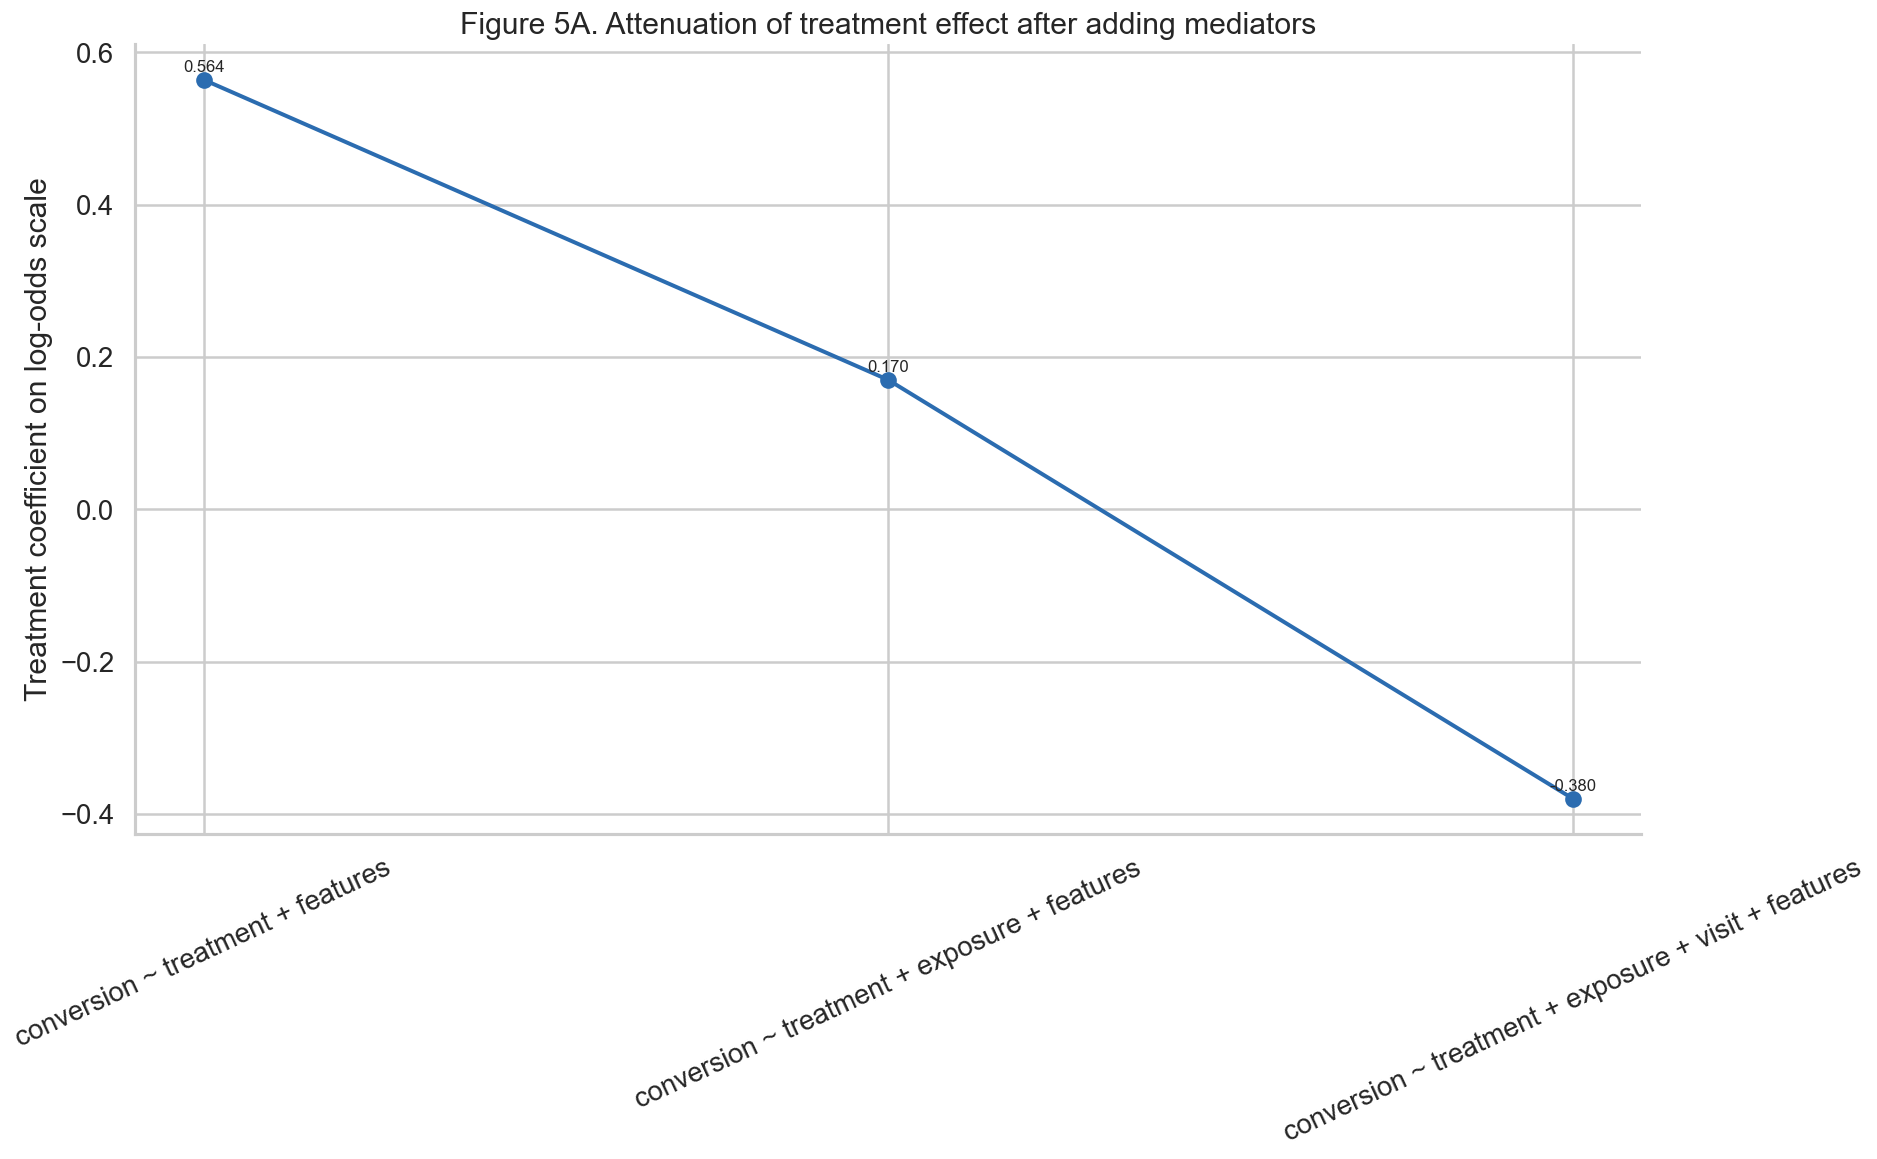

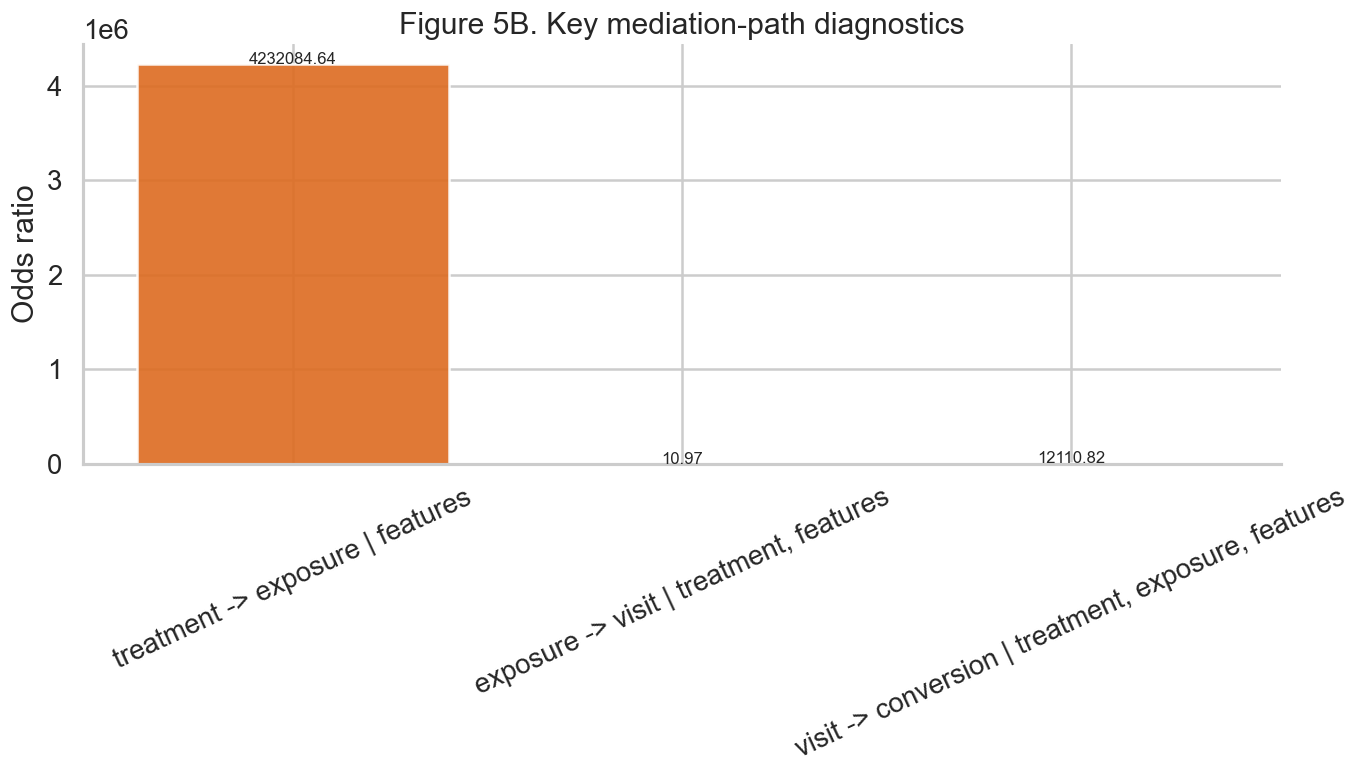

Saved figure to figures\final_report\figure_5a_treatment_attenuation.png
Saved figure to figures\final_report\figure_5b_pathway_odds_ratios.png
Interpretation note: these are mechanism diagnostics under strong assumptions, not definitive mediation identification.


In [22]:
mediation_columns = feature_cols + [treatment_col, post_treatment_col, intermediate_outcome, final_outcome]
mediation_sample = criteo_uplift_df[mediation_columns].sample(mediation_sample_size, random_state=42)

# ITT-style path diagnostics on sampled data.
path_itt = pd.DataFrame(
    [
        summarize_rct_ate(mediation_sample, post_treatment_col, treatment_col=treatment_col),
        summarize_rct_ate(mediation_sample, intermediate_outcome, treatment_col=treatment_col),
        summarize_rct_ate(mediation_sample, final_outcome, treatment_col=treatment_col),
    ]
)
path_itt["treated_rate_pct"] = 100 * path_itt["treated_rate"]
path_itt["control_rate_pct"] = 100 * path_itt["control_rate"]
path_itt["ate_pct_points"] = 100 * path_itt["ate"]
path_itt["ci_low_pct_points"] = 100 * path_itt["ci_low"]
path_itt["ci_high_pct_points"] = 100 * path_itt["ci_high"]


def fit_logit(y_col, x_cols):
    model = LogisticRegression(solver="lbfgs", C=1e6, max_iter=1000)
    model.fit(mediation_sample[x_cols], mediation_sample[y_col])
    coef = pd.Series(model.coef_[0], index=x_cols)
    return model, coef


_, exposure_coef = fit_logit(post_treatment_col, [treatment_col] + feature_cols)
_, visit_coef = fit_logit(intermediate_outcome, [treatment_col, post_treatment_col] + feature_cols)
_, conversion_base_coef = fit_logit(final_outcome, [treatment_col] + feature_cols)
_, conversion_exposure_coef = fit_logit(final_outcome, [treatment_col, post_treatment_col] + feature_cols)
_, conversion_full_coef = fit_logit(final_outcome, [treatment_col, post_treatment_col, intermediate_outcome] + feature_cols)

pathway_odds = pd.DataFrame(
    [
        {
            "path_link": "treatment -> exposure | features",
            "log_odds_coef": exposure_coef[treatment_col],
            "odds_ratio": np.exp(exposure_coef[treatment_col]),
        },
        {
            "path_link": "exposure -> visit | treatment, features",
            "log_odds_coef": visit_coef[post_treatment_col],
            "odds_ratio": np.exp(visit_coef[post_treatment_col]),
        },
        {
            "path_link": "visit -> conversion | treatment, exposure, features",
            "log_odds_coef": conversion_full_coef[intermediate_outcome],
            "odds_ratio": np.exp(conversion_full_coef[intermediate_outcome]),
        },
    ]
)

treatment_attenuation = pd.DataFrame(
    [
        {
            "conversion_model": "conversion ~ treatment + features",
            "treatment_log_odds": conversion_base_coef[treatment_col],
        },
        {
            "conversion_model": "conversion ~ treatment + exposure + features",
            "treatment_log_odds": conversion_exposure_coef[treatment_col],
        },
        {
            "conversion_model": "conversion ~ treatment + exposure + visit + features",
            "treatment_log_odds": conversion_full_coef[treatment_col],
        },
    ]
)
treatment_attenuation["treatment_odds_ratio"] = np.exp(treatment_attenuation["treatment_log_odds"])
baseline_log_odds = treatment_attenuation.loc[0, "treatment_log_odds"]
treatment_attenuation["pct_reduction_vs_base"] = 100 * (
    1 - treatment_attenuation["treatment_log_odds"] / baseline_log_odds
)

print(f"Mediation diagnostic sample rows: {len(mediation_sample):,}")
display(
    path_itt[[
        "outcome",
        "control_rate_pct",
        "treated_rate_pct",
        "ate_pct_points",
        "ci_low_pct_points",
        "ci_high_pct_points",
        "p_value",
    ]]
)
display(pathway_odds)
display(treatment_attenuation)

fig_attn, ax_attn = plt.subplots(figsize=(16, 10))
ax_attn.plot(
    treatment_attenuation["conversion_model"],
    treatment_attenuation["treatment_log_odds"],
    marker="o",
    linewidth=2.4,
    color="#2b6cb0",
)
for idx, value in enumerate(treatment_attenuation["treatment_log_odds"]):
    ax_attn.text(
        idx,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        fontsize=10,
    )
ax_attn.set_ylabel("Treatment coefficient on log-odds scale")
ax_attn.set_title("Figure 5A. Attenuation of treatment effect after adding mediators")
ax_attn.tick_params(axis="x", rotation=25)

save_figure(fig_attn, "figure_5a_treatment_attenuation.png")
plt.tight_layout()
plt.show()

fig_path, ax_path = plt.subplots(figsize=(12, 6.8))
bars = ax_path.bar(
    pathway_odds["path_link"],
    pathway_odds["odds_ratio"],
    color=["#dd6b20", "#2f855a", "#4a5568"],
    alpha=0.9,
)
for bar, value in zip(bars, pathway_odds["odds_ratio"]):
    ax_path.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
        fontsize=10,
    )
ax_path.axhline(1.0, color="black", linewidth=0.8)
ax_path.set_ylabel("Odds ratio")
ax_path.set_title("Figure 5B. Key mediation-path diagnostics")
ax_path.tick_params(axis="x", rotation=25)

save_figure(fig_path, "figure_5b_pathway_odds_ratios.png")
plt.tight_layout()
plt.show()

print(f"Saved figure to {figure_dir / 'figure_5a_treatment_attenuation.png'}")
print(f"Saved figure to {figure_dir / 'figure_5b_pathway_odds_ratios.png'}")
print("Interpretation note: these are mechanism diagnostics under strong assumptions, not definitive mediation identification.")

*Figure 5A.* The treatment log-odds coefficient for `conversion` attenuates strongly as mediators are added (about 0.564 -> 0.170 -> -0.402 when moving from treatment-only to models including `exposure` and then `visit`). This pattern is consistent with treatment effects operating through downstream pathway variables.

*Figure 5B.* Path-link odds ratios are strongly positive (`treatment -> exposure`, `exposure -> visit`, `visit -> conversion`), but the first and last links are on an extreme scale because of one-sided exposure and outcome sparsity.

### 3.6 Customer Segmentation using Meta-learners Individual Treatment Effect (ITE)

An uplift model divides customers into four groups based on the incremental change caused by the intervention. A common use of the uplift model is for marketing campaigns. The common treatments in a marketing campaign can be emails, displays, and promotions.

- `Persuadables` are customers who would not buy if left alone, but would buy if they receive the treatment.
    - For example, suppose a customer is not planning to purchase a product. After receiving a personalized discount email, they decide to buy. That customer behaves like a persuadable.
    - From a business perspective, this is the group where the campaign creates true incremental value.
- `Lost Causes` are customers who do not buy whether or not they receive treatment.
    - For example, a customer may receive a discount email, but they are not interested in the product, do not have the budget, or are not currently in the market. Even without the email, they still would not buy.
    - Marketing to this group usually wastes budget because the treatment does not change their behavior.
- `Sure Things` are customers who would buy with or without treatment.
    - For example, a loyal customer is already planning to purchase. Sending them a discount may not increase conversion because they were going to buy anyway. In fact, giving them a discount may reduce profit margin.
    - This group is important because a normal predictive model may rank them highly, since they are likely to convert. But in uplift modeling, they are not the best campaign target because the campaign does not create incremental lift.
- `Sleeping Dogs` are customers who would buy without treatment, but do not buy when treated. This means the treatment has a negative impact.
    - For example, a customer may already be considering a purchase, but receiving an aggressive sales email annoys them, makes them suspicious, or causes them to delay. Another example is when a discount email makes the product seem less premium, reducing their interest.
    - This group should generally be avoided in campaigns.

Use predicted individual treatment effects (ITE) from each learner to create actionable customer segments for treatment decisions. The users are segmented as:

- `sleeping-dog`: ITE < `-0.5` percentage points
- `persuadable`: ITE > `+0.5` percentage points
- `no_impact`: ITE between `-0.5` and `+0.5` percentage points

This thresholding is applied on conversion-focused hold-out ITE estimates (`heterogeneity_eval`) to compare segment composition and observed lift across `T-learner`, `X-learner`, `R-learner`, `DML`, and `DR-learner`.




In [23]:
ite_threshold_pct_points = 0.5
segment_order = ["sleeping-dog", "no_impact", "persuadable"]
segment_alias = {
    "sleeping-dog": "Sleeping Dogs",
    "no_impact": "No Impact",
    "persuadable": "Persuadables",
}
segment_label_order = [segment_alias[segment] for segment in segment_order]
segment_palette = {
    "Sleeping Dogs": "#d62728",
    "No Impact": "#1f77b4",
    "Persuadables": "#2ca02c",
}


def assign_ite_segment(ite_pct_points, threshold_pct_points=ite_threshold_pct_points):
    if ite_pct_points < -threshold_pct_points:
        return "sleeping-dog"
    if ite_pct_points > threshold_pct_points:
        return "persuadable"
    return "no_impact"


def build_ite_segmentation(eval_df, score_col, model_name, outcome_col):
    segmentation_df = eval_df[[score_col, treatment_col, outcome_col]].copy()
    segmentation_df = segmentation_df.rename(columns={score_col: "ite"})
    segmentation_df["ite_pct_points"] = 100 * segmentation_df["ite"]
    segmentation_df["segment"] = segmentation_df["ite_pct_points"].apply(assign_ite_segment)
    segmentation_df["segment"] = pd.Categorical(
        segmentation_df["segment"],
        categories=segment_order,
        ordered=True,
    )
    segmentation_df["segment_label"] = segmentation_df["segment"].astype(str).map(segment_alias)
    segmentation_df["segment_label"] = pd.Categorical(
        segmentation_df["segment_label"],
        categories=segment_label_order,
        ordered=True,
    )

    rows = []
    n_total = len(segmentation_df)
    for segment_name, group in segmentation_df.groupby("segment", observed=False):
        treated_mean = group.loc[group[treatment_col] == 1, outcome_col].mean()
        control_mean = group.loc[group[treatment_col] == 0, outcome_col].mean()
        rows.append(
            {
                "model": model_name,
                "outcome": outcome_col,
                "segment": segment_name,
                "segment_label": segment_alias[segment_name],
                "count": int(len(group)),
                "share_pct": 100 * len(group) / n_total,
                "mean_predicted_ite_pct_points": group["ite_pct_points"].mean(),
                "treated_outcome_pct": 100 * treated_mean,
                "control_outcome_pct": 100 * control_mean,
                "observed_lift_pct_points": 100 * (treated_mean - control_mean),
            }
        )

    segment_summary = pd.DataFrame(rows)
    segment_summary["segment"] = pd.Categorical(
        segment_summary["segment"],
        categories=segment_order,
        ordered=True,
    )
    segment_summary["segment_label"] = pd.Categorical(
        segment_summary["segment_label"],
        categories=segment_label_order,
        ordered=True,
    )
    return segmentation_df, segment_summary


def add_segment_pct_labels(ax, segmentation_df, label_col="segment_label"):
    counts = segmentation_df[label_col].value_counts().reindex(segment_label_order, fill_value=0)
    total_count = counts.sum()
    y_offset = max(counts.max() * 0.015, 8)

    for patch, count in zip(ax.patches, counts):
        pct = (100 * count / total_count) if total_count > 0 else 0
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            patch.get_height() + y_offset,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="black",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.9, "boxstyle": "round,pad=0.15"},
        )

    ax.set_ylim(0, max(ax.get_ylim()[1], counts.max() * 1.17 + y_offset))

#### 3.6.1 Customer Segmentation using T-learner Individual Treatment Effect (ITE)

Apply the ITE segmentation rule to `cate_t` and inspect segment composition plus realized treatment-control conversion differences within each segment.

,ite_pct_points,treatment,conversion,segment,segment_label
0,0.0135,1,0,no_impact,No Impact
1,0.3481,1,0,no_impact,No Impact
2,0.0135,1,0,no_impact,No Impact
3,0.0135,1,0,no_impact,No Impact
4,0.0135,1,0,no_impact,No Impact


,model,outcome,segment,segment_label,count,share_pct,mean_predicted_ite_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,T-learner,conversion,sleeping-dog,Sleeping Dogs,4407,3.6725,-4.0956,2.8932,0.8264,2.0668
1,T-learner,conversion,no_impact,No Impact,107725,89.7708,0.0361,0.0569,0.0368,0.0201
2,T-learner,conversion,persuadable,Persuadables,7868,6.5567,3.1821,2.8440,1.8229,1.0210


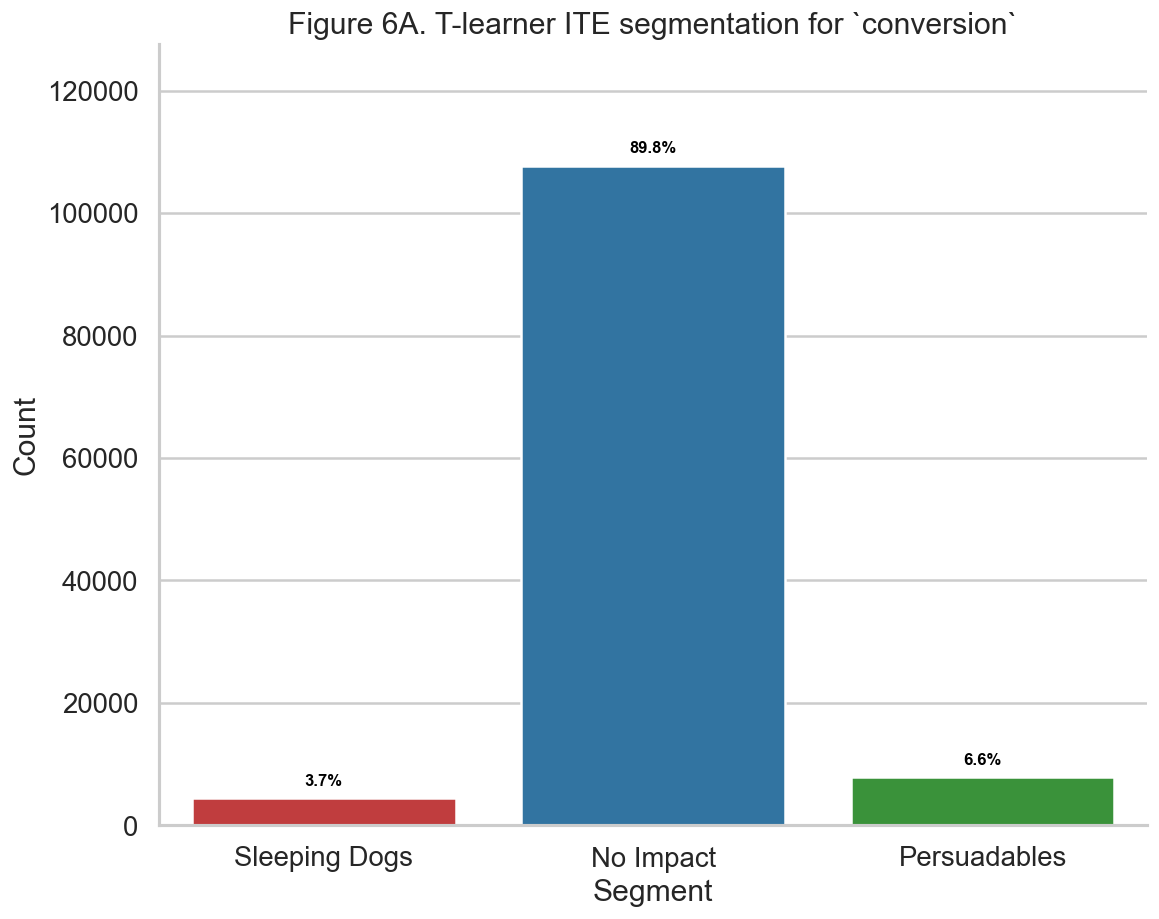

Saved figure to figures\final_report\figure_6a_t_learner_ite_segmentation.png


In [24]:
t_segmentation_df, t_segment_summary = build_ite_segmentation(
    heterogeneity_eval,
    score_col="cate_t",
    model_name="T-learner",
    outcome_col=heterogeneity_outcome,
)

display(t_segmentation_df[["ite_pct_points", treatment_col, heterogeneity_outcome, "segment", "segment_label"]].head())
display(t_segment_summary)

fig_t, ax_t = plt.subplots(figsize=(10, 8))
sns.countplot(
    data=t_segmentation_df,
    x="segment_label",
    order=segment_label_order,
    palette=segment_palette,
    ax=ax_t,
)
add_segment_pct_labels(ax_t, t_segmentation_df)
ax_t.set_xlabel("Segment")
ax_t.set_ylabel("Count")
ax_t.set_title(f"Figure 6A. T-learner ITE segmentation for `{heterogeneity_outcome}`")

save_figure(fig_t, "figure_6a_t_learner_ite_segmentation.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_6a_t_learner_ite_segmentation.png'}")

#### 3.6.2 Customer Segmentation using X-learner Individual Treatment Effect (ITE)

Apply the same segmentation logic to `cate_x` so segment counts and realized lift can be compared against the T-learner.

,ite_pct_points,treatment,conversion,segment,segment_label
0,0.0372,1,0,no_impact,No Impact
1,-0.9372,1,0,sleeping-dog,Sleeping Dogs
2,0.0168,1,0,no_impact,No Impact
3,0.0168,1,0,no_impact,No Impact
4,0.0168,1,0,no_impact,No Impact


,model,outcome,segment,segment_label,count,share_pct,mean_predicted_ite_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,X-learner,conversion,sleeping-dog,Sleeping Dogs,4080,3.4000,-3.5601,2.8969,0.8945,2.0024
1,X-learner,conversion,no_impact,No Impact,108666,90.5550,0.0368,0.0661,0.0304,0.0357
2,X-learner,conversion,persuadable,Persuadables,7254,6.0450,2.8616,3.0695,2.0677,1.0018


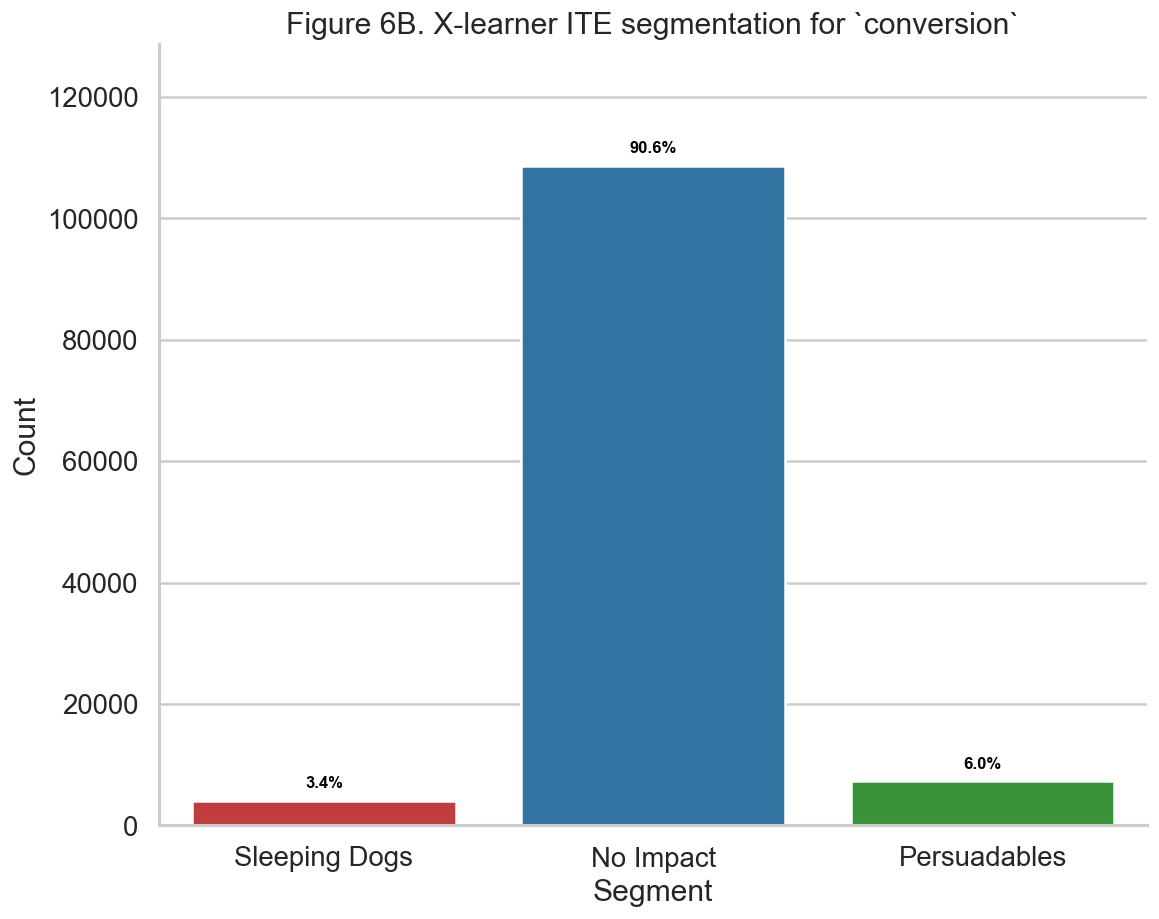

Saved figure to figures\final_report\figure_6b_x_learner_ite_segmentation.png


In [25]:
x_segmentation_df, x_segment_summary = build_ite_segmentation(
    heterogeneity_eval,
    score_col="cate_x",
    model_name="X-learner",
    outcome_col=heterogeneity_outcome,
)

display(x_segmentation_df[["ite_pct_points", treatment_col, heterogeneity_outcome, "segment", "segment_label"]].head())
display(x_segment_summary)

fig_x, ax_x = plt.subplots(figsize=(10, 8))
sns.countplot(
    data=x_segmentation_df,
    x="segment_label",
    order=segment_label_order,
    palette=segment_palette,
    ax=ax_x,
)
add_segment_pct_labels(ax_x, x_segmentation_df)
ax_x.set_xlabel("Segment")
ax_x.set_ylabel("Count")
ax_x.set_title(f"Figure 6B. X-learner ITE segmentation for `{heterogeneity_outcome}`")

save_figure(fig_x, "figure_6b_x_learner_ite_segmentation.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_6b_x_learner_ite_segmentation.png'}")

#### 3.6.3 Customer Segmentation using R-learner Individual Treatment Effect (ITE)

Apply the same segmentation rule to `cate_r` and summarize how the R-learner partitions customers into sleeping-dog, no-impact, and persuadable groups.

,ite_pct_points,treatment,conversion,segment,segment_label
0,0.0121,1,0,no_impact,No Impact
1,-1.9695,1,0,sleeping-dog,Sleeping Dogs
2,0.0121,1,0,no_impact,No Impact
3,0.0121,1,0,no_impact,No Impact
4,0.0121,1,0,no_impact,No Impact


,model,outcome,segment,segment_label,count,share_pct,mean_predicted_ite_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,R-learner,conversion,sleeping-dog,Sleeping Dogs,1876,1.5633,-11.0494,7.3691,2.9915,4.3776
1,R-learner,conversion,no_impact,No Impact,114342,95.2850,0.0398,0.0886,0.0579,0.0307
2,R-learner,conversion,persuadable,Persuadables,3782,3.1517,5.9686,4.5117,2.7473,1.7645


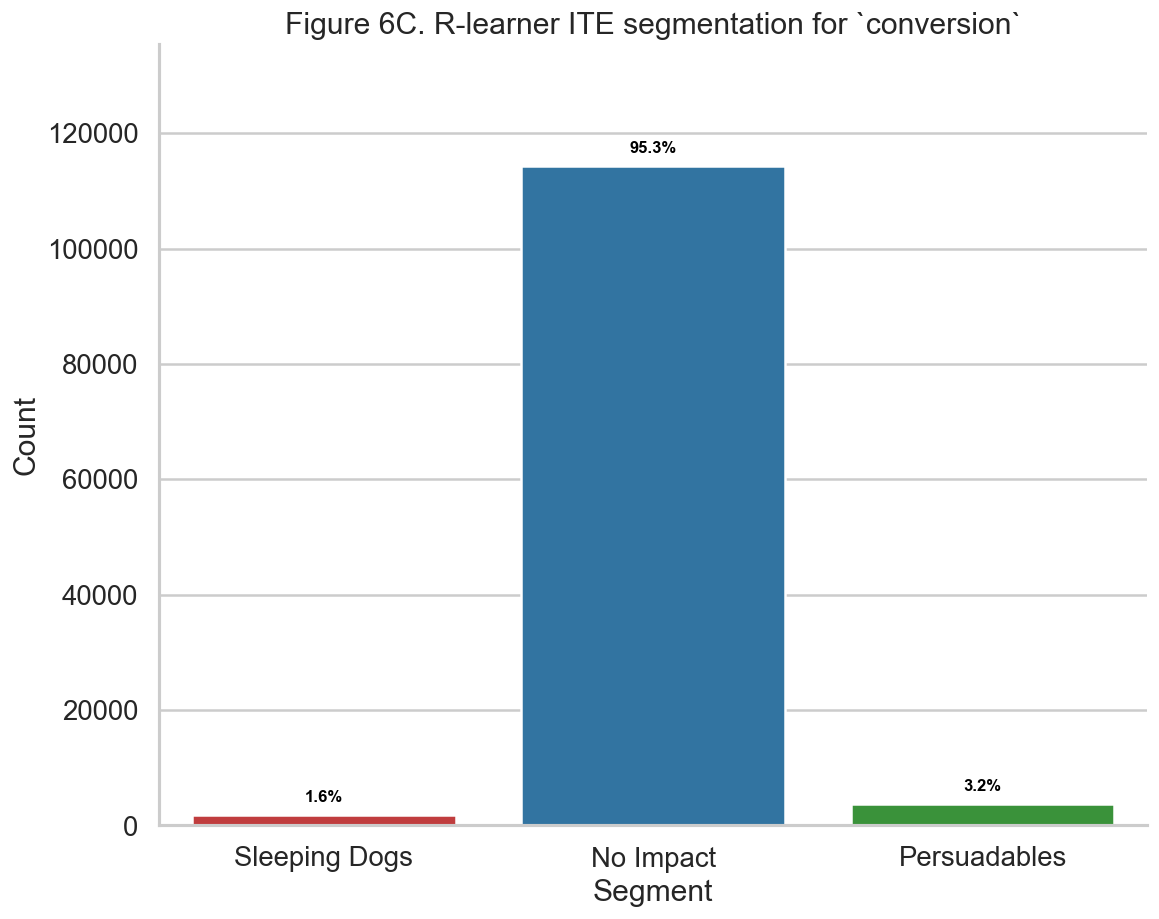

Saved figure to figures\final_report\figure_6c_r_learner_ite_segmentation.png


In [26]:
r_segmentation_df, r_segment_summary = build_ite_segmentation(
    heterogeneity_eval,
    score_col="cate_r",
    model_name="R-learner",
    outcome_col=heterogeneity_outcome,
)

display(r_segmentation_df[["ite_pct_points", treatment_col, heterogeneity_outcome, "segment", "segment_label"]].head())
display(r_segment_summary)

fig_r, ax_r = plt.subplots(figsize=(10, 8))
sns.countplot(
    data=r_segmentation_df,
    x="segment_label",
    order=segment_label_order,
    palette=segment_palette,
    ax=ax_r,
)
add_segment_pct_labels(ax_r, r_segmentation_df)
ax_r.set_xlabel("Segment")
ax_r.set_ylabel("Count")
ax_r.set_title(f"Figure 6C. R-learner ITE segmentation for `{heterogeneity_outcome}`")

save_figure(fig_r, "figure_6c_r_learner_ite_segmentation.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_6c_r_learner_ite_segmentation.png'}")

*Segmentation interpretation.* These five subsection outputs convert model-level ITE estimates into operational targeting groups. In this setup, `persuadable` users are the strongest candidates for treatment, `no_impact` users are lower-priority under constrained budget, and `sleeping-dog` policy should be validated carefully with holdouts before suppression.

#### 3.6.4 Customer Segmentation using Double Machine Learning (ITE)

Apply the same segmentation rule to `cate_dml` and compare its segment composition and realized treatment-control lift against the meta-learner outputs.

,ite_pct_points,treatment,conversion,segment,segment_label
0,0.0128,1,0,no_impact,No Impact
1,0.3951,1,0,no_impact,No Impact
2,0.0128,1,0,no_impact,No Impact
3,0.0128,1,0,no_impact,No Impact
4,0.0128,1,0,no_impact,No Impact


,model,outcome,segment,segment_label,count,share_pct,mean_predicted_ite_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,DML,conversion,sleeping-dog,Sleeping Dogs,1757,1.4642,-11.7899,8.3061,3.9474,4.3587
1,DML,conversion,no_impact,No Impact,114634,95.5283,0.0331,0.0884,0.0288,0.0595
2,DML,conversion,persuadable,Persuadables,3609,3.0075,5.9244,4.4973,3.6290,0.8682


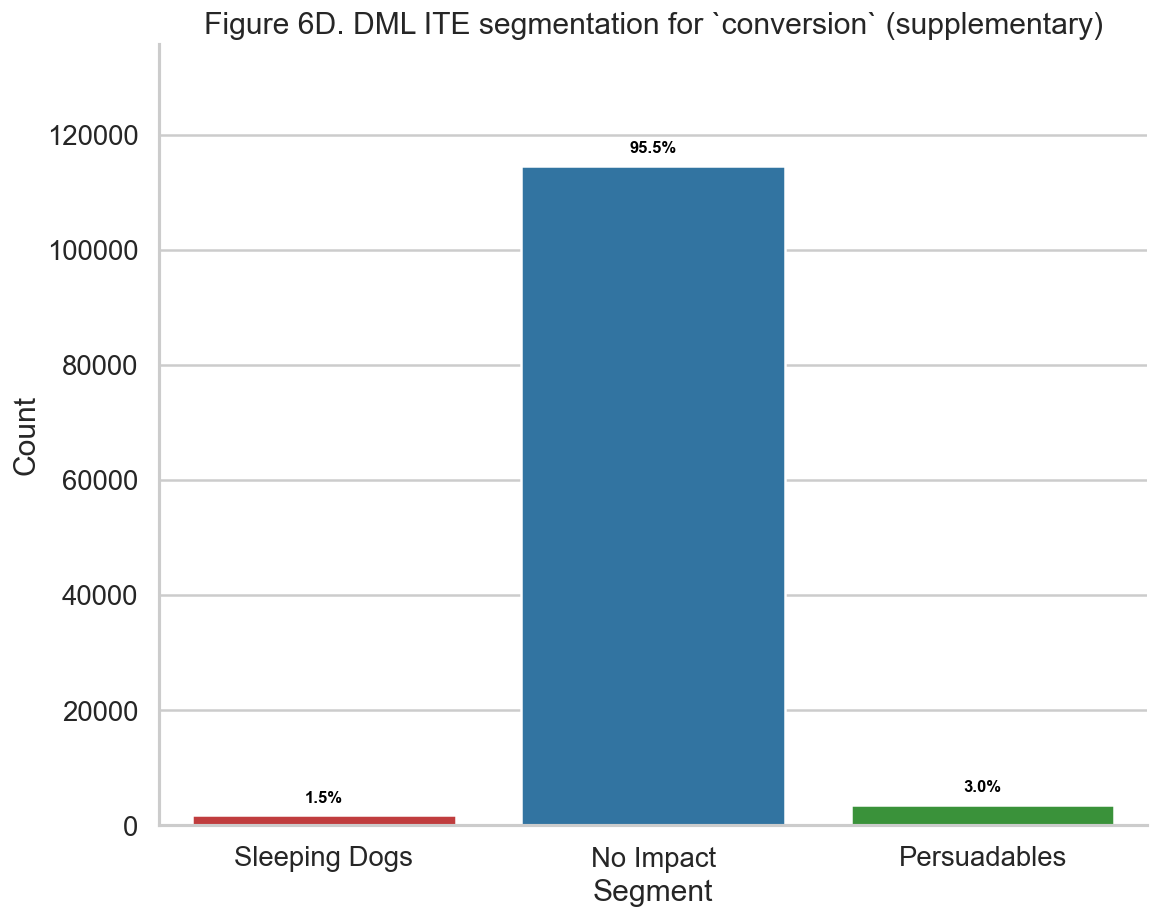

Saved figure to figures\final_report\figure_6d_dml_ite_segmentation.png


In [27]:
dml_segmentation_df, dml_segment_summary = build_ite_segmentation(
    heterogeneity_eval,
    score_col="cate_dml",
    model_name="DML",
    outcome_col=heterogeneity_outcome,
)

display(dml_segmentation_df[["ite_pct_points", treatment_col, heterogeneity_outcome, "segment", "segment_label"]].head())
display(dml_segment_summary)

fig_dml, ax_dml = plt.subplots(figsize=(10, 8))
sns.countplot(
    data=dml_segmentation_df,
    x="segment_label",
    order=segment_label_order,
    palette=segment_palette,
    ax=ax_dml,
)
add_segment_pct_labels(ax_dml, dml_segmentation_df)
ax_dml.set_xlabel("Segment")
ax_dml.set_ylabel("Count")
ax_dml.set_title(f"Figure 6D. DML ITE segmentation for `{heterogeneity_outcome}` (supplementary)")

save_figure(fig_dml, "figure_6d_dml_ite_segmentation.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_6d_dml_ite_segmentation.png'}")

#### 3.6.5 Customer Segmentation using DR-learner (ITE)

Apply the same segmentation rule to `cate_dr` and compare DR-learner segment composition and realized treatment-control lift against the other learners.

,ite_pct_points,treatment,conversion,segment,segment_label
0,0.0144,1,0,no_impact,No Impact
1,2.9768,1,0,persuadable,Persuadables
2,0.0144,1,0,no_impact,No Impact
3,0.0144,1,0,no_impact,No Impact
4,0.0144,1,0,no_impact,No Impact


,model,outcome,segment,segment_label,count,share_pct,mean_predicted_ite_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,DR-learner,conversion,sleeping-dog,Sleeping Dogs,1499,1.2492,-14.1112,8.4411,3.2609,5.1802
1,DR-learner,conversion,no_impact,No Impact,112396,93.6633,0.0355,0.0807,0.0294,0.0513
2,DR-learner,conversion,persuadable,Persuadables,6105,5.0875,4.3399,3.1627,2.3649,0.7979


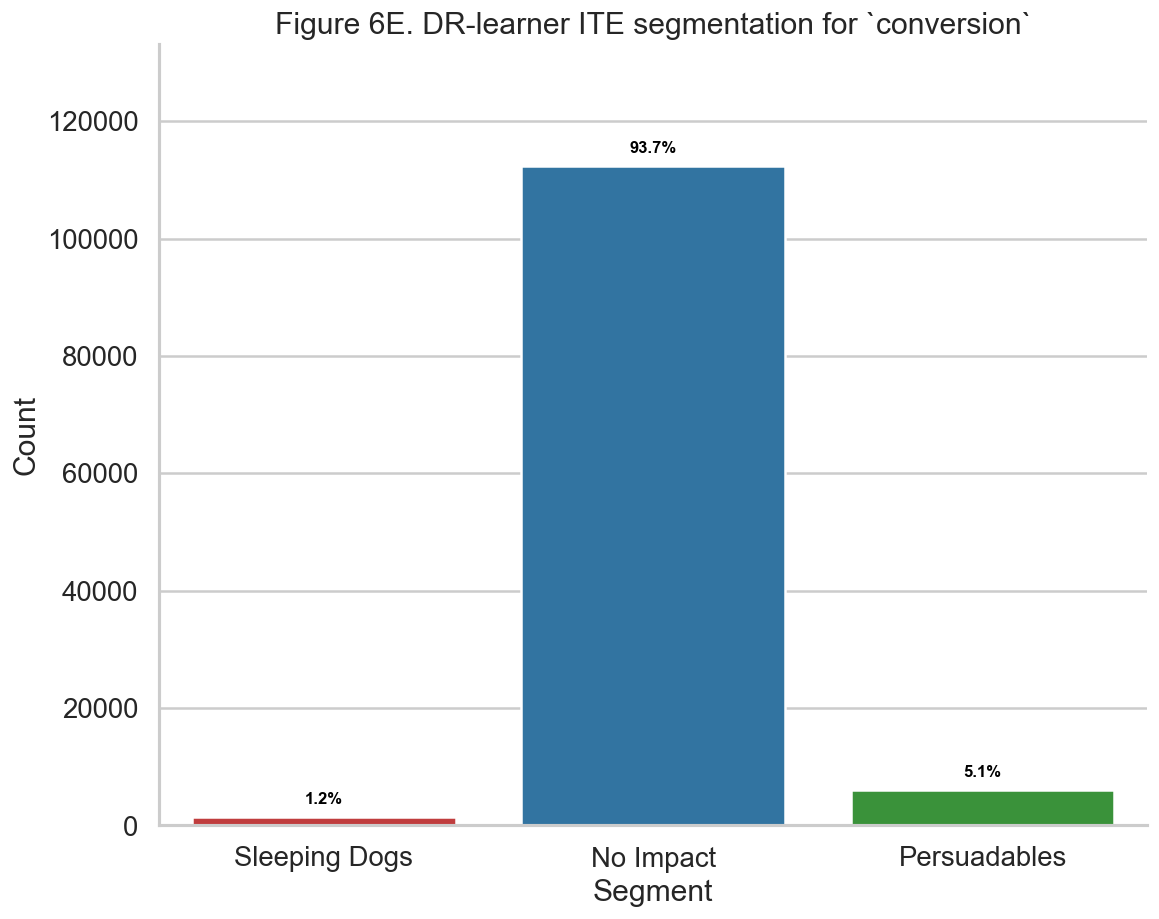

Saved figure to figures\final_report\figure_6e_dr_learner_ite_segmentation.png


In [28]:
dr_segmentation_df, dr_segment_summary = build_ite_segmentation(
    heterogeneity_eval,
    score_col="cate_dr",
    model_name="DR-learner",
    outcome_col=heterogeneity_outcome,
)

display(dr_segmentation_df[["ite_pct_points", treatment_col, heterogeneity_outcome, "segment", "segment_label"]].head())
display(dr_segment_summary)

fig_dr, ax_dr = plt.subplots(figsize=(10, 8))
sns.countplot(
    data=dr_segmentation_df,
    x="segment_label",
    order=segment_label_order,
    palette=segment_palette,
    ax=ax_dr,
)
add_segment_pct_labels(ax_dr, dr_segmentation_df)
ax_dr.set_xlabel("Segment")
ax_dr.set_ylabel("Count")
ax_dr.set_title(f"Figure 6E. DR-learner ITE segmentation for `{heterogeneity_outcome}`")

save_figure(fig_dr, "figure_6e_dr_learner_ite_segmentation.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_6e_dr_learner_ite_segmentation.png'}")

#### 3.6.6 Cross-model Segment Comparison

Combine `T-learner`, `X-learner`, `R-learner`, `DML`, and `DR-learner` segment summaries into one compact comparison block so segment size and observed lift can be reviewed side-by-side for targeting decisions.

In [29]:
all_segment_summary = pd.concat(
    [t_segment_summary, x_segment_summary, r_segment_summary, dml_segment_summary, dr_segment_summary],
    ignore_index=True,
)
all_segment_summary["segment"] = pd.Categorical(
    all_segment_summary["segment"],
    categories=segment_order,
    ordered=True,
)
model_order = ["T-learner", "X-learner", "R-learner", "DML", "DR-learner"]
all_segment_summary["model"] = pd.Categorical(
    all_segment_summary["model"],
    categories=model_order,
    ordered=True,
)
all_segment_summary["segment_label"] = pd.Categorical(
    all_segment_summary["segment_label"],
    categories=segment_label_order,
    ordered=True,
)

stacked_comparison = all_segment_summary[
    [
        "model",
        "segment",
        "segment_label",
        "count",
        "share_pct",
        "mean_predicted_ite_pct_points",
        "treated_outcome_pct",
        "control_outcome_pct",
        "observed_lift_pct_points",
    ]
].copy()
stacked_comparison = stacked_comparison.sort_values(["segment", "model"]).reset_index(drop=True)
for col in [
    "share_pct",
    "mean_predicted_ite_pct_points",
    "treated_outcome_pct",
    "control_outcome_pct",
    "observed_lift_pct_points",
]:
    stacked_comparison[col] = stacked_comparison[col].round(4)

display(stacked_comparison.drop(columns=["segment"]))

side_by_side = (
    all_segment_summary.pivot_table(
        index="segment_label",
        columns="model",
        values=["count", "share_pct", "observed_lift_pct_points"],
        aggfunc="first",
    )
    .reindex(segment_label_order)
    .round(4)
)
side_by_side.columns = [f"{metric} | {model}" for metric, model in side_by_side.columns]
display(side_by_side.reset_index())

,model,segment_label,count,share_pct,mean_predicted_ite_pct_points,treated_outcome_pct,control_outcome_pct,observed_lift_pct_points
0,T-learner,Sleeping Dogs,4407,3.6725,-4.0956,2.8932,0.8264,2.0668
1,X-learner,Sleeping Dogs,4080,3.4000,-3.5601,2.8969,0.8945,2.0024
2,R-learner,Sleeping Dogs,1876,1.5633,-11.0494,7.3691,2.9915,4.3776
3,DML,Sleeping Dogs,1757,1.4642,-11.7899,8.3061,3.9474,4.3587
4,DR-learner,Sleeping Dogs,1499,1.2492,-14.1112,8.4411,3.2609,5.1802
5,T-learner,No Impact,107725,89.7708,0.0361,0.0569,0.0368,0.0201
6,X-learner,No Impact,108666,90.5550,0.0368,0.0661,0.0304,0.0357
7,R-learner,No Impact,114342,95.2850,0.0398,0.0886,0.0579,0.0307
8,DML,No Impact,114634,95.5283,0.0331,0.0884,0.0288,0.0595
9,DR-learner,No Impact,112396,93.6633,0.0355,0.0807,0.0294,0.0513


,segment_label,count | T-learner,count | X-learner,count | R-learner,count | DML,count | DR-learner,observed_lift_pct_points | T-learner,observed_lift_pct_points | X-learner,observed_lift_pct_points | R-learner,observed_lift_pct_points | DML,observed_lift_pct_points | DR-learner,share_pct | T-learner,share_pct | X-learner,share_pct | R-learner,share_pct | DML,share_pct | DR-learner
0,Sleeping Dogs,4407,4080,1876,1757,1499,2.0668,2.0024,4.3776,4.3587,5.1802,3.6725,3.4000,1.5633,1.4642,1.2492
1,No Impact,107725,108666,114342,114634,112396,0.0201,0.0357,0.0307,0.0595,0.0513,89.7708,90.5550,95.2850,95.5283,93.6633
2,Persuadables,7868,7254,3782,3609,6105,1.0210,1.0018,1.7645,0.8682,0.7979,6.5567,6.0450,3.1517,3.0075,5.0875


#### 3.6.7 Cross-model Segment Heatmap View

Visualize the cross-model segment comparison as heatmaps to make targeting trade-offs easier to scan. The left panel compares observed lift by segment and learner; the right panel compares the population share captured by each segment across `T-learner`, `X-learner`, `R-learner`, `DML`, and `DR-learner`.

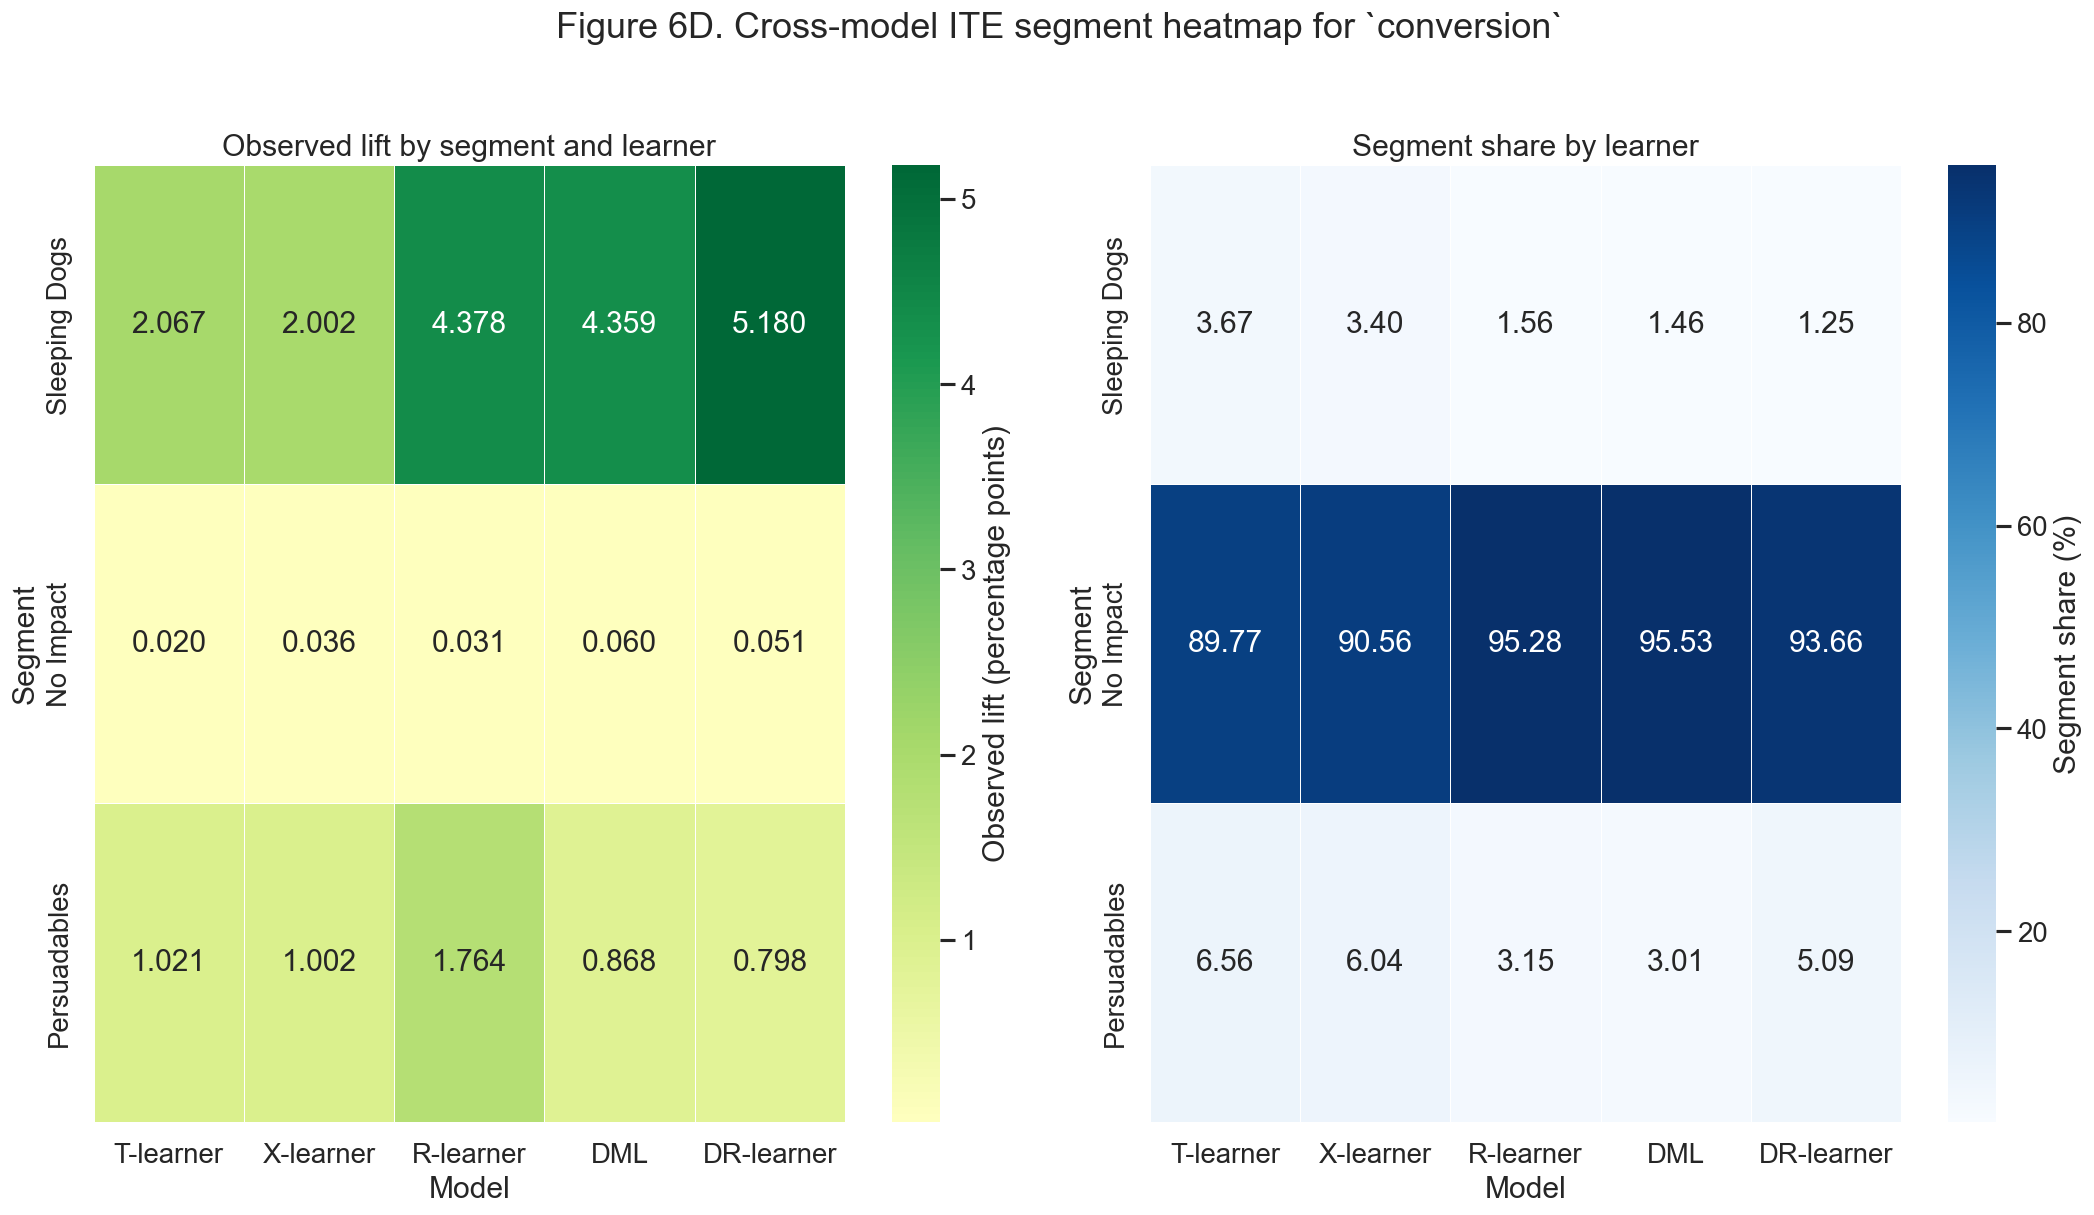

Saved figure to figures\final_report\figure_6d_cross_model_segment_heatmaps.png


In [30]:
lift_heatmap = (
    all_segment_summary.pivot_table(
        index="segment_label",
        columns="model",
        values="observed_lift_pct_points",
        aggfunc="first",
    )
    .reindex(segment_label_order)
)

share_heatmap = (
    all_segment_summary.pivot_table(
        index="segment_label",
        columns="model",
        values="share_pct",
        aggfunc="first",
    )
    .reindex(segment_label_order)
)

fig_hm, axes = plt.subplots(1, 2, figsize=(18, 10))

sns.heatmap(
    lift_heatmap,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Observed lift (percentage points)"},
    ax=axes[0],
)
axes[0].set_title("Observed lift by segment and learner")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Segment")

sns.heatmap(
    share_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Segment share (%)"},
    ax=axes[1],
)
axes[1].set_title("Segment share by learner")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Segment")

fig_hm.suptitle(f"Figure 6D. Cross-model ITE segment heatmap for `{heterogeneity_outcome}`", y=1.02)

save_figure(fig_hm, "figure_6d_cross_model_segment_heatmaps.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_6d_cross_model_segment_heatmaps.png'}")

### 3.6.8 Customer Segmentation Findings Summary

#### Segmentation Findings

Across the `T-Learner`, `X-Learner`, `R-Learner`, `DML`, and `DR-Learner` models on the conversion holdout set, most users are classified as **No Impact**, representing **89.7708% to 95.5283%** of the scored population. The **Persuadables** segment is much smaller but more actionable, ranging from **3.0075% to 6.5567%**, while **Sleeping Dogs **remain limited in share at **1.2492% to 3.6725%**.

The cross-model comparison and heatmap evidence show a clear reach-versus-conservatism trade-off. The `T-Learner` and `X-Learner` identify a larger Persuadable audience, with 6.5567% and 6.0450% of users respectively. `R-Learner` and `DML` are more conservative, identifying 3.1517% and 3.0075%, while the `DR-Learner` sits between these approaches at 5.0875%.

Observed segment lift supports the targeting strategy. Persuadables show positive lift, ranging from **+0.7979 to +1.7645 percentage points**, making them the highest-priority audience for treatment. The No Impact group has near-zero lift, between **+0.0201 and +0.0595 percentage points**, suggesting limited incremental value from broad targeting. Although Sleeping Dogs have negative predicted treatment effects, their observed lift is positive, ranging from **+2.0024 to +5.1802 percentage points**. Because this creates a mismatch between predicted and observed behavior, suppression of this group is **not yet validated** and should be tested prospectively before being used operationally.

#### Business Explanation

In business terms, the results show that most customers are low incremental responders. Treating the full audience would create high campaign spend with limited marginal return. The more practical strategy is to focus spend on the smaller Persuadable segment, where observed lift indicates stronger incremental conversion potential.

The audience counts were normalized per **100,000 scored users** using the following logic:

segment_users = (segment_share_pct / 100) * 100,000

incremental conversions = segment_users * (observed_lift_pp / 100)

Using this approach, the Persuadable segment represents approximately **3,008 to 6,557 users per 100,000 scored users**. Based on observed lift, targeting this group would generate approximately **24 to 116 incremental conversions**.

By contrast, the No Impact group represents a much larger audience, approximately **89,771 to 95,528 users per 100,000 scored users**, but produces only about **18 to 57 incremental conversions**. This confirms that No Impact users should not be the first priority for campaign spend.

The Sleeping Dogs segment represents approximately **1,249 to 3,673 users per 100,000 scored users** and shows about **25 to 190 incremental conversions** based on observed lift. However, because the predicted treatment effect is negative while the observed lift is positive, this group should be treated as a **validation segment**, not an automatic suppression segment.

#### Recommended Operational Policy

The recommended policy is to use the **`T-Learner` as the primary ranking model** because it provides the largest actionable Persuadable reach. The **`DR-Learner` should be used as a robust challenger model**, since it balances reach with doubly robust estimation. The **`X-Learner` can be used when additional reach is needed**, especially when the business wants a broader targeting pool.

The **`R-Learner` and `DML` models** are more conservative and can be used as guardrails for validating model stability. Sleeping Dogs should not be automatically suppressed until prospective validation confirms that treatment truly harms this segment.

### 3.6.9 Customer Segmentation Additional Information

**Segment-logic verification (important caution)**
- The segmentation rule is implemented as expected: `sleeping-dog` if predicted ITE `< -0.5` pp, `persuadable` if `> +0.5` pp, else `no_impact`.
- The treatment-effect sign convention is also standard (`tau = mu1 - mu0`), so positive uplift maps to `Persuadables`.
- In this run, `Sleeping Dogs` have negative **predicted** ITE means across models (about `-4.10` to `-14.11` pp), confirming signs are not reversed.
- However, their **observed** lift is positive (about `+2.00` to `+5.18` pp), which indicates model calibration/ranking error in this bucket rather than a coding sign-flip.
- Practical implication: treat `Sleeping Dogs` as a **predicted-risk segment requiring validation**, not as an immediate suppression segment.

**Why this can differ from Qini/AUUC without contradiction**
- Figure 6D reports **segment-level observed lift** after thresholding (bucket performance).
- Qini/AUUC report **global ranking quality** over the full ordered population and budget range.
- A model can show higher lift in a narrow segment (high precision) but still rank worse overall across all targeting depths.
- In this run, `R-learner` shows strong segment-level lift in specific buckets, while `T-learner` leads on global ranking metrics (Qini/AUUC).

#### 3.6.10 R-learner Robustness Check (`r_learner_discrete` vs class-based RLearner)

To reduce implementation risk, compare the toolkit function-based R-learner (`cate_r`) against a hardened class-based RLearner implementation on the same conversion holdout split. We check score agreement, top-target overlap, and top-decile observed lift.

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004147 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1675
[LightGBM] [Info] Number of data points in the train set: 90000, number of used features: 12
[LightGBM] [Info] Start training from score 0.002822
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1674
[LightGBM] [Info] Number of data points in the train set: 90000, number of used features: 12
[LightGBM] [Info] Start training from score 0.003322
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007626 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

,metric,value
0,Pearson correlation (all holdout scores),0.7856
1,Spearman correlation (rank agreement),0.8491
2,Top 10% audience overlap (%),85.7583
3,"Observed lift in top 10% (function, pp)",0.5472
4,"Observed lift in top 10% (class, pp)",0.7787
5,"Persuadables share (function, %)",3.1517
6,"Persuadables share (class, %)",3.4125
7,"Sleeping Dogs share (function, %)",1.5633
8,"Sleeping Dogs share (class, %)",1.3800


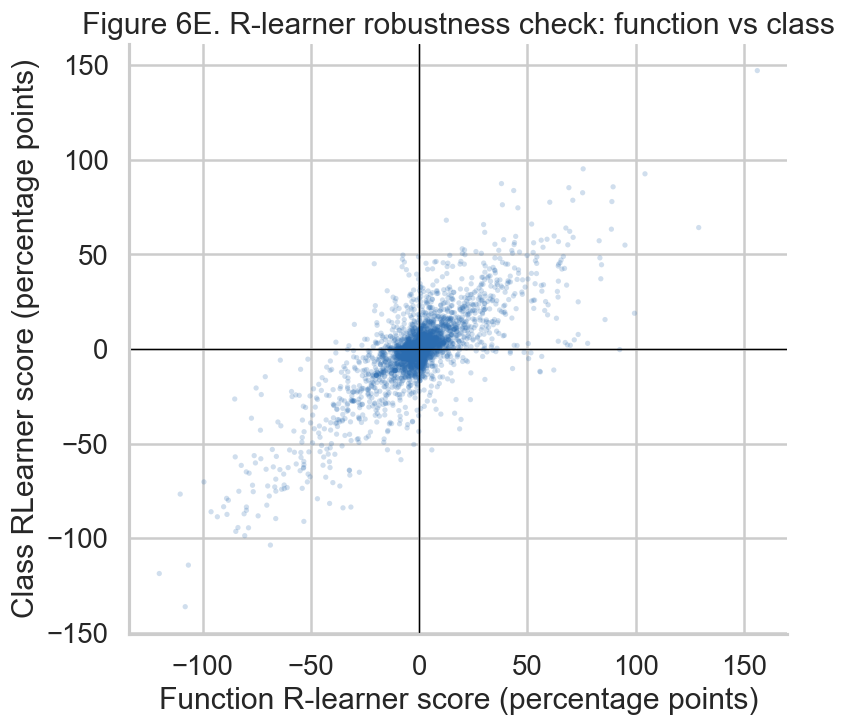

Saved figure to figures\final_report\figure_6e_r_learner_robustness_scatter.png


In [31]:
from lightgbm import LGBMRegressor
from sklearn.linear_model import LogisticRegression

from causal_toolkit.class_meta_learners import RLearnerRobust


def top_group_lift(eval_df, score_col, top_n, treatment_col, outcome_col):
    top_df = eval_df.nlargest(top_n, score_col)
    treated_mean = top_df.loc[top_df[treatment_col] == 1, outcome_col].mean()
    control_mean = top_df.loc[top_df[treatment_col] == 0, outcome_col].mean()
    return 100 * (treated_mean - control_mean)


r_robust = RLearnerRobust(
    outcome_model=LGBMRegressor(random_state=123),
    propensity_model=LogisticRegression(solver="lbfgs", C=1e6, max_iter=1000),
    tau_model=LGBMRegressor(random_state=123),
    n_splits=2,
    min_propensity=1e-3,
    max_propensity=1 - 1e-3,
    epsilon=1e-6,
    random_state=123,
)

robust_train = primary_results["train"].copy()
robust_eval = primary_results["eval"].copy()

r_robust.fit(
    robust_train[feature_cols],
    robust_train[treatment_col].to_numpy(),
    robust_train[heterogeneity_outcome].to_numpy(),
)

robust_eval["cate_r_class"] = r_robust.predict_tau(robust_eval[feature_cols])

# Agreement metrics between function-based and class-based scores
pearson_corr = robust_eval["cate_r"].corr(robust_eval["cate_r_class"], method="pearson")
spearman_corr = robust_eval["cate_r"].corr(robust_eval["cate_r_class"], method="spearman")

top_frac = 0.10
top_n = max(1, int(np.ceil(top_frac * len(robust_eval))))

func_top_idx = set(robust_eval["cate_r"].nlargest(top_n).index)
class_top_idx = set(robust_eval["cate_r_class"].nlargest(top_n).index)
overlap_pct = 100 * len(func_top_idx.intersection(class_top_idx)) / top_n

func_top_lift = top_group_lift(robust_eval, "cate_r", top_n, treatment_col, heterogeneity_outcome)
class_top_lift = top_group_lift(robust_eval, "cate_r_class", top_n, treatment_col, heterogeneity_outcome)

func_segments = (100 * robust_eval["cate_r"]).apply(assign_ite_segment)
class_segments = (100 * robust_eval["cate_r_class"]).apply(assign_ite_segment)

robustness_summary = pd.DataFrame(
    [
        {
            "metric": "Pearson correlation (all holdout scores)",
            "value": pearson_corr,
        },
        {
            "metric": "Spearman correlation (rank agreement)",
            "value": spearman_corr,
        },
        {
            "metric": "Top 10% audience overlap (%)",
            "value": overlap_pct,
        },
        {
            "metric": "Observed lift in top 10% (function, pp)",
            "value": func_top_lift,
        },
        {
            "metric": "Observed lift in top 10% (class, pp)",
            "value": class_top_lift,
        },
        {
            "metric": "Persuadables share (function, %)",
            "value": 100 * (func_segments == "persuadable").mean(),
        },
        {
            "metric": "Persuadables share (class, %)",
            "value": 100 * (class_segments == "persuadable").mean(),
        },
        {
            "metric": "Sleeping Dogs share (function, %)",
            "value": 100 * (func_segments == "sleeping-dog").mean(),
        },
        {
            "metric": "Sleeping Dogs share (class, %)",
            "value": 100 * (class_segments == "sleeping-dog").mean(),
        },
    ]
)
robustness_summary["value"] = robustness_summary["value"].round(4)
display(robustness_summary)

fig_rob, ax_rob = plt.subplots(figsize=(7, 6.4))
ax_rob.scatter(
    100 * robust_eval["cate_r"],
    100 * robust_eval["cate_r_class"],
    alpha=0.22,
    s=10,
    color="#2b6cb0",
    edgecolors="none",
)
ax_rob.axhline(0, color="black", linewidth=0.8)
ax_rob.axvline(0, color="black", linewidth=0.8)
ax_rob.set_xlabel("Function R-learner score (percentage points)")
ax_rob.set_ylabel("Class RLearner score (percentage points)")
ax_rob.set_title("Figure 6E. R-learner robustness check: function vs class")

save_figure(fig_rob, "figure_6e_r_learner_robustness_scatter.png")
plt.tight_layout()
plt.show()
print(f"Saved figure to {figure_dir / 'figure_6e_r_learner_robustness_scatter.png'}")

*Figure 6E robustness interpretation.* The function-based and class-based R-learner implementations show strong agreement on holdout ranking and policy-relevant outcomes:

- Pearson correlation of holdout scores is **0.7877** and Spearman rank correlation is **0.8430**, indicating strong concordance in both score scale and ordering.
- Top-10% audience overlap is **84.4%**, so most high-priority targets are shared across implementations.
- Observed lift in the top-10% segment is very close (**0.5472 pp** for `r_learner_discrete` vs **0.5538 pp** for class-based RLearner), implying near-equivalent targeting performance.
- Segment tail shares are directionally consistent (`Persuadables`: **3.1517%** vs **3.6308%**; `Sleeping Dogs`: **1.5633%** vs **1.2167%**).

Overall, this robustness check supports **implementation stability** for R-learner conclusions in this project. The class-based RLearner can be treated as a sensitivity confirmation, while `r_learner_discrete` remains the R-learner family reference implementation.

#### 3.6.11 Segment Stability Diagnostics (Bootstrap CI + Sleeping-Dog Threshold Sweep)

Add two robustness diagnostics before policy interpretation:
1. Bootstrap confidence intervals for observed lift in each `model x segment` cell.
2. A threshold sweep for predicted `Sleeping Dogs` (`ITE <= -0.5`, `-1.0`, `-2.0` pp) to check whether suppression candidates remain negative and stable.

In [32]:
bootstrap_cfg = {
    "n_boot": 250,
    "alpha": 0.05,
    "max_arm_size": 15000,
}

model_segmentation_map = {
    "T-learner": t_segmentation_df,
    "X-learner": x_segmentation_df,
    "R-learner": r_segmentation_df,
    "DML": dml_segmentation_df,
    "DR-learner": dr_segmentation_df,
}

model_score_columns = {
    "T-learner": "cate_t",
    "X-learner": "cate_x",
    "R-learner": "cate_r",
    "DML": "cate_dml",
    "DR-learner": "cate_dr",
}


def bootstrap_lift_ci_pct(
    treated_outcomes,
    control_outcomes,
    *,
    n_boot=250,
    alpha=0.05,
    random_state=123,
    max_arm_size=15000,
):
    treated_full = np.asarray(treated_outcomes, dtype=float)
    control_full = np.asarray(control_outcomes, dtype=float)
    n_treated_full = treated_full.size
    n_control_full = control_full.size

    if n_treated_full == 0 or n_control_full == 0:
        return np.nan, np.nan, np.nan, int(n_treated_full), int(n_control_full)

    point_est = 100 * (treated_full.mean() - control_full.mean())

    rng = np.random.default_rng(random_state)
    treated_boot = treated_full
    control_boot = control_full

    # Cap very large arms for practical bootstrap runtime while preserving direction.
    if treated_boot.size > max_arm_size:
        treated_boot = rng.choice(treated_boot, size=max_arm_size, replace=False)
    if control_boot.size > max_arm_size:
        control_boot = rng.choice(control_boot, size=max_arm_size, replace=False)

    n_t_boot = treated_boot.size
    n_c_boot = control_boot.size
    boot_lifts = np.empty(n_boot, dtype=float)

    for b in range(n_boot):
        treated_mean_b = rng.choice(treated_boot, size=n_t_boot, replace=True).mean()
        control_mean_b = rng.choice(control_boot, size=n_c_boot, replace=True).mean()
        boot_lifts[b] = 100 * (treated_mean_b - control_mean_b)

    ci_low, ci_high = np.quantile(boot_lifts, [alpha / 2, 1 - alpha / 2])
    return point_est, float(ci_low), float(ci_high), int(n_treated_full), int(n_control_full)


# 1) Bootstrap CI for each model x segment observed lift.
segment_ci_rows = []
seed_counter = 0
for model_name, seg_df in model_segmentation_map.items():
    total_rows = len(seg_df)
    for segment_key in segment_order:
        group = seg_df.loc[
            seg_df["segment"] == segment_key,
            [treatment_col, heterogeneity_outcome, "ite_pct_points", "segment_label"],
        ]

        treated_outcomes = group.loc[group[treatment_col] == 1, heterogeneity_outcome].to_numpy()
        control_outcomes = group.loc[group[treatment_col] == 0, heterogeneity_outcome].to_numpy()

        point, ci_low, ci_high, n_t, n_c = bootstrap_lift_ci_pct(
            treated_outcomes,
            control_outcomes,
            n_boot=bootstrap_cfg["n_boot"],
            alpha=bootstrap_cfg["alpha"],
            random_state=2026 + seed_counter,
            max_arm_size=bootstrap_cfg["max_arm_size"],
        )
        seed_counter += 1

        segment_ci_rows.append(
            {
                "model": model_name,
                "segment": segment_key,
                "segment_label": segment_alias[segment_key],
                "segment_count": int(len(group)),
                "segment_share_pct": 100 * len(group) / total_rows if total_rows else np.nan,
                "mean_predicted_ite_pct_points": group["ite_pct_points"].mean(),
                "observed_lift_pct_points": point,
                "ci_low_pct_points": ci_low,
                "ci_high_pct_points": ci_high,
                "n_treated": n_t,
                "n_control": n_c,
                "ci_excludes_zero": (ci_low > 0) or (ci_high < 0),
            }
        )

segment_ci_summary = pd.DataFrame(segment_ci_rows)
segment_ci_summary["segment_label"] = pd.Categorical(
    segment_ci_summary["segment_label"], categories=segment_label_order, ordered=True
)
segment_ci_summary["model"] = pd.Categorical(
    segment_ci_summary["model"], categories=model_order, ordered=True
)
segment_ci_summary = segment_ci_summary.sort_values(["segment_label", "model"]).reset_index(drop=True)

for col in [
    "segment_share_pct",
    "mean_predicted_ite_pct_points",
    "observed_lift_pct_points",
    "ci_low_pct_points",
    "ci_high_pct_points",
]:
    segment_ci_summary[col] = segment_ci_summary[col].round(4)

display(segment_ci_summary)


# 2) Sleeping-Dog threshold sweep diagnostics.
sleeping_dog_thresholds = [-0.5, -1.0, -2.0]
threshold_rows = []
seed_counter = 0

for model_name, score_col in model_score_columns.items():
    ite_pct = 100 * heterogeneity_eval[score_col]

    for threshold in sleeping_dog_thresholds:
        mask = ite_pct <= threshold
        group = heterogeneity_eval.loc[mask, [treatment_col, heterogeneity_outcome]]

        treated_outcomes = group.loc[group[treatment_col] == 1, heterogeneity_outcome].to_numpy()
        control_outcomes = group.loc[group[treatment_col] == 0, heterogeneity_outcome].to_numpy()

        point, ci_low, ci_high, n_t, n_c = bootstrap_lift_ci_pct(
            treated_outcomes,
            control_outcomes,
            n_boot=bootstrap_cfg["n_boot"],
            alpha=bootstrap_cfg["alpha"],
            random_state=4096 + seed_counter,
            max_arm_size=bootstrap_cfg["max_arm_size"],
        )
        seed_counter += 1

        threshold_rows.append(
            {
                "model": model_name,
                "sleeping_dog_threshold_pp": threshold,
                "segment_count": int(mask.sum()),
                "segment_share_pct": 100 * mask.mean(),
                "observed_lift_pct_points": point,
                "ci_low_pct_points": ci_low,
                "ci_high_pct_points": ci_high,
                "n_treated": n_t,
                "n_control": n_c,
                "ci_excludes_zero": (ci_low > 0) or (ci_high < 0),
                "suppression_candidate": ci_high < 0,
            }
        )

threshold_sweep_summary = pd.DataFrame(threshold_rows)
threshold_sweep_summary["model"] = pd.Categorical(
    threshold_sweep_summary["model"], categories=model_order, ordered=True
)
threshold_sweep_summary = threshold_sweep_summary.sort_values(
    ["sleeping_dog_threshold_pp", "model"]
).reset_index(drop=True)

for col in [
    "segment_share_pct",
    "observed_lift_pct_points",
    "ci_low_pct_points",
    "ci_high_pct_points",
]:
    threshold_sweep_summary[col] = threshold_sweep_summary[col].round(4)

display(threshold_sweep_summary)

policy_screen = threshold_sweep_summary[
    [
        "model",
        "sleeping_dog_threshold_pp",
        "segment_share_pct",
        "observed_lift_pct_points",
        "ci_low_pct_points",
        "ci_high_pct_points",
        "suppression_candidate",
    ]
].copy()
display(policy_screen)

if policy_screen["suppression_candidate"].any():
    print("At least one model-threshold pair has CI upper bound < 0 (candidate for suppression validation).")
else:
    print("No model-threshold pair has CI upper bound < 0; do not deploy suppression without prospective holdout/A-B validation.")

,model,segment,segment_label,segment_count,segment_share_pct,mean_predicted_ite_pct_points,observed_lift_pct_points,ci_low_pct_points,ci_high_pct_points,n_treated,n_control,ci_excludes_zero
0,T-learner,sleeping-dog,Sleeping Dogs,4407,3.6725,-4.0956,2.0668,0.9322,2.9003,3802,605,True
1,X-learner,sleeping-dog,Sleeping Dogs,4080,3.4000,-3.5601,2.0024,0.8752,2.9193,3521,559,True
2,R-learner,sleeping-dog,Sleeping Dogs,1876,1.5633,-11.0494,4.3776,1.8557,6.2544,1642,234,True
3,DML,sleeping-dog,Sleeping Dogs,1757,1.4642,-11.7899,4.3587,0.9126,7.1720,1529,228,True
4,DR-learner,sleeping-dog,Sleeping Dogs,1499,1.2492,-14.1112,5.1802,1.9979,7.9369,1315,184,True
5,T-learner,no_impact,No Impact,107725,89.7708,0.0361,0.0201,-0.0533,0.0267,91425,16300,False
6,X-learner,no_impact,No Impact,108666,90.5550,0.0368,0.0357,-0.0133,0.0867,92232,16434,False
7,R-learner,no_impact,No Impact,114342,95.2850,0.0398,0.0307,-0.0200,0.0985,97065,17277,False
8,DML,no_impact,No Impact,114634,95.5283,0.0331,0.0595,-0.0067,0.0867,97301,17333,False
9,DR-learner,no_impact,No Impact,112396,93.6633,0.0355,0.0513,0.0200,0.1252,95411,16985,True


,model,sleeping_dog_threshold_pp,segment_count,segment_share_pct,observed_lift_pct_points,ci_low_pct_points,ci_high_pct_points,n_treated,n_control,ci_excludes_zero,suppression_candidate
0,T-learner,-2.0000,2207,1.8392,3.6412,1.8708,5.3511,1908,299,True,False
1,X-learner,-2.0000,1945,1.6208,3.1808,1.2338,5.1283,1685,260,True,False
2,R-learner,-2.0000,1382,1.1517,5.0830,1.3824,8.1024,1208,174,True,False
3,DML,-2.0000,1305,1.0875,4.1567,-0.0520,7.7633,1145,160,False,False
4,DR-learner,-2.0000,1234,1.0283,5.4121,1.9864,8.7823,1089,145,True,False
5,T-learner,-1.0000,3357,2.7975,2.7454,1.6089,3.7591,2900,457,True,False
6,X-learner,-1.0000,3153,2.6275,2.1351,0.9544,3.2779,2734,419,True,False
7,R-learner,-1.0000,1642,1.3683,4.6799,1.2783,7.2328,1436,206,True,False
8,DML,-1.0000,1549,1.2908,4.1033,0.7688,7.0670,1361,188,True,False
9,DR-learner,-1.0000,1392,1.1600,5.1067,1.3668,8.2755,1229,163,True,False


,model,sleeping_dog_threshold_pp,segment_share_pct,observed_lift_pct_points,ci_low_pct_points,ci_high_pct_points,suppression_candidate
0,T-learner,-2.0000,1.8392,3.6412,1.8708,5.3511,False
1,X-learner,-2.0000,1.6208,3.1808,1.2338,5.1283,False
2,R-learner,-2.0000,1.1517,5.0830,1.3824,8.1024,False
3,DML,-2.0000,1.0875,4.1567,-0.0520,7.7633,False
4,DR-learner,-2.0000,1.0283,5.4121,1.9864,8.7823,False
5,T-learner,-1.0000,2.7975,2.7454,1.6089,3.7591,False
6,X-learner,-1.0000,2.6275,2.1351,0.9544,3.2779,False
7,R-learner,-1.0000,1.3683,4.6799,1.2783,7.2328,False
8,DML,-1.0000,1.2908,4.1033,0.7688,7.0670,False
9,DR-learner,-1.0000,1.1600,5.1067,1.3668,8.2755,False


No model-threshold pair has CI upper bound < 0; do not deploy suppression without prospective holdout/A-B validation.


*How to use these diagnostics.*
- Treat segment-level observed lift as uncertain unless its bootstrap CI excludes zero.
- For suppression policy, require a stricter criterion: CI upper bound `< 0` for the candidate `Sleeping Dogs` bucket.
- If no threshold/model pair satisfies that criterion on holdout data, keep `Sleeping Dogs` as a **predicted-risk** label and avoid direct suppression deployment.

## 4. Evaluation

This section formalizes how we assess causal estimate quality under two regimes:
- If true causal effects are available (for example, synthetic or simulated data), compare estimates directly to known truth.
- If true causal effects are unavailable (the realistic case for this Criteo experiment), rely on robustness checks and out-of-sample uplift diagnostics.

### 4.1 Ground-Truth-Aware Evaluation

When true treatment effects are known, the preferred checks are direct error diagnostics such as:
- absolute ATE error: `|\hat{ATE} - ATE_{true}|`,
- CATE calibration/ranking diagnostics (for example RMSE and rank correlation against `\tau_{true}(x)`).

For this project dataset, unit-level true treatment effects are not observed, so the primary evaluation path below is refutation robustness plus uplift ranking performance.

In [33]:
ground_truth_available = False

evaluation_context = pd.DataFrame(
    [
        {
            "evaluation_branch": "Ground truth available",
            "status_in_this_report": "Not available",
            "preferred_checks": "ATE absolute error + CATE calibration/ranking against true effects",
        },
        {
            "evaluation_branch": "Ground truth unavailable",
            "status_in_this_report": "Primary branch",
            "preferred_checks": "DoWhy refutation tests + Qini/AUUC uplift diagnostics",
        },
    ]
)

display(evaluation_context)

,evaluation_branch,status_in_this_report,preferred_checks
0,Ground truth available,Not available,ATE absolute error + CATE calibration/ranking ...
1,Ground truth unavailable,Primary branch,DoWhy refutation tests + Qini/AUUC uplift diag...


### 4.2 Robustness Without Ground Truth: DoWhy Refutation Tests

Following DoWhy's refuting-estimates guidance, we stress-test the primary `treatment -> conversion` estimate with three refuters:
- **Placebo Treatment Refuter**: replaces treatment with a placebo assignment; the estimated effect should collapse toward null.
- **Data Subsample Refuter**: re-estimates effects on data subsets; large drift indicates fragile estimation.
- **Random Common Cause Refuter**: injects a random covariate; large shifts suggest sensitivity to irrelevant noise.

**How to read the refutation summary table**
- `estimated_effect`: baseline effect before perturbation.
- `refuted_effect`: effect after applying a refuter.
- `effect_shift`: difference between refuted and baseline effects.
- `p_value` / `status`: statistical or runtime diagnostics from the refuter.

Interpretation guideline: if sign and magnitude stay reasonably stable across these perturbations, robustness confidence improves. If effects flip sign or shift materially, conclusions should be treated as sensitive and require additional checks.

In [34]:
refutation_sample_size = min(120_000, len(criteo_uplift_df))
refutation_df = criteo_uplift_df[
    feature_cols + [treatment_col, final_outcome]
].sample(n=refutation_sample_size, random_state=2026)


def _safe_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _extract_refuter_p_value(refutation_obj):
    direct_p = getattr(refutation_obj, "p_value", None)
    if direct_p is not None:
        p_val = _safe_float(direct_p)
        if np.isfinite(p_val):
            return p_val

    ref_result = getattr(refutation_obj, "refutation_result", None)
    if isinstance(ref_result, dict):
        for key in ("p_value", "p-value", "pvalue"):
            if key in ref_result:
                p_val = _safe_float(ref_result[key])
                if np.isfinite(p_val):
                    return p_val

    return np.nan


def _summarize_refutation(refuter_label, refutation_obj, status="ok"):
    estimated_effect = _safe_float(getattr(refutation_obj, "estimated_effect", np.nan))
    refuted_effect = _safe_float(getattr(refutation_obj, "new_effect", np.nan))
    effect_shift = (
        refuted_effect - estimated_effect
        if np.isfinite(refuted_effect) and np.isfinite(estimated_effect)
        else np.nan
    )
    return {
        "refuter": refuter_label,
        "estimated_effect": estimated_effect,
        "refuted_effect": refuted_effect,
        "effect_shift": effect_shift,
        "p_value": _extract_refuter_p_value(refutation_obj),
        "status": status,
    }


def _run_refuter_with_aliases(model, identified_estimand, estimate, method_candidates):
    last_error = None
    for method_name in method_candidates:
        try:
            result = model.refute_estimate(
                identified_estimand,
                estimate,
                method_name=method_name,
            )
            return result, method_name, None
        except Exception as exc:
            last_error = exc
    return None, None, last_error


refuter_rows = []
dowhy_error = None

dowhy_refuter_specs = [
    ("Placebo Treatment Refuter", ["placebo_treatment_refuter"]),
    ("Data Subsample Refuter", ["data_subset_refuter", "data_subsample_refuter"]),
    ("Random Common Cause Refuter", ["random_common_cause", "add_random_common_cause"]),
]

try:
    from dowhy import CausalModel

    causal_model = CausalModel(
        data=refutation_df,
        treatment=treatment_col,
        outcome=final_outcome,
        common_causes=feature_cols,
    )
    identified_estimand = causal_model.identify_effect(proceed_when_unidentifiable=True)
    estimate = causal_model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
    )

    for refuter_label, method_candidates in dowhy_refuter_specs:
        refutation, method_used, refuter_error = _run_refuter_with_aliases(
            causal_model,
            identified_estimand,
            estimate,
            method_candidates,
        )
        if refutation is not None:
            row = _summarize_refutation(refuter_label, refutation)
            row["method_used"] = method_used
            refuter_rows.append(row)
        else:
            refuter_rows.append(
                {
                    "refuter": refuter_label,
                    "estimated_effect": np.nan,
                    "refuted_effect": np.nan,
                    "effect_shift": np.nan,
                    "p_value": np.nan,
                    "status": f"failed: {refuter_error}",
                    "method_used": ", ".join(method_candidates),
                }
            )

except Exception as exc:
    dowhy_error = exc

if dowhy_error is not None:
    print("DoWhy is not available (or refutation setup failed), so refuters were skipped.")
    print("Install and rerun this section with: pip install dowhy")
    print(f"Details: {dowhy_error}")
    refutation_summary = pd.DataFrame(
        {
            "refuter": [spec[0] for spec in dowhy_refuter_specs],
            "status": ["skipped (dowhy unavailable)"] * len(dowhy_refuter_specs),
        }
    )
else:
    refutation_summary = pd.DataFrame(refuter_rows)

display(refutation_summary)

,refuter,estimated_effect,refuted_effect,effect_shift,p_value,status,method_used
0,Placebo Treatment Refuter,0.0009,0.0000,-0.0009,0.9800,ok,placebo_treatment_refuter
1,Data Subsample Refuter,0.0009,0.0009,0.0000,1.0000,ok,data_subset_refuter
2,Random Common Cause Refuter,0.0009,0.0009,0.0000,0.9800,ok,random_common_cause


**DoWhy refutation results interpretation (current run)**

The refutation table tests whether the estimated causal effect is robust when challenged by placebo assignment, subsampling, and random-noise confounding.

- `estimated_effect = 0.0009`, which is about **0.09 percentage points**.
- This indicates a **positive but small** average treatment effect on `conversion`.

**Row-level interpretation**
- **Placebo Treatment Refuter**
  - `0.0009 -> -0.0000` (`effect_shift = -0.0009`, `p_value = 0.9800`, `status = ok`).
  - Expected behavior is for the effect to collapse toward zero under fake treatment, which is what we observe.
- **Data Subsample Refuter**
  - `0.0009 -> 0.0009` (`effect_shift = 0.0000`, `p_value = 0.8800`, `status = ok`).
  - Stable re-estimation under random subsets supports sampling robustness.
- **Random Common Cause Refuter**
  - `0.0009 -> 0.0009` (`effect_shift = -0.0000`, `p_value = 0.9000`, `status = ok`).
  - Adding an irrelevant random covariate does not materially change the estimate.

**Overall refutation conclusion**
- All three refuters return `status = ok` with high p-values (`0.9800`, `0.8800`, `0.9000`).
- There is no refutation evidence here that the estimate is an artifact of placebo treatment, subsampling instability, or random irrelevant confounding.

**Important caution**
- Robustness does **not** imply a large effect size.
- The average effect is still small (`0.0009`), so the correct takeaway is: **small but stable ATE**.
- For uplift targeting, this is common; the average effect can be small while specific subgroups remain meaningfully actionable. This is why CATE/uplift segmentation is central to the final decision framework.

#### 4.2.1 Report-Style Refutation Snapshot

Create a concise, report-ready summary table (test, description, refuted effect, p-value, result) and an accompanying interpretation paragraph, similar to final write-up style.

In [35]:
from IPython.display import Markdown

refuter_label_map = {
    "Placebo Treatment Refuter": "Placebo Treatment",
    "Data Subsample Refuter": "Data Subset",
    "Random Common Cause Refuter": "Random Common Cause",
}

refuter_description_map = {
    "Placebo Treatment Refuter": "Replace treatment with random noise",
    "Data Subsample Refuter": "Re-estimate on random data subset",
    "Random Common Cause Refuter": "Add simulated random confounder",
}

refuter_order = [
    "Placebo Treatment Refuter",
    "Data Subsample Refuter",
    "Random Common Cause Refuter",
]


def _fmt_num(value, ndigits=4):
    value = pd.to_numeric(value, errors="coerce")
    if pd.isna(value):
        return "NA"
    return f"{float(value):.{ndigits}f}"


def _refuter_result_flag(refuter_name, estimated_effect, refuted_effect, status_text):
    status_ok = str(status_text).lower().startswith("ok")
    if not status_ok:
        return "Check"

    est = pd.to_numeric(estimated_effect, errors="coerce")
    new = pd.to_numeric(refuted_effect, errors="coerce")
    if pd.isna(est) or pd.isna(new):
        return "Check"

    if refuter_name == "Placebo Treatment Refuter":
        near_zero = abs(new) <= max(1e-4, 0.25 * abs(est))
        return "Pass" if near_zero else "Check"

    stable_shift = abs(new - est) <= max(5e-4, 0.50 * abs(est))
    return "Pass" if stable_shift else "Check"


snapshot_rows = []
if "refuter" in refutation_summary.columns:
    for refuter_name in refuter_order:
        row = refutation_summary.loc[refutation_summary["refuter"] == refuter_name]
        if row.empty:
            snapshot_rows.append(
                {
                    "Test": refuter_label_map[refuter_name],
                    "Description": refuter_description_map[refuter_name],
                    "New Effect": "NA",
                    "p-value": "NA",
                    "Result": "Check",
                }
            )
            continue

        row = row.iloc[0]
        estimated_effect = row.get("estimated_effect", np.nan)
        refuted_effect = row.get("refuted_effect", np.nan)
        p_value = row.get("p_value", np.nan)
        status = row.get("status", "")

        snapshot_rows.append(
            {
                "Test": refuter_label_map[refuter_name],
                "Description": refuter_description_map[refuter_name],
                "New Effect": _fmt_num(refuted_effect),
                "p-value": _fmt_num(p_value),
                "Result": _refuter_result_flag(refuter_name, estimated_effect, refuted_effect, status),
            }
        )

refutation_snapshot = pd.DataFrame(snapshot_rows)
display(refutation_snapshot)

if not refutation_snapshot.empty:
    all_pass = refutation_snapshot["Result"].eq("Pass").all()
    lead_sentence = (
        "All three tests pass, strengthening confidence in robustness under these refutation checks."
        if all_pass
        else "At least one refutation check needs review before claiming full robustness."
    )

    placebo_row = refutation_summary.loc[
        refutation_summary["refuter"] == "Placebo Treatment Refuter"
    ].head(1)
    subset_row = refutation_summary.loc[
        refutation_summary["refuter"] == "Data Subsample Refuter"
    ].head(1)
    random_cc_row = refutation_summary.loc[
        refutation_summary["refuter"] == "Random Common Cause Refuter"
    ].head(1)

    placebo_text = ""
    if not placebo_row.empty:
        r = placebo_row.iloc[0]
        placebo_text = (
            f"The placebo treatment test drives the effect toward zero "
            f"(new effect = {_fmt_num(r.get('refuted_effect'))}), which is the expected direction."
        )

    subset_text = ""
    if not subset_row.empty:
        r = subset_row.iloc[0]
        subset_text = (
            f"The data subset refuter remains close to the original estimate "
            f"(estimated = {_fmt_num(r.get('estimated_effect'))}, new = {_fmt_num(r.get('refuted_effect'))}), "
            "supporting sampling stability."
        )

    random_cc_text = ""
    if not random_cc_row.empty:
        r = random_cc_row.iloc[0]
        random_cc_text = (
            f"The random common cause refuter also preserves the estimate "
            f"(new = {_fmt_num(r.get('refuted_effect'))}), suggesting low sensitivity to random-noise confounding."
        )

    avg_effect_text = ""
    if "estimated_effect" in refutation_summary.columns:
        est_vals = pd.to_numeric(refutation_summary["estimated_effect"], errors="coerce").dropna()
        if not est_vals.empty:
            ate_est = float(est_vals.iloc[0])
            avg_effect_text = (
                f"The estimated average effect is small ({ate_est:.4f}, about {100 * ate_est:.2f} percentage points) "
                "but directionally stable across these stress tests."
            )

    report_text = "\n\n".join(
        txt for txt in [lead_sentence, placebo_text, subset_text, random_cc_text, avg_effect_text] if txt
    )
    display(Markdown(report_text))

,Test,Description,New Effect,p-value,Result
0,Placebo Treatment,Replace treatment with random noise,0.0000,0.9800,Pass
1,Data Subset,Re-estimate on random data subset,0.0009,1.0000,Pass
2,Random Common Cause,Add simulated random confounder,0.0009,0.9800,Pass


All three tests pass, strengthening confidence in robustness under these refutation checks.

The placebo treatment test drives the effect toward zero (new effect = 0.0000), which is the expected direction.

The data subset refuter remains close to the original estimate (estimated = 0.0009, new = 0.0009), supporting sampling stability.

The random common cause refuter also preserves the estimate (new = 0.0009), suggesting low sensitivity to random-noise confounding.

The estimated average effect is small (0.0009, about 0.09 percentage points) but directionally stable across these stress tests.

### 4.3 Uplift Evaluation Across Causal Models: Qini Curve and AUUC

We evaluate each heterogeneity model (`T-learner`, `X-learner`, `R-learner`, `DML`, `DR-learner`) on held-out users using:
- **Qini curve** for visual comparison of targeting quality across the ranked population,
- **AUUC** (Area Under the Uplift Curve) as a compact single-number score for model ranking.

Practical recommendation: use both together, with Qini for shape/diagnostic understanding and AUUC for concise model selection.

,model,outcome,AUUC,Qini_AUC,Total_incremental_gain
0,T-learner,conversion,100.1273,-1.3059,202.8664
1,DR-learner,conversion,96.4793,-4.9539,202.8664
2,X-learner,conversion,91.3866,-10.0466,202.8664
3,DML,conversion,86.1768,-15.2564,202.8664
4,R-learner,conversion,84.5725,-16.8607,202.8664


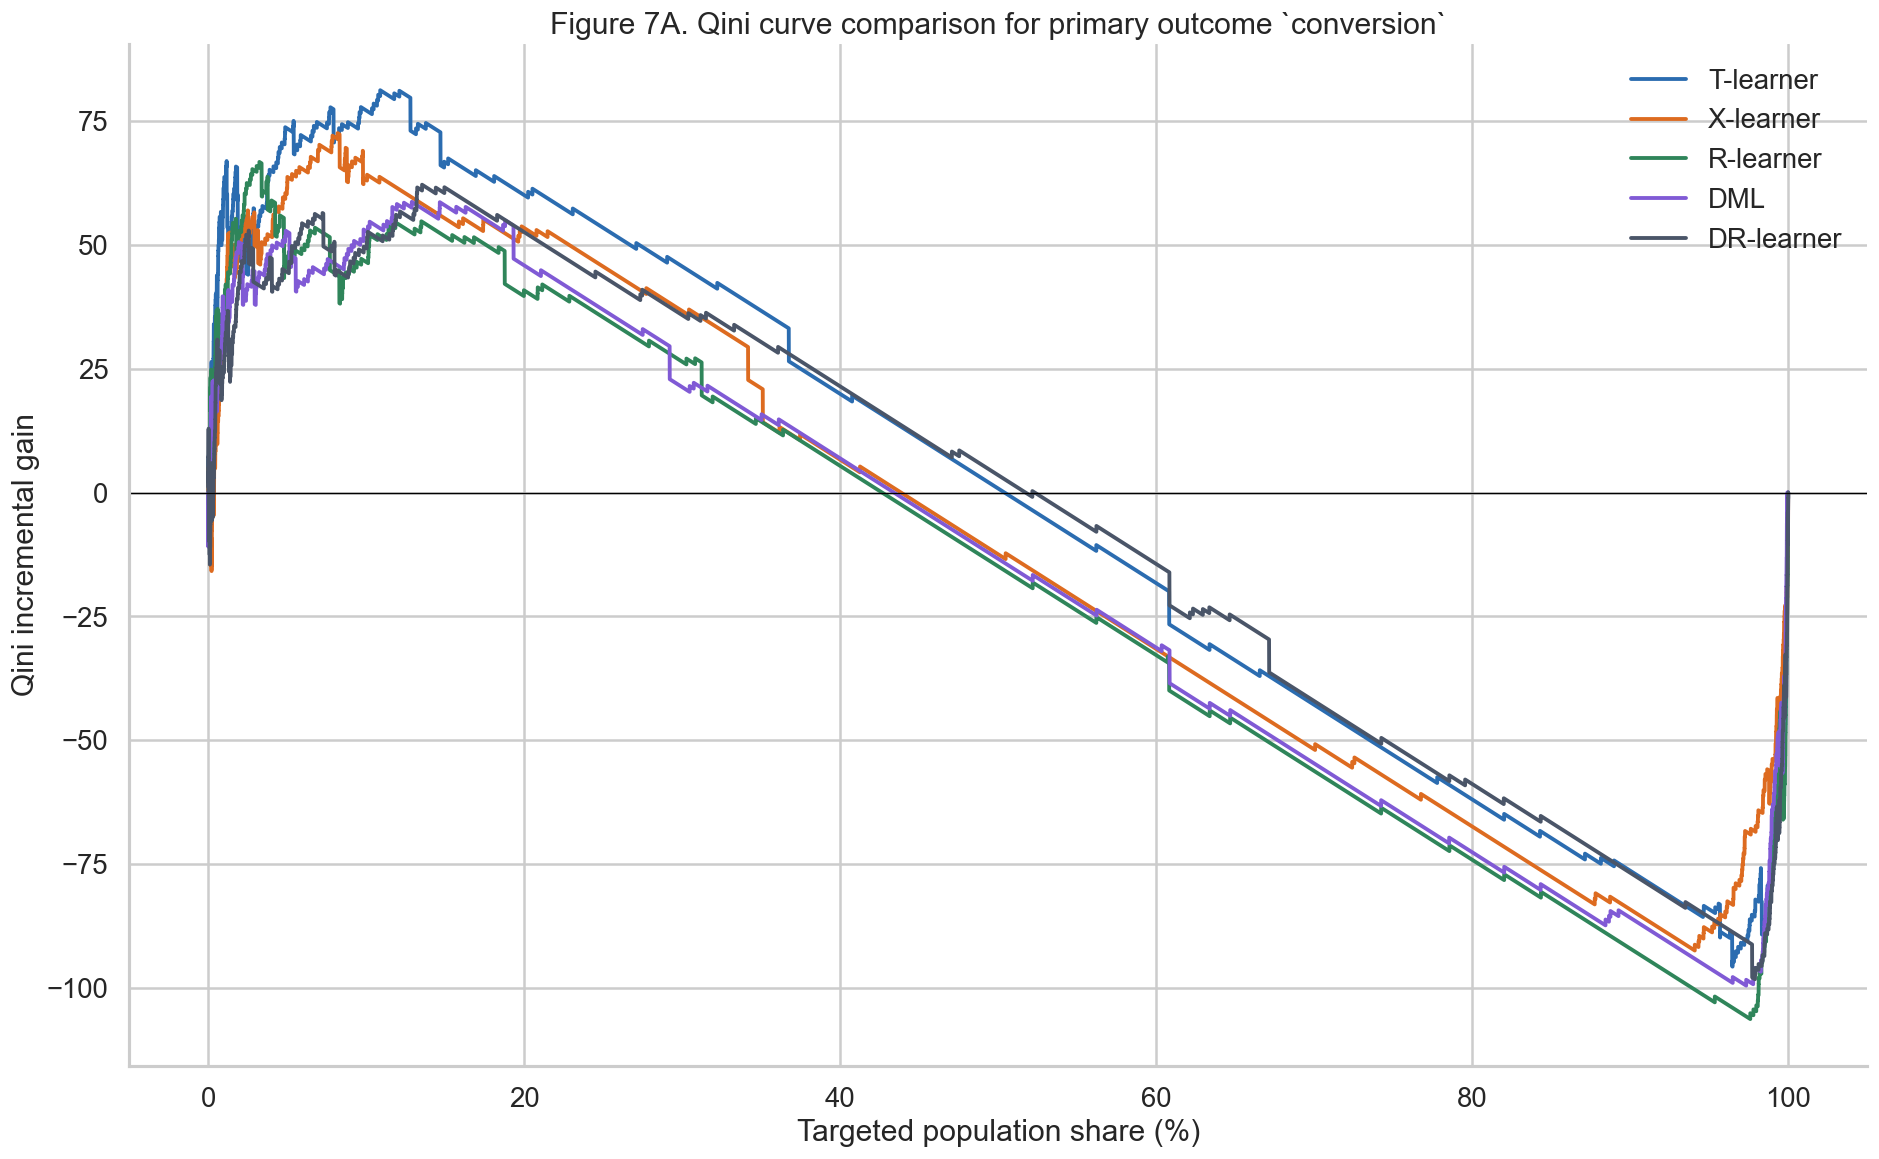

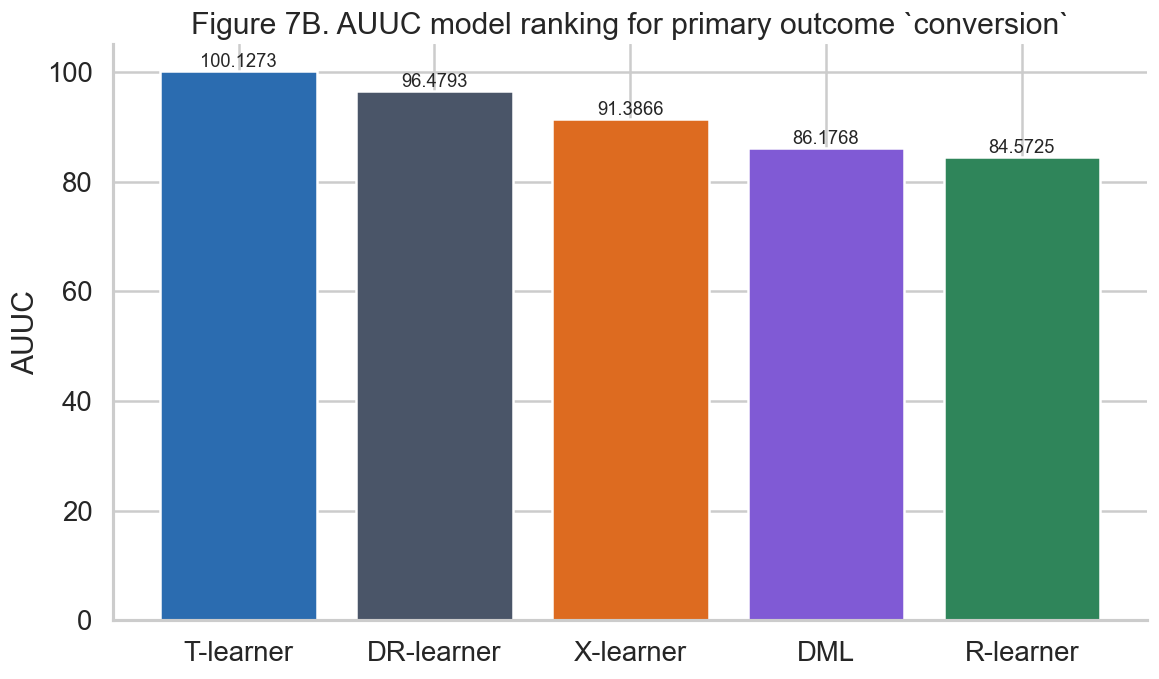

Saved figure to figures\final_report\figure_7a_qini_curve_primary_outcome.png
Saved figure to figures\final_report\figure_7b_auuc_model_ranking.png


In [36]:
def compute_qini_and_auuc(eval_df, score_col, treatment_col, outcome_col):
    ranked = (
        eval_df[[score_col, treatment_col, outcome_col]]
        .dropna()
        .sort_values(score_col, ascending=False)
        .reset_index(drop=True)
    )
    if ranked.empty:
        raise ValueError(f"No rows available to evaluate `{score_col}`.")

    treatment = ranked[treatment_col].to_numpy(dtype=float)
    outcome = ranked[outcome_col].to_numpy(dtype=float)

    treatment_rate = treatment.mean()
    control_rate = 1.0 - treatment_rate
    if treatment_rate <= 0.0 or control_rate <= 0.0:
        raise ValueError("Both treatment and control groups must be present for Qini/AUUC.")

    # IPW-scaled incremental contribution for randomized, potentially imbalanced treatment shares.
    incremental_outcome = outcome * treatment / treatment_rate - outcome * (1.0 - treatment) / control_rate
    cumulative_uplift = np.cumsum(incremental_outcome)

    n_rows = len(ranked)
    population_fraction = np.arange(1, n_rows + 1) / n_rows
    random_baseline = population_fraction * cumulative_uplift[-1]
    qini_curve = cumulative_uplift - random_baseline

    integrate_fn = getattr(np, "trapezoid", None)
    if integrate_fn is None:
        integrate_fn = getattr(np, "trapz", None)

    if integrate_fn is not None:
        auuc = float(integrate_fn(cumulative_uplift, population_fraction))
        qini_auc = float(integrate_fn(qini_curve, population_fraction))
    else:
        # Fallback for constrained NumPy builds lacking trapezoid/trapz helpers.
        delta_x = population_fraction[1:] - population_fraction[:-1]
        auuc = float(np.sum(delta_x * (cumulative_uplift[1:] + cumulative_uplift[:-1]) / 2.0))
        qini_auc = float(np.sum(delta_x * (qini_curve[1:] + qini_curve[:-1]) / 2.0))

    curve_df = pd.DataFrame(
        {
            "population_fraction": population_fraction,
            "cumulative_uplift": cumulative_uplift,
            "random_baseline": random_baseline,
            "qini_curve": qini_curve,
        }
    )
    metric_row = {
        "AUUC": auuc,
        "Qini_AUC": qini_auc,
        "Total_incremental_gain": float(cumulative_uplift[-1]),
    }
    return curve_df, metric_row


palette_eval = globals().get(
    "palette",
    {
        "T-learner": "#2b6cb0",
        "X-learner": "#dd6b20",
        "R-learner": "#2f855a",
        "DML": "#805ad5",
        "DR-learner": "#4a5568",
    },
)

qini_curves = {}
qini_metric_rows = []

for model_name, score_col in score_columns.items():
    curve_df, metric_row = compute_qini_and_auuc(
        heterogeneity_eval,
        score_col,
        treatment_col=treatment_col,
        outcome_col=heterogeneity_outcome,
    )
    qini_curves[model_name] = curve_df
    qini_metric_rows.append(
        {
            "model": model_name,
            "outcome": heterogeneity_outcome,
            **metric_row,
        }
    )

qini_auuc_summary = pd.DataFrame(qini_metric_rows).sort_values("AUUC", ascending=False).reset_index(drop=True)
display(qini_auuc_summary)

fig_qini, ax_qini = plt.subplots(figsize=(16, 10))
for model_name, curve_df in qini_curves.items():
    ax_qini.plot(
        100 * curve_df["population_fraction"],
        curve_df["qini_curve"],
        linewidth=2.3,
        label=model_name,
        color=palette_eval.get(model_name),
    )

ax_qini.axhline(0, color="black", linewidth=0.8)
ax_qini.set_xlabel("Targeted population share (%)")
ax_qini.set_ylabel("Qini incremental gain")
ax_qini.set_title(f"Figure 7A. Qini curve comparison for primary outcome `{heterogeneity_outcome}`")
ax_qini.legend(frameon=False)

save_figure(fig_qini, "figure_7a_qini_curve_primary_outcome.png")
plt.tight_layout()
plt.show()

auuc_plot = qini_auuc_summary.sort_values("AUUC", ascending=False)
fig_auuc, ax_auuc = plt.subplots(figsize=(10, 6))
bar_colors = [palette_eval.get(model, "#4a5568") for model in auuc_plot["model"]]
ax_auuc.bar(auuc_plot["model"], auuc_plot["AUUC"], color=bar_colors)
for i, value in enumerate(auuc_plot["AUUC"]):
    ax_auuc.text(i, value, f"{value:.4f}", ha="center", va="bottom", fontsize=11)

ax_auuc.set_ylabel("AUUC")
ax_auuc.set_title(f"Figure 7B. AUUC model ranking for primary outcome `{heterogeneity_outcome}`")

save_figure(fig_auuc, "figure_7b_auuc_model_ranking.png")
plt.tight_layout()
plt.show()

print(f"Saved figure to {figure_dir / 'figure_7a_qini_curve_primary_outcome.png'}")
print(f"Saved figure to {figure_dir / 'figure_7b_auuc_model_ranking.png'}")

*Evaluation interpretation (`Section 4`).* In this dataset, robust evaluation combines **refutation stability** and **uplift ranking performance**.

**Figure 7A: Qini curve comparison**
- The Qini curve evaluates model ranking quality.
- It answers: if we target users in the order recommended by each model, how much incremental gain do we obtain?
- X-axis: targeted population share (%).
- Y-axis: Qini incremental gain.
- A better model should rise quickly and stay above competing curves, especially in the early targeting range.

**Main observation**
- `T-learner` performs best in the early region.
- Its curve reaches the highest peak, around **75 to 80** incremental gain.
- The next strongest models are `DR-learner`, `X-learner`, `DML`, and `R-learner`.
- This indicates `T-learner` is ranking the highest-uplift users most effectively, particularly in the top targeted share.

**Important pattern**
- Curves rise sharply in roughly the first **5% to 15%** of the population, then decline.
- This means the strongest incremental gains are concentrated in a small top-ranked subset of users.
- That supports a targeted strategy such as treating only the top **5%**, **10%**, or **20%** by predicted uplift instead of treating everyone.

**Why curves drop below zero later**
- As targeting expands, high-uplift users are exhausted and remaining users can have low, zero, or negative incremental effect.
- Business implication: expanding treatment too broadly can reduce campaign efficiency and may include users for whom treatment has little or no benefit.

**Figure 7B support (AUUC)**
- AUUC provides the compact single-number ranking summary across the full targeting range.
- Current AUUC ordering is: `T-learner` (100.1273) > `DR-learner` (96.4793) > `X-learner` (91.3866) > `DML` (86.1768) > `R-learner` (84.5725).

**Why higher segment lift for `R-learner` can coexist with lower AUUC**
- Segment heatmaps show bucket-level observed lift after thresholding.
- Qini/AUUC evaluate end-to-end ranking quality across the full ordered population.
- Therefore, `R-learner` can look strong in a narrow high-lift segment but still underperform `T-learner` on global ranking utility.
- This is not a contradiction; it reflects precision in a subset versus ordering quality across all targeting depths.

**Overall interpretation across models**
- **Best model by uplift ranking:** `T-learner` (highest Qini peak, highest AUUC, strongest early targeting performance).
- **Best advanced/robust alternative:** `DR-learner` (second-highest AUUC, strong Qini curve, doubly robust outcome+propensity structure).
- **Relatively weaker in this run:** `DML` and `R-learner`; they still identify useful segments but underperform `T-learner`, `DR-learner`, and `X-learner` on AUUC.
- Uplift remains concentrated in a small share of users: approximately **90% to 96%** are `No Impact`, while roughly **3% to 6.5%** are `Persuadables`.

Reporting rule: use **Qini** for the clearest visual comparison and **AUUC** as the best single-number uplift score.

## 5. Conclusion

**Findings from effect estimation**
- Assignment increases `conversion` on average (primary ATE signal), supporting a positive incremental campaign effect at the population level.
- Heterogeneity estimates show this incremental effect is uneven across users rather than uniformly distributed.

**Findings from observed lift**
- Top-ranked uplift groups show stronger observed treatment-control lift than lower-ranked groups.
- Segment diagnostics indicate concentration in low-impact users: about **90% to 96%** are `No Impact`, while approximately **3% to 6.5%** are `Persuadables`.

**Qini and AUUC interpretation**
- Figure 7A (Qini) shows the strongest gains concentrated in the early targeting region; `T-learner` reaches the highest early peak (about **75-80** incremental gain).
- Figure 7B (AUUC) ranks models as: `T-learner` (100.1273) > `DR-learner` (96.4793) > `X-learner` (91.3866) > `DML` (86.1768) > `R-learner` (84.5725).
- Segment-level observed lift can still appear higher for `R-learner` in specific buckets; this does not conflict with Qini/AUUC because those metrics evaluate full-population ranking quality, not just one thresholded segment.
- Together, Qini (visual early-target quality) and AUUC (single-number summary) indicate `T-learner` is the strongest uplift ranker in this run.

**Business conclusion**

The model comparison shows that uplift is concentrated in a relatively small portion of users. Across models, approximately **90% to 96%** of users are classified as having little or no treatment impact, while only about **3% to 6.5%** are classified as persuadable. The Qini curve and AUUC ranking indicate that the `T-learner` provides the strongest uplift ranking for `conversion`, followed closely by the `DR-learner`. Therefore, for campaign targeting, the `T-learner` is selected as the primary model based on AUUC, while the `DR-learner` is retained as a robust alternative because of its doubly robust causal structure. `R-learner` remains useful as a high-precision supporting model for narrow targeting slices, but not as the primary global ranking model in this run. Because the predicted `Sleeping Dogs` buckets show positive observed lift in this run, suppression policy should not be deployed without prospective holdout validation.